# Path Patching Results
Load saved tensors from `results/` and compare the 2B and 12B heatmaps.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

VISUALS_DIR = Path("results/visuals")
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Gemma 2B
resid_2b = torch.load("results/gemma_2b/path_patch_final_resid.pt", 
                       map_location="cpu").numpy()
with open("results/gemma_2b/baseline_metrics.json") as f:
    baseline_2b = json.load(f)

# Gemma 12B
resid_12b = torch.load("results/gemma_12b/path_patch_final_resid.pt",
                        map_location="cpu").numpy()
with open("results/gemma_12b/baseline_metrics.json") as f:
    baseline_12b = json.load(f)

print(f"2B tensor shape: {resid_2b.shape}")
print(f"12B tensor shape: {resid_12b.shape}")
print(f"2B clean_ld={baseline_2b['clean_ld']:.4f}, corrupt_ld={baseline_2b['corrupt_ld']:.4f}")
print(f"12B clean_ld={baseline_12b['clean_ld']:.4f}, corrupt_ld={baseline_12b['corrupt_ld']:.4f}")

2B tensor shape: (18, 8)
12B tensor shape: (48, 16)
2B clean_ld=0.0115, corrupt_ld=-0.6914
12B clean_ld=0.2227, corrupt_ld=-0.0903


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1327153306.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


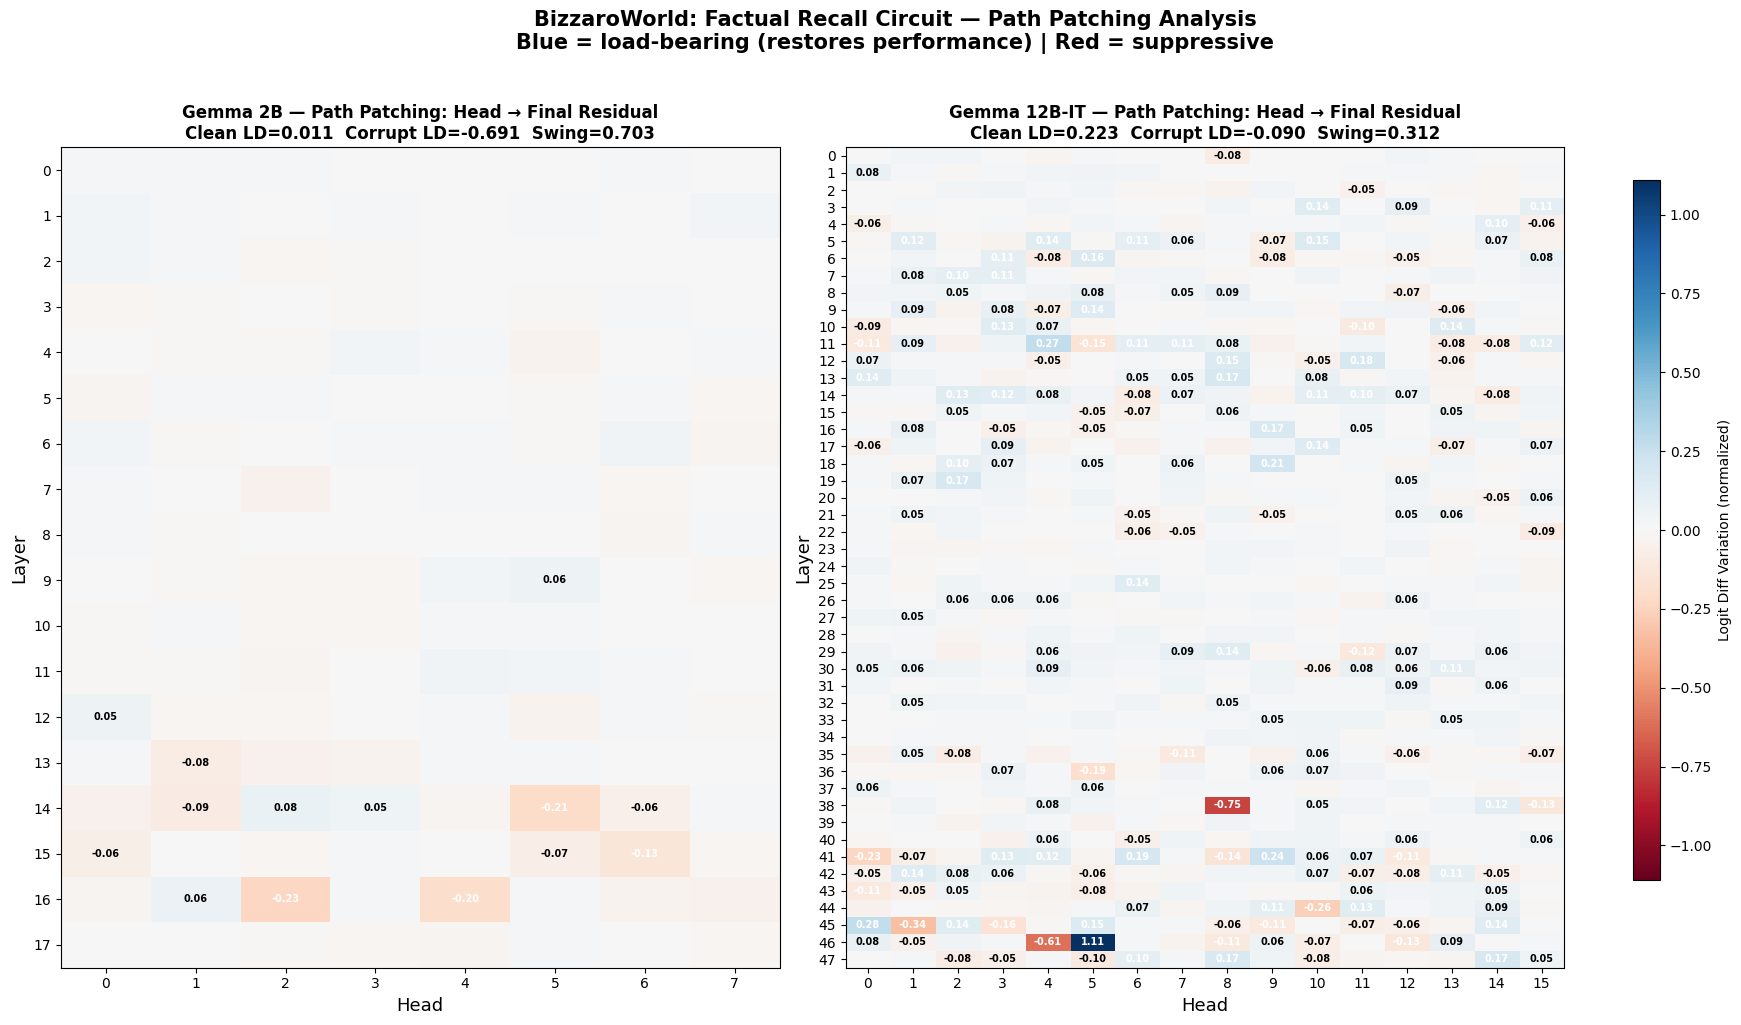

Saved side-by-side heatmap


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

vmax = max(abs(resid_2b).max(), abs(resid_12b).max())
vmin = -vmax

for ax, tensor, title, baseline in zip(
    axes,
    [resid_2b, resid_12b],
    ["Gemma 2B — Path Patching: Head → Final Residual",
     "Gemma 12B-IT — Path Patching: Head → Final Residual"],
    [baseline_2b, baseline_12b]
):
    im = ax.imshow(tensor, cmap="RdBu", vmin=vmin, vmax=vmax,
                   aspect="auto", interpolation="nearest")
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.set_xticks(range(tensor.shape[1]))
    ax.set_yticks(range(tensor.shape[0]))

    threshold = 0.05
    for i in range(tensor.shape[0]):
        for j in range(tensor.shape[1]):
            val = tensor[i, j]
            if abs(val) > threshold:
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                       fontsize=7, color="white" if abs(val) > 0.1 else "black",
                       fontweight="bold")

    subtitle = (f"Clean LD={baseline['clean_ld']:.3f}  "
                f"Corrupt LD={baseline['corrupt_ld']:.3f}  "
                f"Swing={baseline['total_swing']:.3f}")
    ax.set_title(f"{title}\n{subtitle}", fontsize=12, fontweight="bold")

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Logit Diff Variation (normalized)")
plt.suptitle("BizzaroWorld: Factual Recall Circuit — Path Patching Analysis\n"
             "Blue = load-bearing (restores performance) | Red = suppressive",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig(VISUALS_DIR / "path_patch_heatmap_side_by_side.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved side-by-side heatmap")

In [4]:
def get_top_heads(tensor, model_name, n=5):
    flat = tensor.flatten()
    top_neg_idx = np.argsort(flat)[:n]
    top_pos_idx = np.argsort(flat)[-n:][::-1]
    
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    
    print(f"\nTop LOAD-BEARING heads (blue, negative — write correct answer):")
    print(f"{'Layer':>6} {'Head':>6} {'Score':>10}")
    print("-" * 26)
    load_bearing = []
    for idx in top_neg_idx:
        layer, head = divmod(idx, tensor.shape[1])
        score = tensor[layer, head]
        print(f"{layer:>6} {head:>6} {score:>10.4f}")
        load_bearing.append((int(layer), int(head), float(score)))
    
    print(f"\nTop SUPPRESSIVE heads (red, positive — suppress wrong answer):")
    print(f"{'Layer':>6} {'Head':>6} {'Score':>10}")
    print("-" * 26)
    suppressive = []
    for idx in top_pos_idx:
        layer, head = divmod(idx, tensor.shape[1])
        score = tensor[layer, head]
        print(f"{layer:>6} {head:>6} {score:>10.4f}")
        suppressive.append((int(layer), int(head), float(score)))
    
    return load_bearing, suppressive

load_bearing_2b, suppressive_2b = get_top_heads(resid_2b, "Gemma 2B", n=5)
load_bearing_12b, suppressive_12b = get_top_heads(resid_12b, "Gemma 12B-IT", n=5)


Gemma 2B

Top LOAD-BEARING heads (blue, negative — write correct answer):
 Layer   Head      Score
--------------------------
    16      2    -0.2305
    14      5    -0.2051
    16      4    -0.1973
    15      6    -0.1318
    14      1    -0.0903

Top SUPPRESSIVE heads (red, positive — suppress wrong answer):
 Layer   Head      Score
--------------------------
    14      2     0.0752
    16      1     0.0640
     9      5     0.0583
    12      0     0.0527
    14      3     0.0518

Gemma 12B-IT

Top LOAD-BEARING heads (blue, negative — write correct answer):
 Layer   Head      Score
--------------------------
    38      8    -0.7461
    46      4    -0.6133
    45      1    -0.3379
    44     10    -0.2617
    41      0    -0.2314

Top SUPPRESSIVE heads (red, positive — suppress wrong answer):
 Layer   Head      Score
--------------------------
    46      5     1.1094
    45      0     0.2754
    11      4     0.2695
    41      9     0.2373
    18      9     0.2061


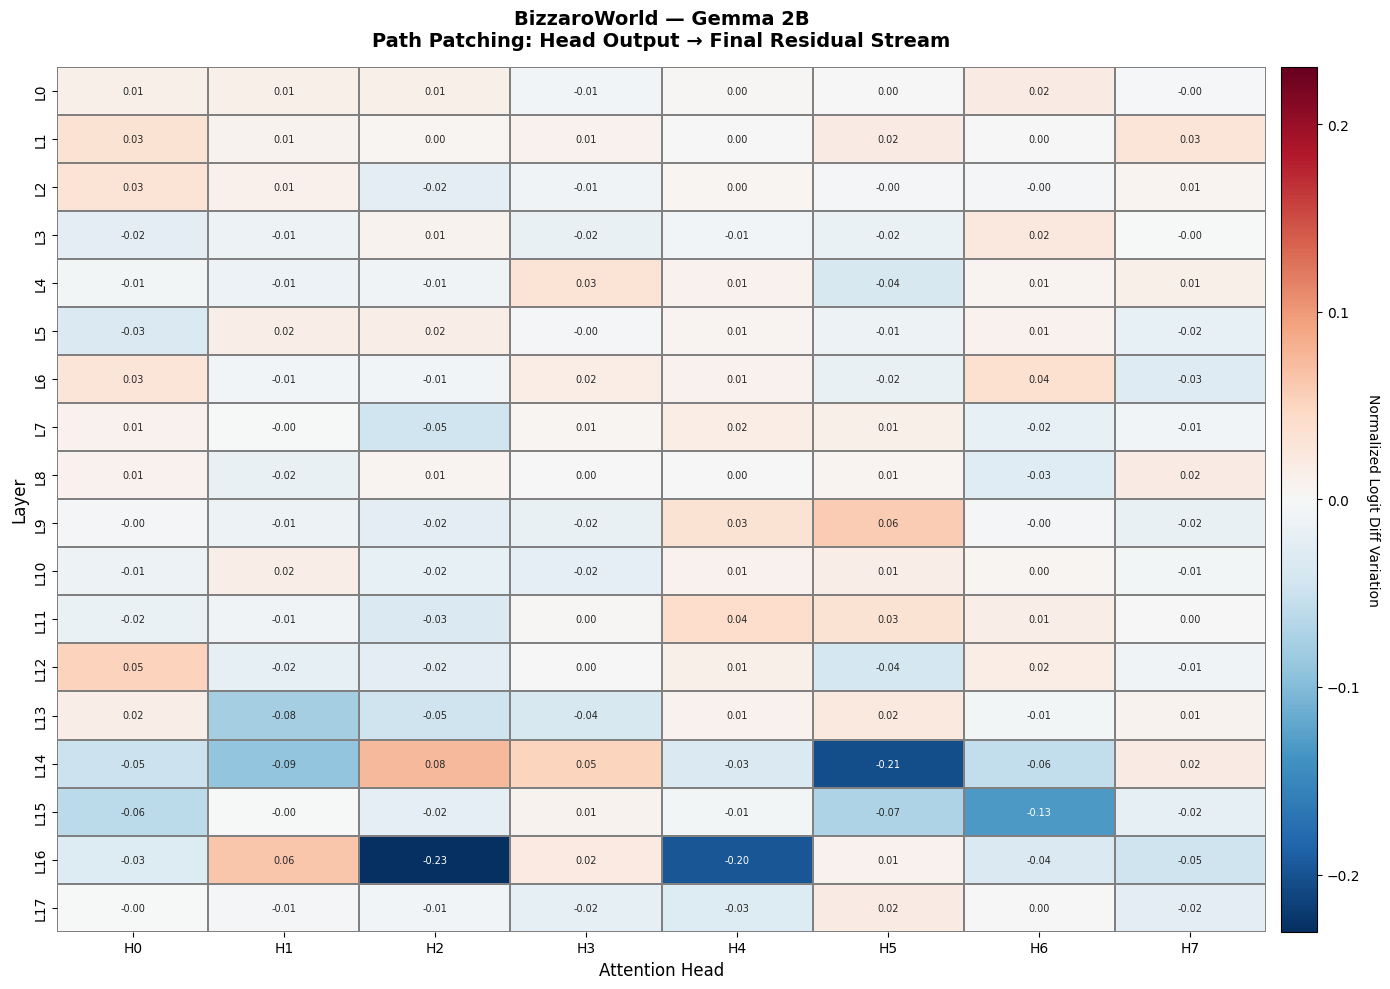

Saved heatmap_2b.png


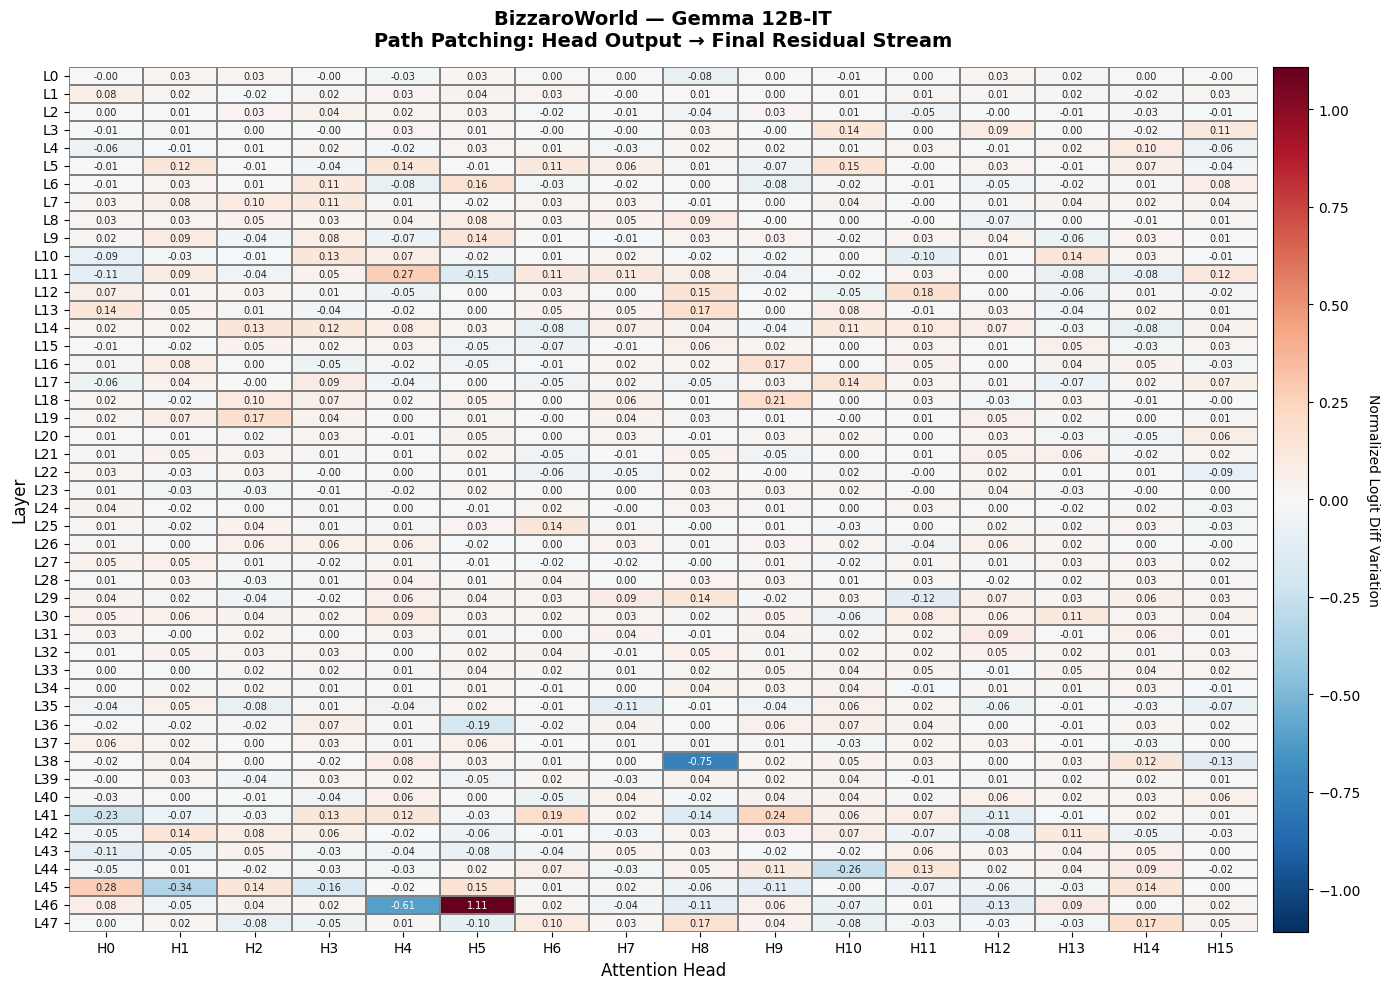

Saved heatmap_12b.png


In [5]:
for tensor, model_name, filename in [
    (resid_2b, "Gemma 2B", "heatmap_2b.png"),
    (resid_12b, "Gemma 12B-IT", "heatmap_12b.png"),
]:
    fig, ax = plt.subplots(figsize=(14, 10))
    vmax = abs(tensor).max()

    sns.heatmap(
        tensor, ax=ax,
        cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
        annot=tensor.shape[1] <= 16,
        fmt=".2f", annot_kws={"size": 7},
        xticklabels=[f"H{i}" for i in range(tensor.shape[1])],
        yticklabels=[f"L{i}" for i in range(tensor.shape[0])],
        linewidths=0.3, linecolor="gray",
        cbar=False
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.15)
    plt.colorbar(
        plt.cm.ScalarMappable(
            norm=plt.Normalize(vmin=-vmax, vmax=vmax),
            cmap="RdBu_r"
        ),
        cax=cax,
        label="Normalized Logit Diff Variation"
    )
    cax.yaxis.label.set_rotation(270)
    cax.yaxis.label.set_va("bottom")

    ax.set_title(f"BizzaroWorld — {model_name}\nPath Patching: Head Output → Final Residual Stream",
                fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Attention Head", fontsize=12)
    ax.set_ylabel("Layer", fontsize=12)

    plt.tight_layout()
    plt.savefig(VISUALS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")

In [6]:
# Combine load-bearing and suppressive for receiver head patching
# Both are mechanistically important — blue writes correct, red suppresses wrong

receiver_2b_combined = (
    [(l, h) for l, h, s in load_bearing_2b] +
    [(l, h) for l, h, s in suppressive_2b]
)

receiver_12b_combined = (
    [(l, h) for l, h, s in load_bearing_12b] +
    [(l, h) for l, h, s in suppressive_12b]
)

# Deduplicate while preserving order
def deduplicate(lst):
    seen = set()
    result = []
    for item in lst:
        if item not in seen:
            seen.add(item)
            result.append(item)
    return result

receiver_2b_combined = deduplicate(receiver_2b_combined)
receiver_12b_combined = deduplicate(receiver_12b_combined)

print("="*60)
print("NEXT RUN COMMANDS (load-bearing + suppressive heads):")
print()
print("Gemma 2B:")
print(f"  Load-bearing: {[(l,h) for l,h,s in load_bearing_2b]}")
print(f"  Suppressive:  {[(l,h) for l,h,s in suppressive_2b]}")
receiver_str_2b = " ".join([f"{l}:{h}" for l, h in receiver_2b_combined])
print(f"\n  CLI (q): python run_experiments.py --model gemma_2b --receiver-heads {receiver_str_2b} --receiver-input q")
print(f"  CLI (k): python run_experiments.py --model gemma_2b --receiver-heads {receiver_str_2b} --receiver-input k")
print(f"  CLI (v): python run_experiments.py --model gemma_2b --receiver-heads {receiver_str_2b} --receiver-input v")

print()
print("Gemma 12B:")
print(f"  Load-bearing: {[(l,h) for l,h,s in load_bearing_12b]}")
print(f"  Suppressive:  {[(l,h) for l,h,s in suppressive_12b]}")
receiver_str_12b = " ".join([f"{l}:{h}" for l, h in receiver_12b_combined])
print(f"\n  CLI (q): python run_experiments.py --model gemma_12b --receiver-heads {receiver_str_12b} --receiver-input q")
print(f"  CLI (k): python run_experiments.py --model gemma_12b --receiver-heads {receiver_str_12b} --receiver-input k")
print(f"  CLI (v): python run_experiments.py --model gemma_12b --receiver-heads {receiver_str_12b} --receiver-input v")

# Save updated receiver heads JSON
with open(VISUALS_DIR / "receiver_heads.json", "w") as f:
    json.dump({
        "gemma_2b": {
            "load_bearing": [(l, h) for l, h, s in load_bearing_2b],
            "suppressive": [(l, h) for l, h, s in suppressive_2b],
            "combined": receiver_2b_combined,
            "scores": {
                "load_bearing": {f"{l},{h}": s for l, h, s in load_bearing_2b},
                "suppressive": {f"{l},{h}": s for l, h, s in suppressive_2b},
            }
        },
        "gemma_12b": {
            "load_bearing": [(l, h) for l, h, s in load_bearing_12b],
            "suppressive": [(l, h) for l, h, s in suppressive_12b],
            "combined": receiver_12b_combined,
            "scores": {
                "load_bearing": {f"{l},{h}": s for l, h, s in load_bearing_12b},
                "suppressive": {f"{l},{h}": s for l, h, s in suppressive_12b},
            }
        }
    }, f, indent=2)

print(f"\nSaved updated receiver_heads.json to {VISUALS_DIR}")

NEXT RUN COMMANDS (load-bearing + suppressive heads):

Gemma 2B:
  Load-bearing: [(16, 2), (14, 5), (16, 4), (15, 6), (14, 1)]
  Suppressive:  [(14, 2), (16, 1), (9, 5), (12, 0), (14, 3)]

  CLI (q): python run_experiments.py --model gemma_2b --receiver-heads 16:2 14:5 16:4 15:6 14:1 14:2 16:1 9:5 12:0 14:3 --receiver-input q
  CLI (k): python run_experiments.py --model gemma_2b --receiver-heads 16:2 14:5 16:4 15:6 14:1 14:2 16:1 9:5 12:0 14:3 --receiver-input k
  CLI (v): python run_experiments.py --model gemma_2b --receiver-heads 16:2 14:5 16:4 15:6 14:1 14:2 16:1 9:5 12:0 14:3 --receiver-input v

Gemma 12B:
  Load-bearing: [(38, 8), (46, 4), (45, 1), (44, 10), (41, 0)]
  Suppressive:  [(46, 5), (45, 0), (11, 4), (41, 9), (18, 9)]

  CLI (q): python run_experiments.py --model gemma_12b --receiver-heads 38:8 46:4 45:1 44:10 41:0 46:5 45:0 11:4 41:9 18:9 --receiver-input q
  CLI (k): python run_experiments.py --model gemma_12b --receiver-heads 38:8 46:4 45:1 44:10 41:0 46:5 45:0 11:4 4

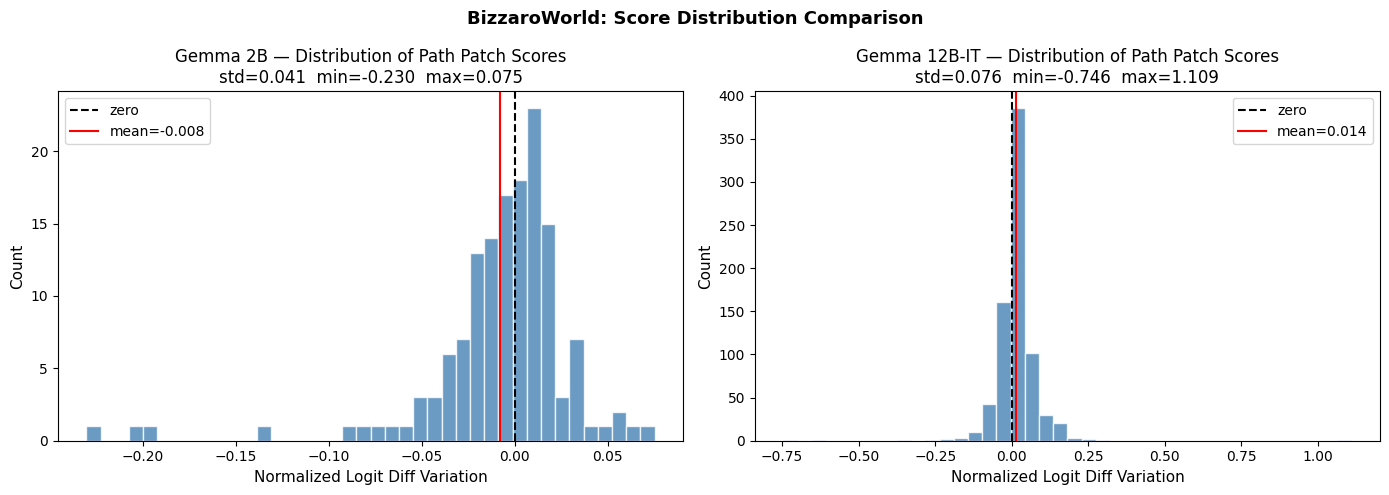

Saved score distributions


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tensor, model_name in [
    (axes[0], resid_2b, "Gemma 2B"),
    (axes[1], resid_12b, "Gemma 12B-IT"),
]:
    flat = tensor.flatten()
    ax.hist(flat, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="zero")
    ax.axvline(flat.mean(), color="red", linestyle="-", linewidth=1.5, 
               label=f"mean={flat.mean():.3f}")
    ax.set_xlabel("Normalized Logit Diff Variation", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"{model_name} — Distribution of Path Patch Scores\n"
                 f"std={flat.std():.3f}  min={flat.min():.3f}  max={flat.max():.3f}",
                 fontsize=12)
    ax.legend(fontsize=10)

plt.suptitle("BizzaroWorld: Score Distribution Comparison", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved score distributions")

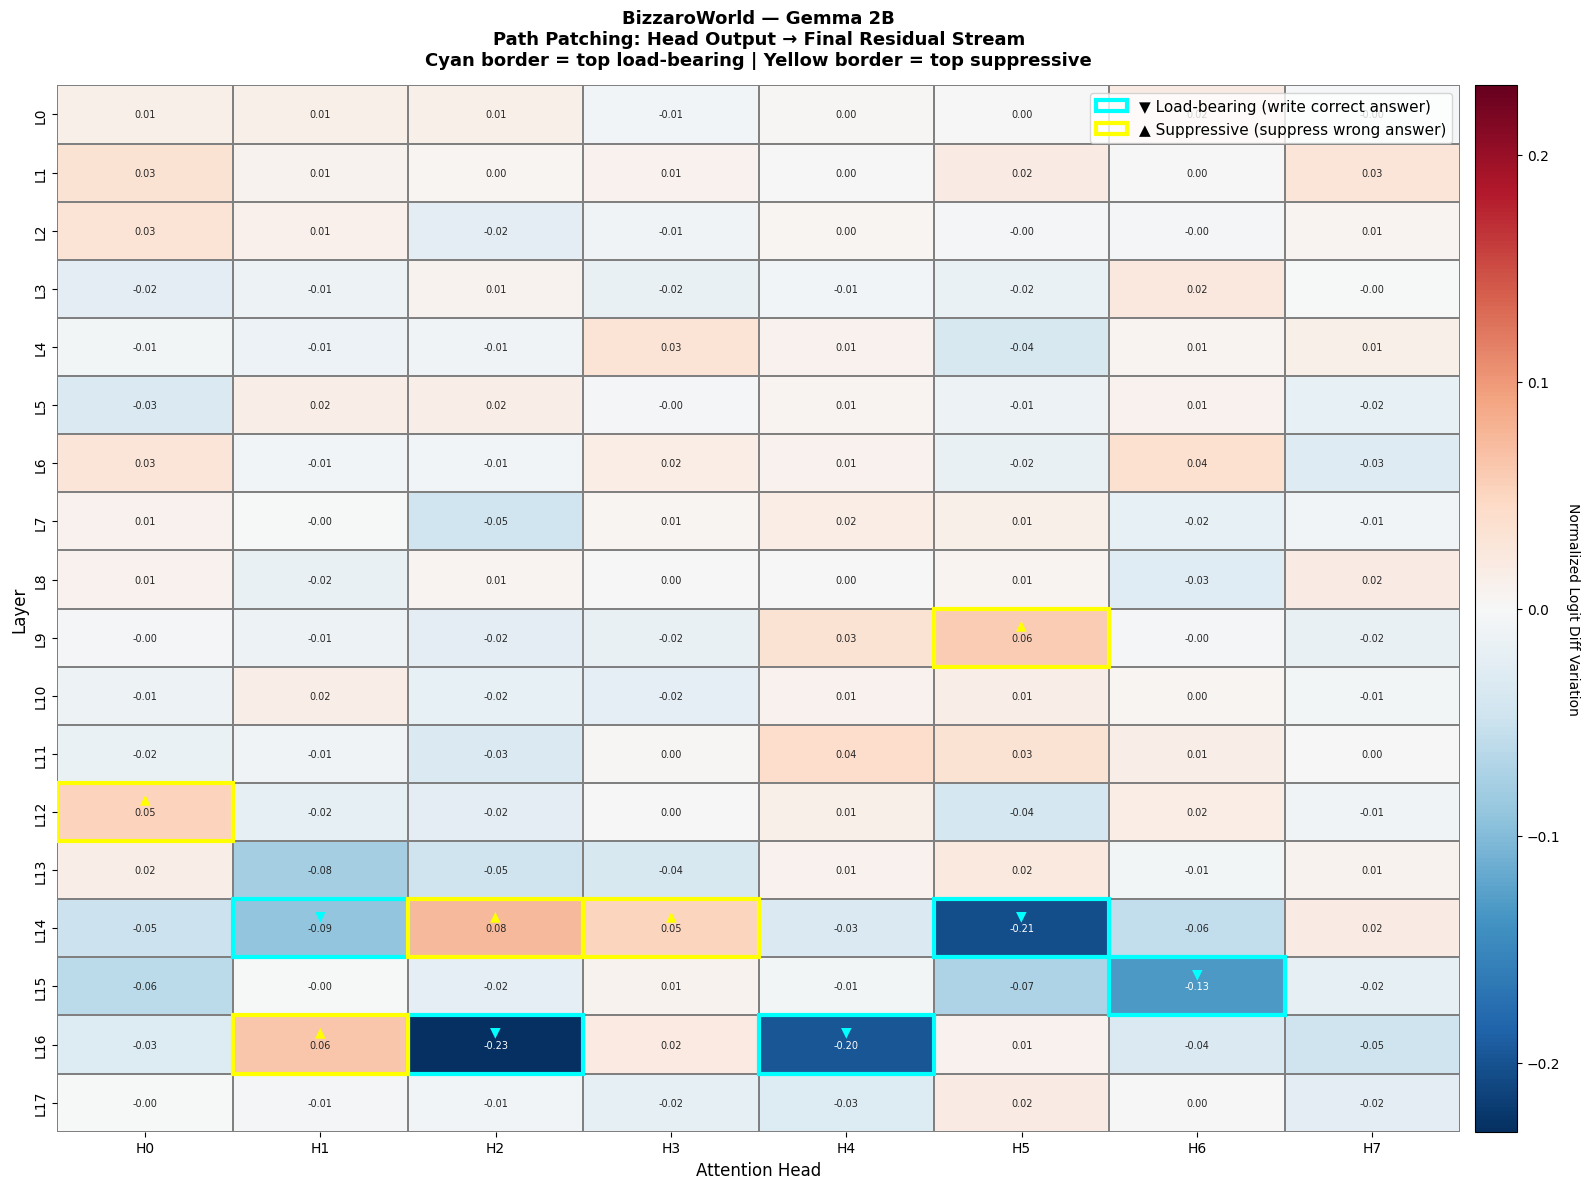

Saved heatmap_2b_annotated.png


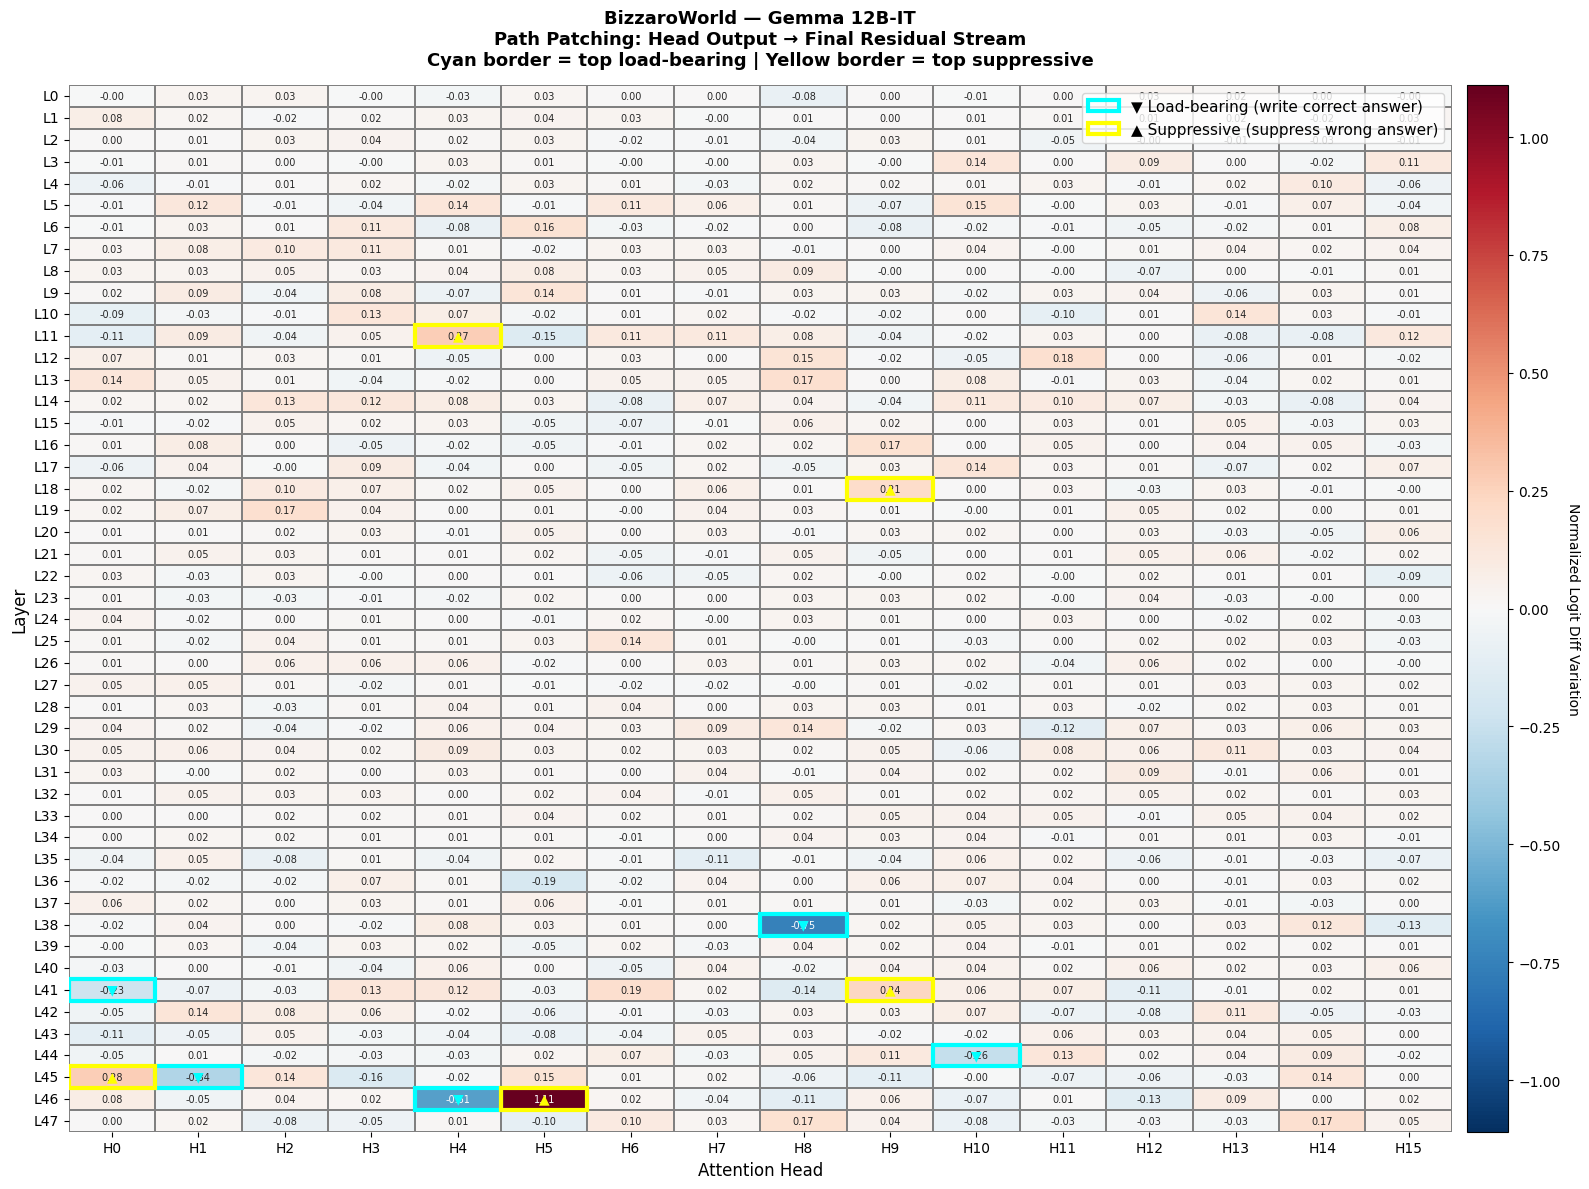

Saved heatmap_12b_annotated.png


In [8]:
for tensor, model_name, filename, lb, sup in [
    (resid_2b, "Gemma 2B", "heatmap_2b_annotated.png",
     load_bearing_2b, suppressive_2b),
    (resid_12b, "Gemma 12B-IT", "heatmap_12b_annotated.png",
     load_bearing_12b, suppressive_12b),
]:
    fig, ax = plt.subplots(figsize=(16, 12))
    vmax = abs(tensor).max()

    sns.heatmap(
        tensor, ax=ax, cmap="RdBu_r", center=0,
        vmin=-vmax, vmax=vmax,
        annot=tensor.shape[1] <= 16,
        fmt=".2f", annot_kws={"size": 7},
        xticklabels=[f"H{i}" for i in range(tensor.shape[1])],
        yticklabels=[f"L{i}" for i in range(tensor.shape[0])],
        linewidths=0.3, linecolor="gray",
        cbar=False
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.15)
    plt.colorbar(
        plt.cm.ScalarMappable(
            norm=plt.Normalize(vmin=-vmax, vmax=vmax),
            cmap="RdBu_r"
        ),
        cax=cax,
        label="Normalized Logit Diff Variation"
    )
    cax.yaxis.label.set_rotation(270)
    cax.yaxis.label.set_va("bottom")

    for l, h, s in lb:
        ax.add_patch(plt.Rectangle((h, l), 1, 1,
                     fill=False, edgecolor="cyan", lw=3))
        ax.text(h + 0.5, l + 0.15, "▼", ha="center", va="top",
               fontsize=10, color="cyan", fontweight="bold")

    for l, h, s in sup:
        ax.add_patch(plt.Rectangle((h, l), 1, 1,
                     fill=False, edgecolor="yellow", lw=3))
        ax.text(h + 0.5, l + 0.15, "▲", ha="center", va="top",
               fontsize=10, color="yellow", fontweight="bold")

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor="none", edgecolor="cyan", linewidth=3,
              label="▼ Load-bearing (write correct answer)"),
        Patch(facecolor="none", edgecolor="yellow", linewidth=3,
              label="▲ Suppressive (suppress wrong answer)"),
    ], loc="upper right", fontsize=11, framealpha=0.8)

    ax.set_title(
        f"BizzaroWorld — {model_name}\n"
        f"Path Patching: Head Output → Final Residual Stream\n"
        f"Cyan border = top load-bearing | Yellow border = top suppressive",
        fontsize=13, fontweight="bold", pad=15
    )
    ax.set_xlabel("Attention Head", fontsize=12)
    ax.set_ylabel("Layer", fontsize=12)

    plt.tight_layout()
    plt.savefig(VISUALS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")

In [9]:
# Load head-to-head patching results
with open("results/gemma_2b/path_patch_heads_q.json") as f:
    heads_q_2b_raw = json.load(f)
heads_q_2b = np.array(heads_q_2b_raw["values"])

with open("results/gemma_12b/path_patch_heads_q.json") as f:
    heads_q_12b_raw = json.load(f)
heads_q_12b = np.array(heads_q_12b_raw["values"])

# Load receiver head lists from baseline metrics
with open("results/gemma_2b/baseline_metrics.json") as f:
    bm_2b = json.load(f)
with open("results/gemma_12b/baseline_metrics.json") as f:
    bm_12b = json.load(f)

receiver_2b = bm_2b["receiver_heads_q"]
receiver_12b = bm_12b["receiver_heads_q"]

print(f"2B heads_q shape: {heads_q_2b.shape}")
print(f"12B heads_q shape: {heads_q_12b.shape}")
print(f"2B receivers: {receiver_2b}")
print(f"12B receivers: {receiver_12b}")

2B heads_q shape: (16, 8)
12B heads_q shape: (46, 16)
2B receivers: [[16, 2], [14, 5], [16, 4], [15, 6], [14, 1], [14, 2], [16, 1], [9, 5], [12, 0], [14, 3]]
12B receivers: [[38, 8], [46, 4], [45, 1], [44, 10], [41, 0], [46, 5], [45, 0], [11, 4], [41, 9], [18, 9]]


In [10]:
def get_top_senders(tensor, model_name, n=8):
    flat = tensor.flatten()
    top_neg_idx = np.argsort(flat)[:n]
    top_pos_idx = np.argsort(flat)[-n:][::-1]
    
    print(f"\n{'='*60}")
    print(f"{model_name} — Head-to-Head Path Patching (sender → receiver queries)")
    print(f"Tensor shape: {tensor.shape} [sender_layers, sender_heads]")
    print(f"{'='*60}")
    
    print(f"\nTop LOAD-BEARING senders (negative — supply correct signal to receivers):")
    print(f"{'Layer':>6} {'Head':>6} {'Score':>10}")
    print("-" * 26)
    load_bearing = []
    for idx in top_neg_idx:
        layer, head = divmod(idx, tensor.shape[1])
        score = tensor[layer, head]
        print(f"  L{layer:02d}H{head:02d}  {score:>10.4f}")
        load_bearing.append((int(layer), int(head), float(score)))
    
    print(f"\nTop SUPPRESSIVE senders (positive — supply suppression signal to receivers):")
    print(f"{'Layer':>6} {'Head':>6} {'Score':>10}")
    print("-" * 26)
    suppressive = []
    for idx in top_pos_idx:
        layer, head = divmod(idx, tensor.shape[1])
        score = tensor[layer, head]
        print(f"  L{layer:02d}H{head:02d}  {score:>10.4f}")
        suppressive.append((int(layer), int(head), float(score)))
    
    return load_bearing, suppressive

lb_senders_2b, sup_senders_2b = get_top_senders(heads_q_2b, "Gemma 2B", n=8)
lb_senders_12b, sup_senders_12b = get_top_senders(heads_q_12b, "Gemma 12B-IT", n=8)


Gemma 2B — Head-to-Head Path Patching (sender → receiver queries)
Tensor shape: (16, 8) [sender_layers, sender_heads]

Top LOAD-BEARING senders (negative — supply correct signal to receivers):
 Layer   Head      Score
--------------------------
  L10H05     -0.0884
  L12H05     -0.0825
  L13H05     -0.0508
  L11H02     -0.0496
  L06H03     -0.0376
  L10H00     -0.0320
  L04H00     -0.0264
  L04H02     -0.0242

Top SUPPRESSIVE senders (positive — supply suppression signal to receivers):
 Layer   Head      Score
--------------------------
  L04H01      0.0986
  L07H02      0.0933
  L01H05      0.0801
  L01H07      0.0737
  L00H05      0.0688
  L00H06      0.0679
  L07H03      0.0664
  L03H03      0.0645

Gemma 12B-IT — Head-to-Head Path Patching (sender → receiver queries)
Tensor shape: (46, 16) [sender_layers, sender_heads]

Top LOAD-BEARING senders (negative — supply correct signal to receivers):
 Layer   Head      Score
--------------------------
  L16H11     -0.0908
  L17H01     -0.

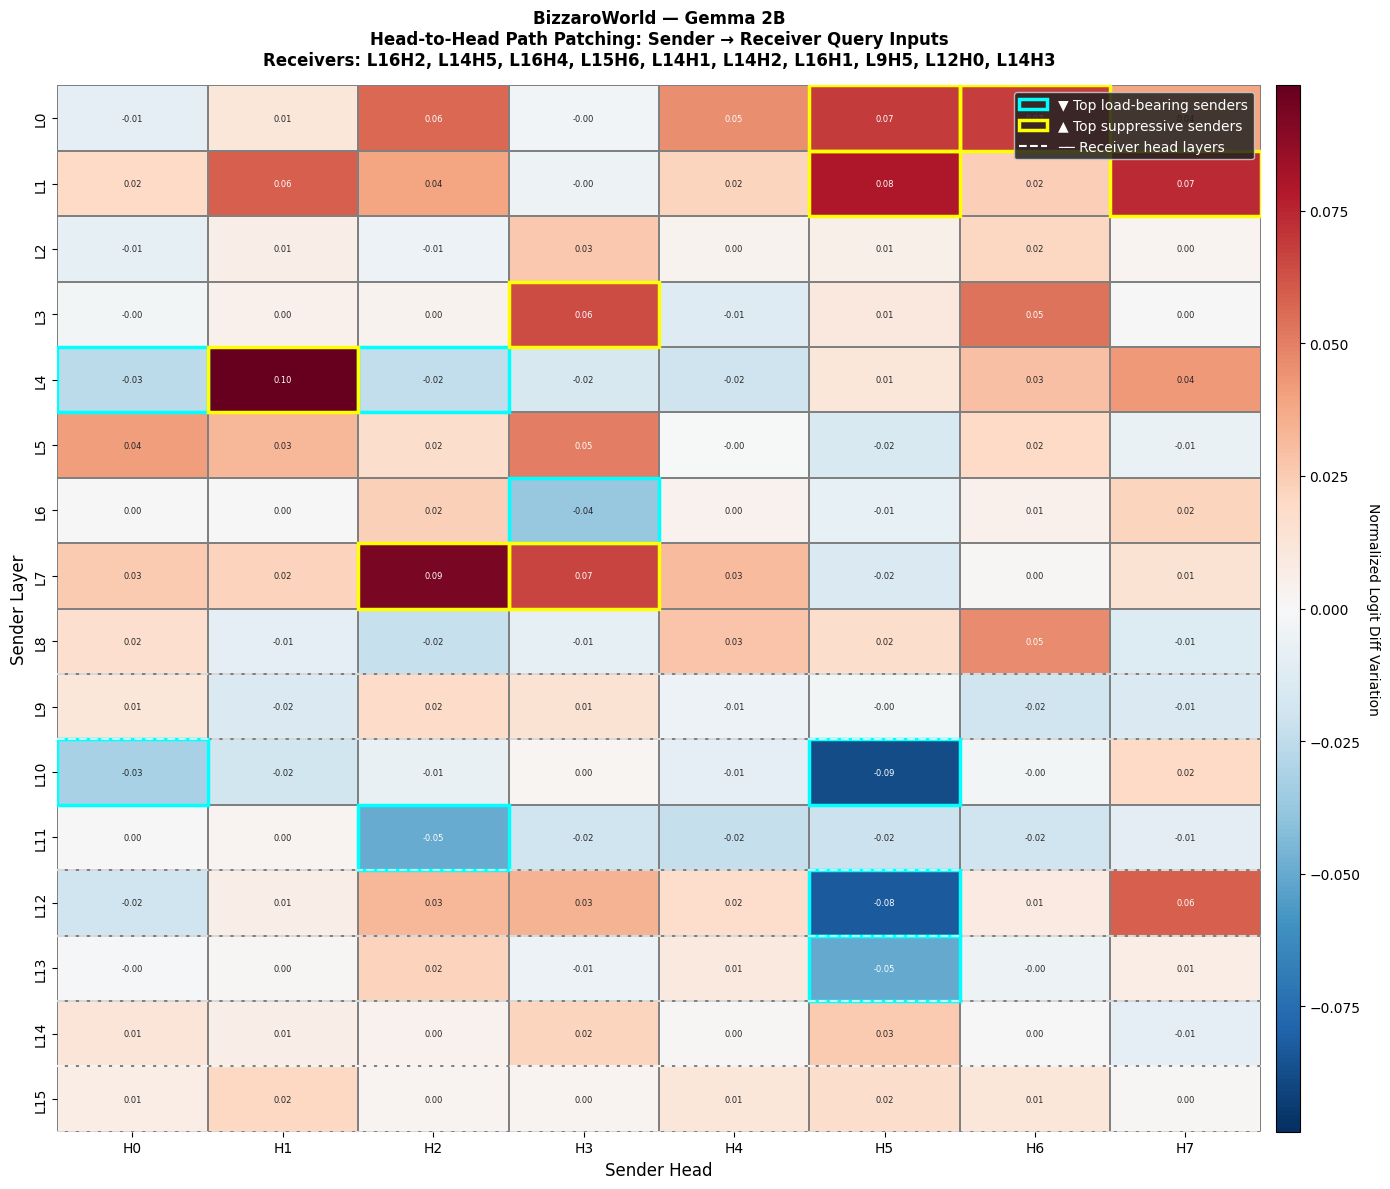

Saved heads_q_heatmap_2b.png


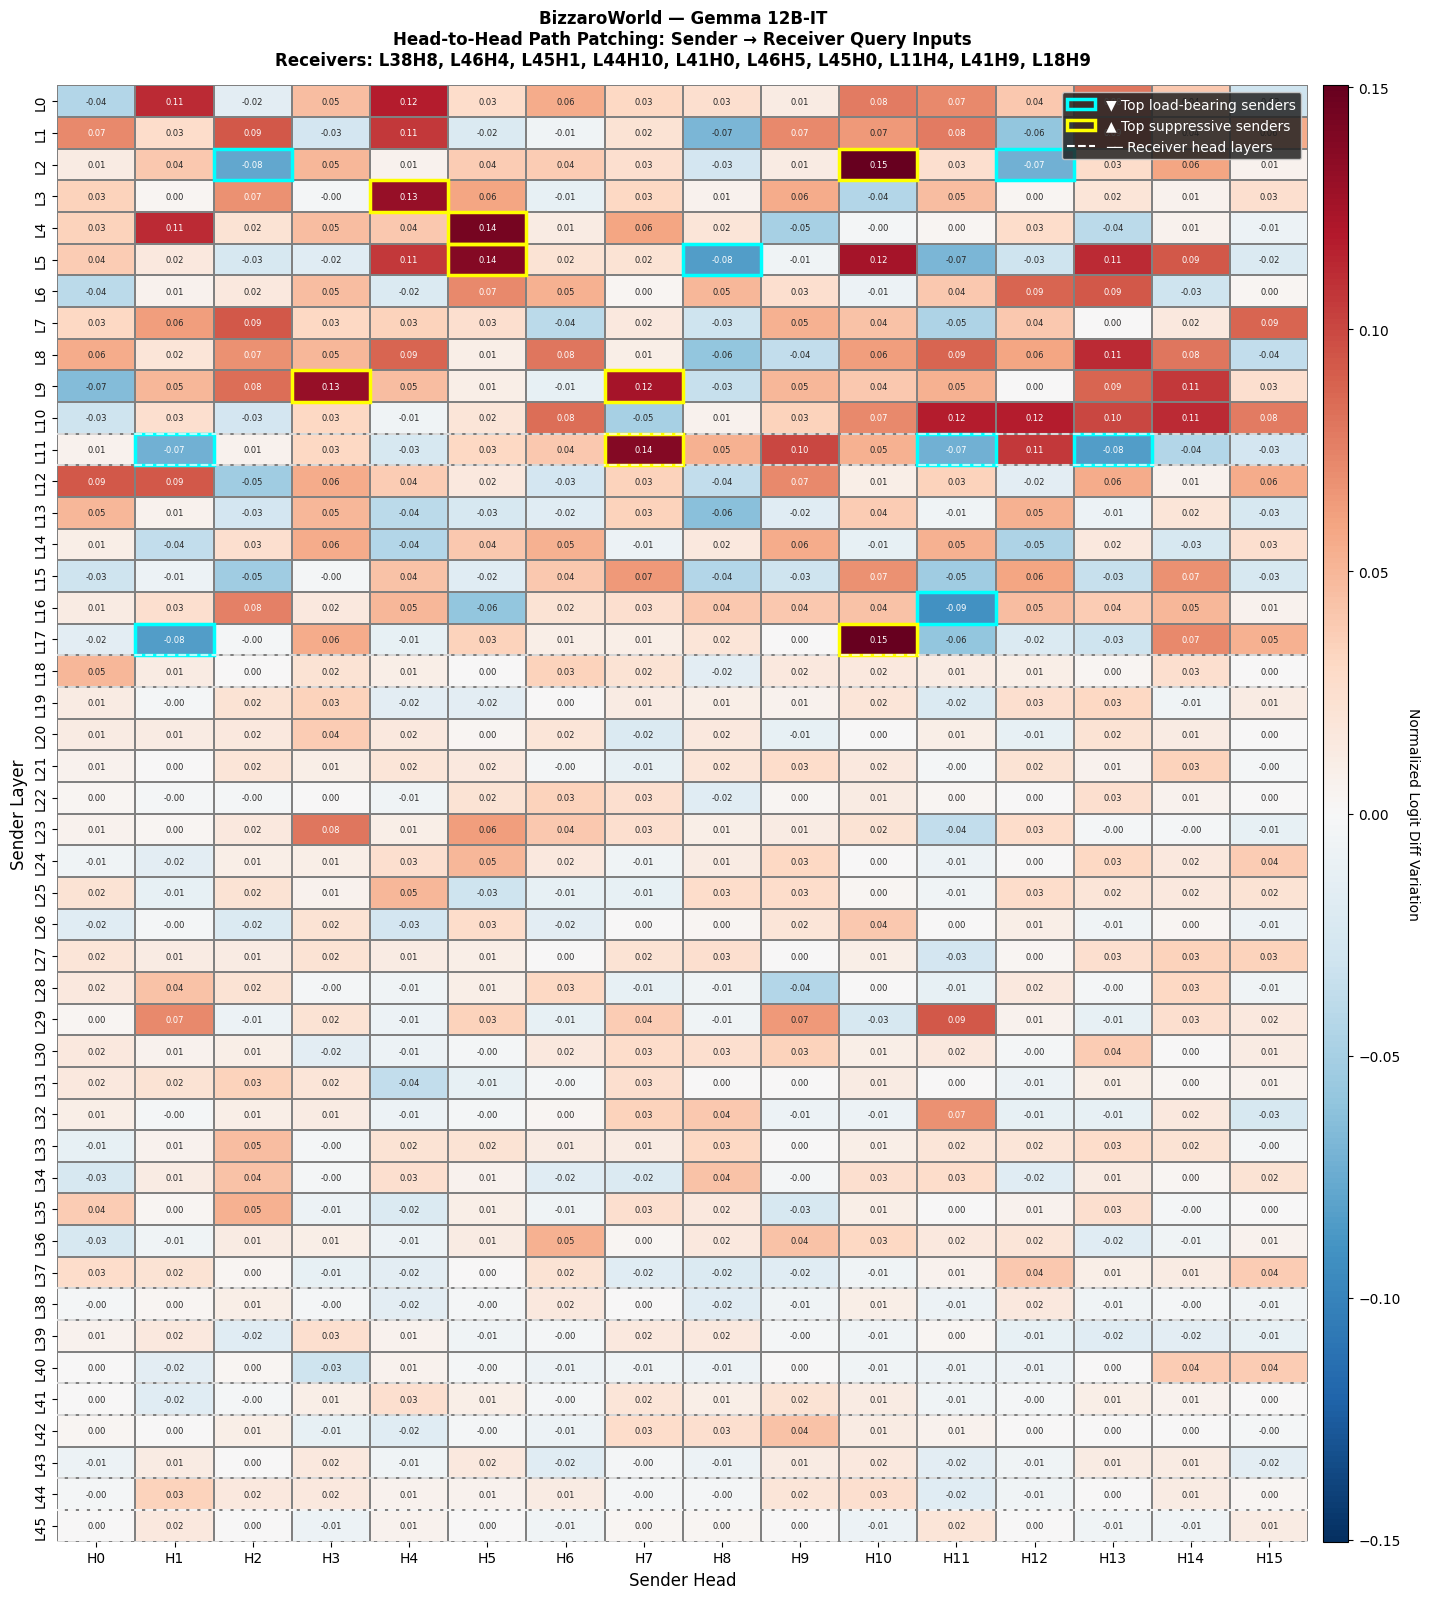

Saved heads_q_heatmap_12b.png


In [11]:
for tensor, model_name, filename, lb, sup, receivers in [
    (heads_q_2b, "Gemma 2B", "heads_q_heatmap_2b.png",
     lb_senders_2b, sup_senders_2b, receiver_2b),
    (heads_q_12b, "Gemma 12B-IT", "heads_q_heatmap_12b.png",
     lb_senders_12b, sup_senders_12b, receiver_12b),
]:
    n_layers, n_heads = tensor.shape
    fig, ax = plt.subplots(figsize=(max(14, n_heads * 0.9), max(12, n_layers * 0.35)))
    vmax = abs(tensor).max()

    sns.heatmap(
        tensor, ax=ax,
        cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
        annot=(n_heads <= 16 and n_layers <= 50),
        fmt=".2f", annot_kws={"size": 6},
        xticklabels=[f"H{i}" for i in range(n_heads)],
        yticklabels=[f"L{i}" for i in range(n_layers)],
        linewidths=0.2, linecolor="gray",
        cbar=False
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.15)
    plt.colorbar(
        plt.cm.ScalarMappable(
            norm=plt.Normalize(vmin=-vmax, vmax=vmax),
            cmap="RdBu_r"
        ),
        cax=cax,
        label="Normalized Logit Diff Variation"
    )
    cax.yaxis.label.set_rotation(270)
    cax.yaxis.label.set_va("bottom")

    for l, h, s in lb:
        ax.add_patch(plt.Rectangle((h, l), 1, 1, fill=False, edgecolor="cyan", lw=2.5))
    for l, h, s in sup:
        ax.add_patch(plt.Rectangle((h, l), 1, 1, fill=False, edgecolor="yellow", lw=2.5))

    receiver_layers = sorted(set(l for l, h in receivers))
    for rl in receiver_layers:
        if rl < n_layers:
            ax.axhline(y=rl, color="white", linestyle="--", linewidth=1.5, alpha=0.7)
            ax.axhline(y=rl + 1, color="white", linestyle="--", linewidth=1.5, alpha=0.7)

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Patch(facecolor="none", edgecolor="cyan", lw=2.5, label="▼ Top load-bearing senders"),
        Patch(facecolor="none", edgecolor="yellow", lw=2.5, label="▲ Top suppressive senders"),
        Line2D([0], [0], color="white", linestyle="--", lw=1.5, label="── Receiver head layers"),
    ], loc="upper right", fontsize=10, framealpha=0.85,
       facecolor="#222222", labelcolor="white")

    receiver_str = ", ".join([f"L{l}H{h}" for l, h in receivers])
    ax.set_title(
        f"BizzaroWorld — {model_name}\n"
        f"Head-to-Head Path Patching: Sender → Receiver Query Inputs\n"
        f"Receivers: {receiver_str}",
        fontsize=12, fontweight="bold", pad=15
    )
    ax.set_xlabel("Sender Head", fontsize=12)
    ax.set_ylabel("Sender Layer", fontsize=12)

    plt.tight_layout()
    plt.savefig(VISUALS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")

/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1040605405.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


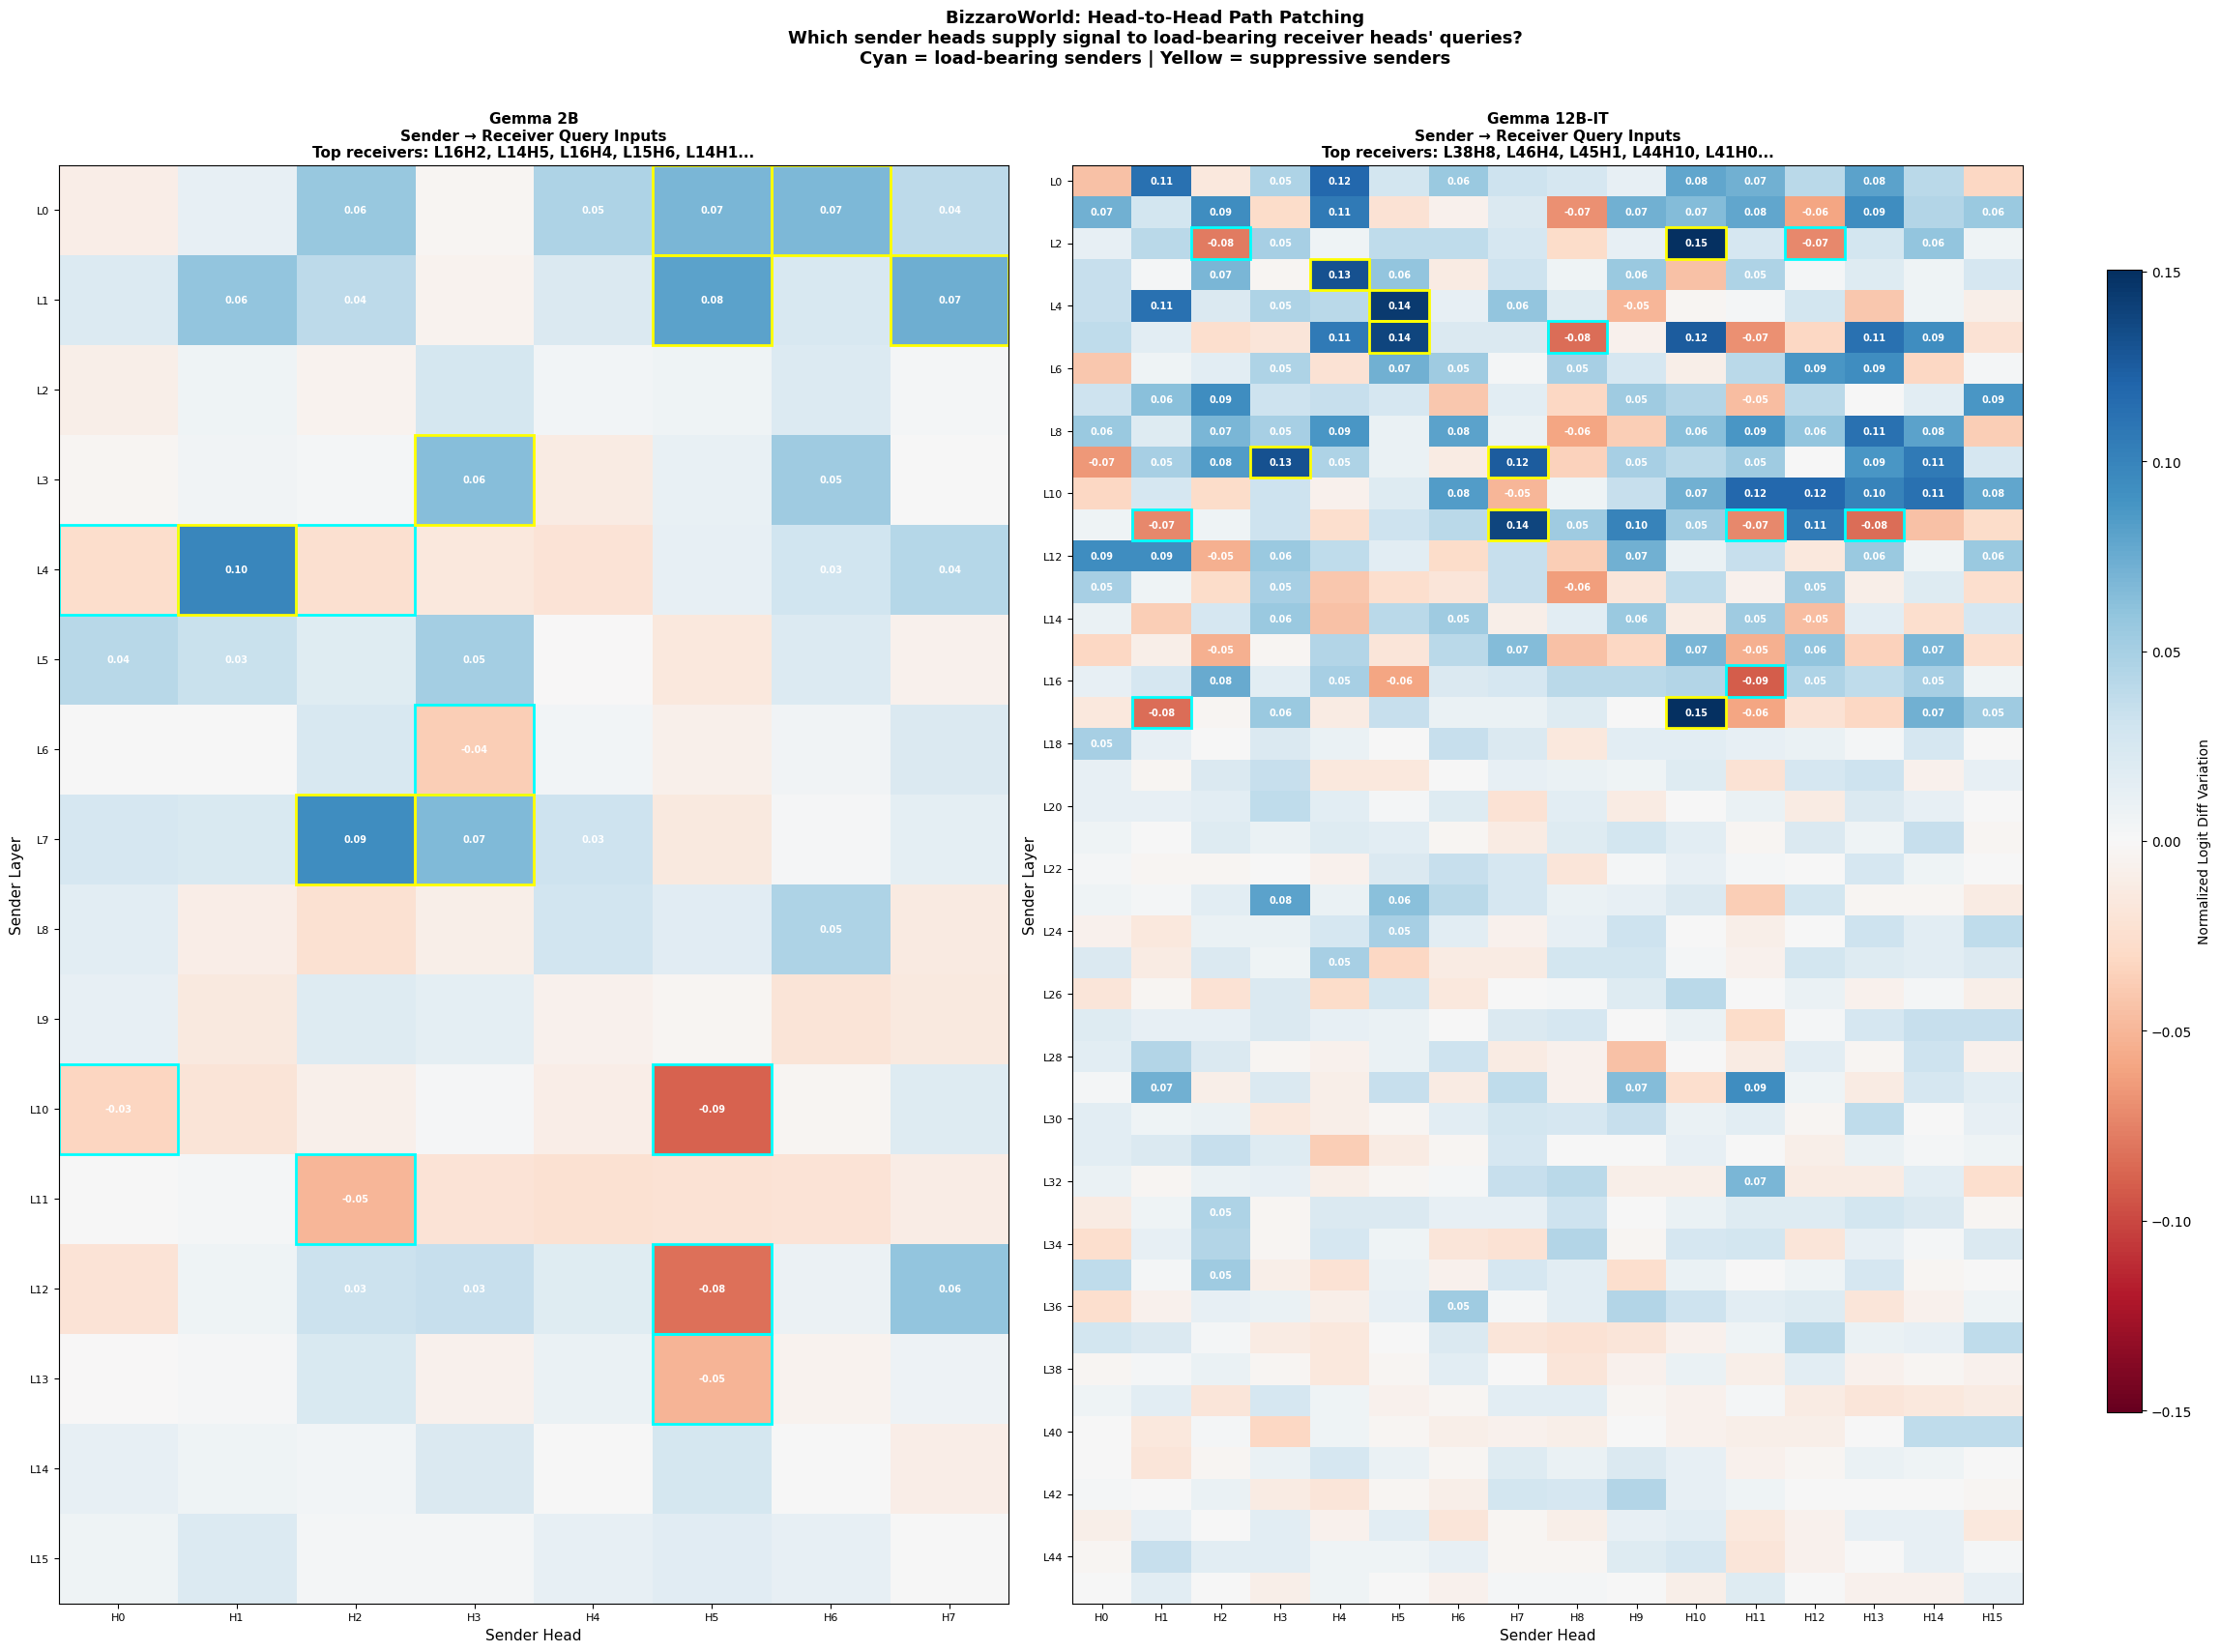

Saved heads_q_side_by_side.png


In [12]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(24, max(heads_q_2b.shape[0], heads_q_12b.shape[0]) * 0.28 + 4)
)

vmax = max(abs(heads_q_2b).max(), abs(heads_q_12b).max())

for ax, tensor, model_name, lb, sup, receivers in [
    (ax1, heads_q_2b, "Gemma 2B", lb_senders_2b, sup_senders_2b, receiver_2b),
    (ax2, heads_q_12b, "Gemma 12B-IT", lb_senders_12b, sup_senders_12b, receiver_12b),
]:
    im = ax.imshow(
        tensor, cmap="RdBu", vmin=-vmax, vmax=vmax,
        aspect="auto", interpolation="nearest"
    )

    threshold = abs(tensor).max() * 0.3
    for i in range(tensor.shape[0]):
        for j in range(tensor.shape[1]):
            val = tensor[i, j]
            if abs(val) >= threshold:
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                       fontsize=7, color="white", fontweight="bold")

    for l, h, s in lb:
        ax.add_patch(plt.Rectangle((h - 0.5, l - 0.5), 1, 1,
                     fill=False, edgecolor="cyan", lw=2))
    for l, h, s in sup:
        ax.add_patch(plt.Rectangle((h - 0.5, l - 0.5), 1, 1,
                     fill=False, edgecolor="yellow", lw=2))

    ax.set_xlabel("Sender Head", fontsize=11)
    ax.set_ylabel("Sender Layer", fontsize=11)
    ax.set_xticks(range(tensor.shape[1]))
    ax.set_xticklabels([f"H{i}" for i in range(tensor.shape[1])], fontsize=8)
    ax.set_yticks(range(0, tensor.shape[0], max(1, tensor.shape[0]//20)))
    ax.set_yticklabels(
        [f"L{i}" for i in range(0, tensor.shape[0], max(1, tensor.shape[0]//20))],
        fontsize=8
    )
    receiver_str = ", ".join([f"L{l}H{h}" for l, h in receivers[:5]]) + "..."
    ax.set_title(
        f"{model_name}\nSender → Receiver Query Inputs\n"
        f"Top receivers: {receiver_str}",
        fontsize=11, fontweight="bold"
    )

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Normalized Logit Diff Variation")
plt.suptitle(
    "BizzaroWorld: Head-to-Head Path Patching\n"
    "Which sender heads supply signal to load-bearing receiver heads' queries?\n"
    "Cyan = load-bearing senders | Yellow = suppressive senders",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig(VISUALS_DIR / "heads_q_side_by_side.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved heads_q_side_by_side.png")

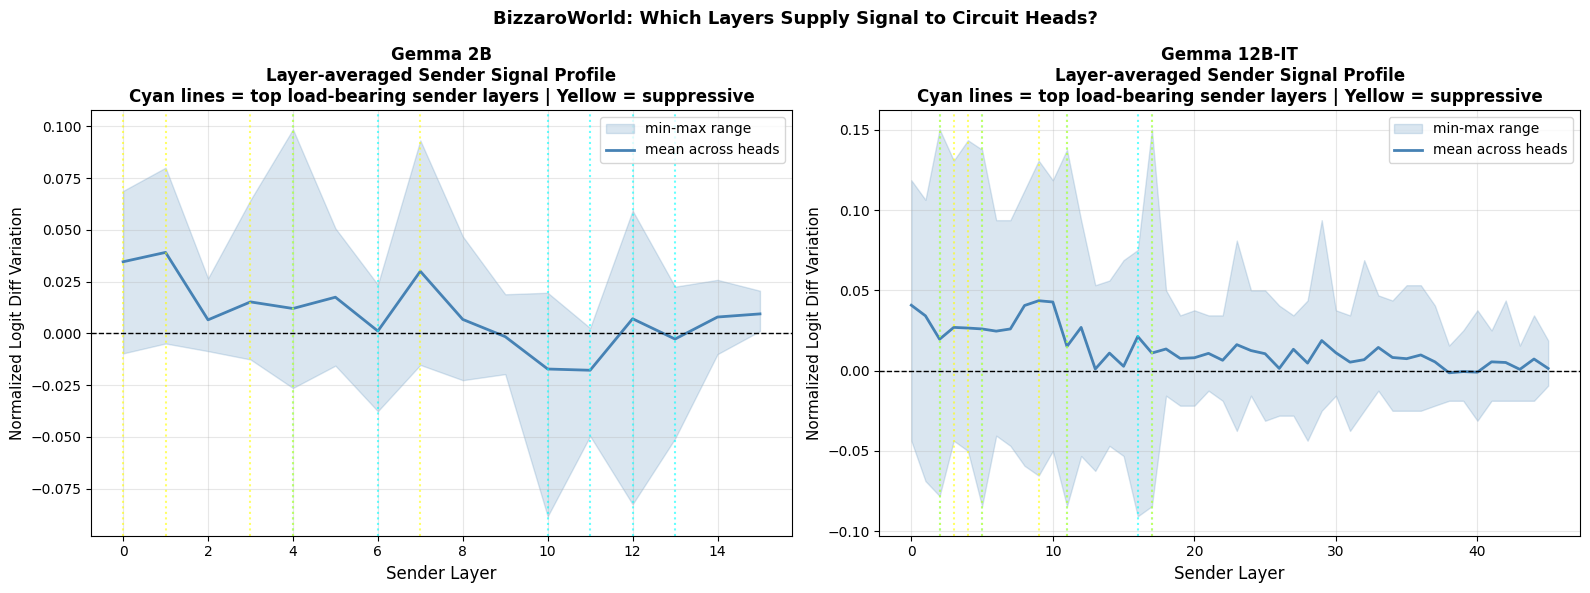

Saved heads_q_layer_profile.png


In [13]:
# Average signal across heads per layer — shows which layers are most active as senders
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tensor, model_name, lb, sup in [
    (axes[0], heads_q_2b, "Gemma 2B", lb_senders_2b, sup_senders_2b),
    (axes[1], heads_q_12b, "Gemma 12B-IT", lb_senders_12b, sup_senders_12b),
]:
    layer_mean = tensor.mean(axis=1)
    layer_min = tensor.min(axis=1)
    layer_max = tensor.max(axis=1)
    layers = np.arange(len(layer_mean))
    
    ax.fill_between(layers, layer_min, layer_max, alpha=0.2,
                    color="steelblue", label="min-max range")
    ax.plot(layers, layer_mean, color="steelblue", lw=2, label="mean across heads")
    ax.axhline(0, color="black", linestyle="--", lw=1)
    
    # Mark layers containing top senders
    lb_layers = set(l for l, h, s in lb)
    sup_layers = set(l for l, h, s in sup)
    for ll in lb_layers:
        ax.axvline(ll, color="cyan", alpha=0.6, lw=1.5, linestyle=":")
    for sl in sup_layers:
        ax.axvline(sl, color="yellow", alpha=0.6, lw=1.5, linestyle=":")
    
    ax.set_xlabel("Sender Layer", fontsize=12)
    ax.set_ylabel("Normalized Logit Diff Variation", fontsize=11)
    ax.set_title(
        f"{model_name}\nLayer-averaged Sender Signal Profile\n"
        f"Cyan lines = top load-bearing sender layers | Yellow = suppressive",
        fontsize=12, fontweight="bold"
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("BizzaroWorld: Which Layers Supply Signal to Circuit Heads?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "heads_q_layer_profile.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved heads_q_layer_profile.png")

In [14]:
circuit_summary = {
    "gemma_2b": {
        "model": "google/gemma-2b",
        "n_layers": 18,
        "n_heads": 8,
        "baseline": {
            "clean_ld": bm_2b["clean_ld"],
            "corrupt_ld": bm_2b["corrupt_ld"],
            "total_swing": bm_2b["total_swing"]
        },
        "circuit_heads": {
            "load_bearing_final_resid": [(l, h) for l, h, s in load_bearing_2b],
            "suppressive_final_resid": [(l, h) for l, h, s in suppressive_2b],
            "load_bearing_senders": [(l, h) for l, h, s in lb_senders_2b],
            "suppressive_senders": [(l, h) for l, h, s in sup_senders_2b],
        }
    },
    "gemma_12b": {
        "model": "google/gemma-3-12b-it",
        "n_layers": 48,
        "n_heads": 16,
        "baseline": {
            "clean_ld": bm_12b["clean_ld"],
            "corrupt_ld": bm_12b["corrupt_ld"],
            "total_swing": bm_12b["total_swing"]
        },
        "circuit_heads": {
            "load_bearing_final_resid": [(l, h) for l, h, s in load_bearing_12b],
            "suppressive_final_resid": [(l, h) for l, h, s in suppressive_12b],
            "load_bearing_senders": [(l, h) for l, h, s in lb_senders_12b],
            "suppressive_senders": [(l, h) for l, h, s in sup_senders_12b],
        }
    }
}

with open(VISUALS_DIR / "circuit_summary.json", "w") as f:
    json.dump(circuit_summary, f, indent=2)

print("Saved circuit_summary.json")
print("\nFull circuit summary:")
for model, data in circuit_summary.items():
    print(f"\n{model}:")
    for k, v in data["circuit_heads"].items():
        print(f"  {k}: {v}")

Saved circuit_summary.json

Full circuit summary:

gemma_2b:
  load_bearing_final_resid: [(16, 2), (14, 5), (16, 4), (15, 6), (14, 1)]
  suppressive_final_resid: [(14, 2), (16, 1), (9, 5), (12, 0), (14, 3)]
  load_bearing_senders: [(10, 5), (12, 5), (13, 5), (11, 2), (6, 3), (10, 0), (4, 0), (4, 2)]
  suppressive_senders: [(4, 1), (7, 2), (1, 5), (1, 7), (0, 5), (0, 6), (7, 3), (3, 3)]

gemma_12b:
  load_bearing_final_resid: [(38, 8), (46, 4), (45, 1), (44, 10), (41, 0)]
  suppressive_final_resid: [(46, 5), (45, 0), (11, 4), (41, 9), (18, 9)]
  load_bearing_senders: [(16, 11), (17, 1), (11, 13), (5, 8), (2, 2), (11, 11), (11, 1), (2, 12)]
  suppressive_senders: [(17, 10), (2, 10), (4, 5), (5, 5), (11, 7), (3, 4), (9, 3), (9, 7)]


In [15]:
import glob as _glob

def load_sender_results(model_dir):
    """Load all path_patch_sender_*.json files from a model directory."""
    results = {}
    for json_path in sorted(_glob.glob(f"{model_dir}/path_patch_sender_*.json")):
        stem = Path(json_path).stem          # e.g. path_patch_sender_38_8
        parts = stem.split("_")              # ["path", "patch", "sender", "38", "8"]
        try:
            layer, head = int(parts[-2]), int(parts[-1])
        except (ValueError, IndexError):
            continue
        with open(json_path) as f:
            raw = json.load(f)
        if "values" in raw:
            results[(layer, head)] = np.array(raw["values"])
    return results

sender_2b = load_sender_results("results/gemma_2b")
sender_12b = load_sender_results("results/gemma_12b")

print(f"2B sender experiments loaded:  {sorted(sender_2b.keys())}")
print(f"12B sender experiments loaded: {sorted(sender_12b.keys())}")
if not sender_2b and not sender_12b:
    print("\nNo sender results found. See Cell K for the Colab commands to generate them.")

2B sender experiments loaded:  [(9, 5), (12, 0), (14, 1), (14, 2), (14, 3), (14, 5), (15, 6), (16, 1), (16, 2), (16, 4)]
12B sender experiments loaded: [(11, 4), (18, 9), (38, 8), (41, 0), (41, 9), (44, 10), (45, 0), (45, 1), (46, 4), (46, 5)]


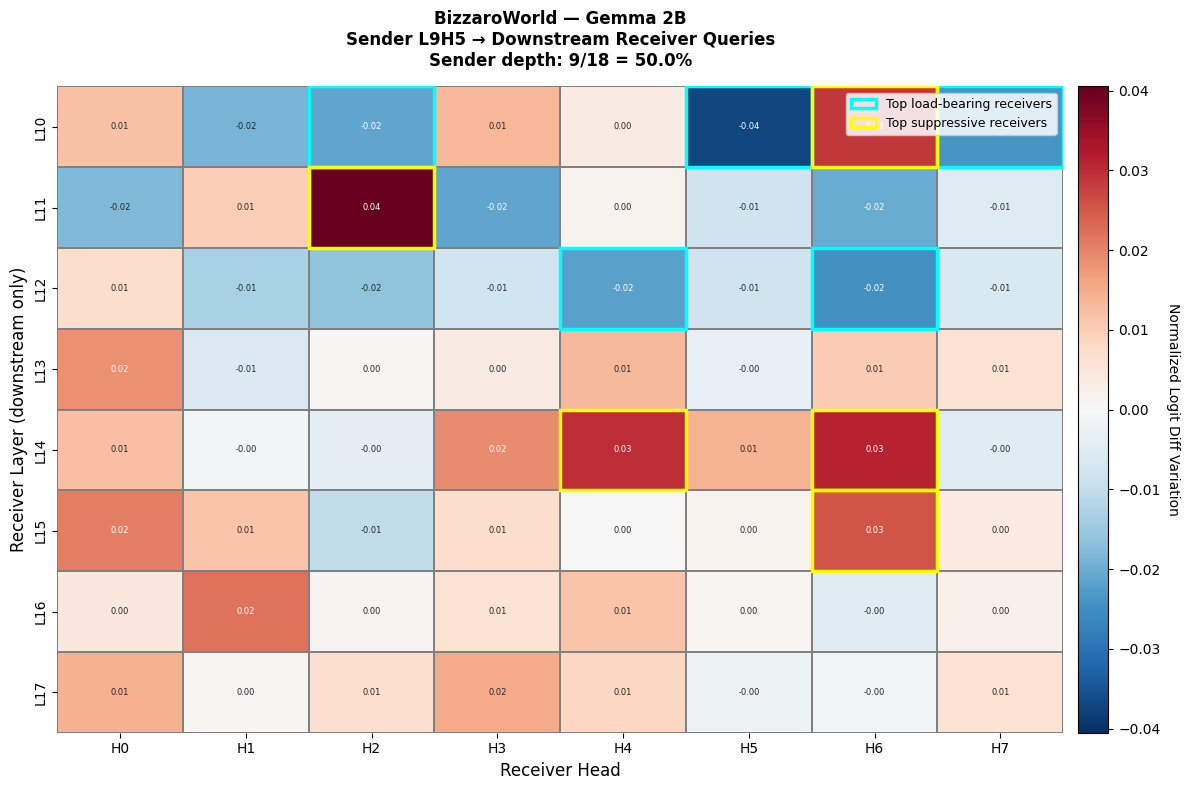

Saved sender_heatmap_gemma_2b_L9H5.png


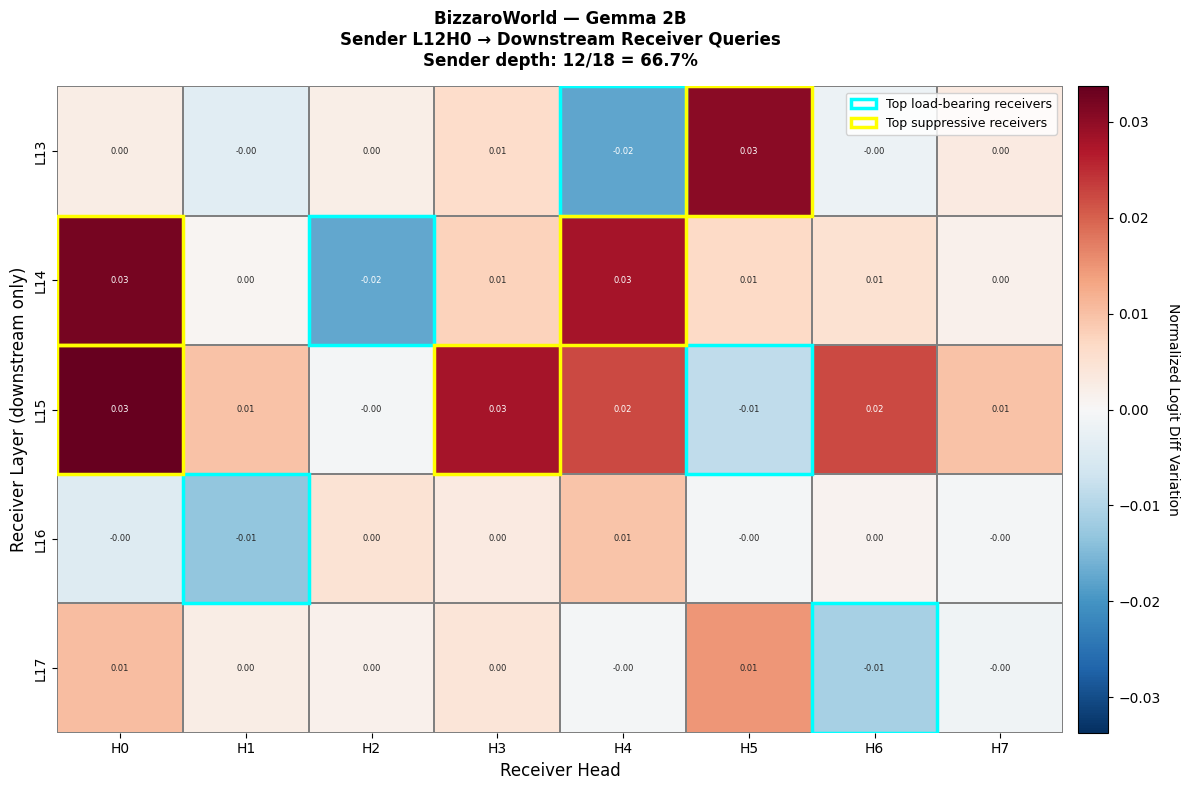

Saved sender_heatmap_gemma_2b_L12H0.png


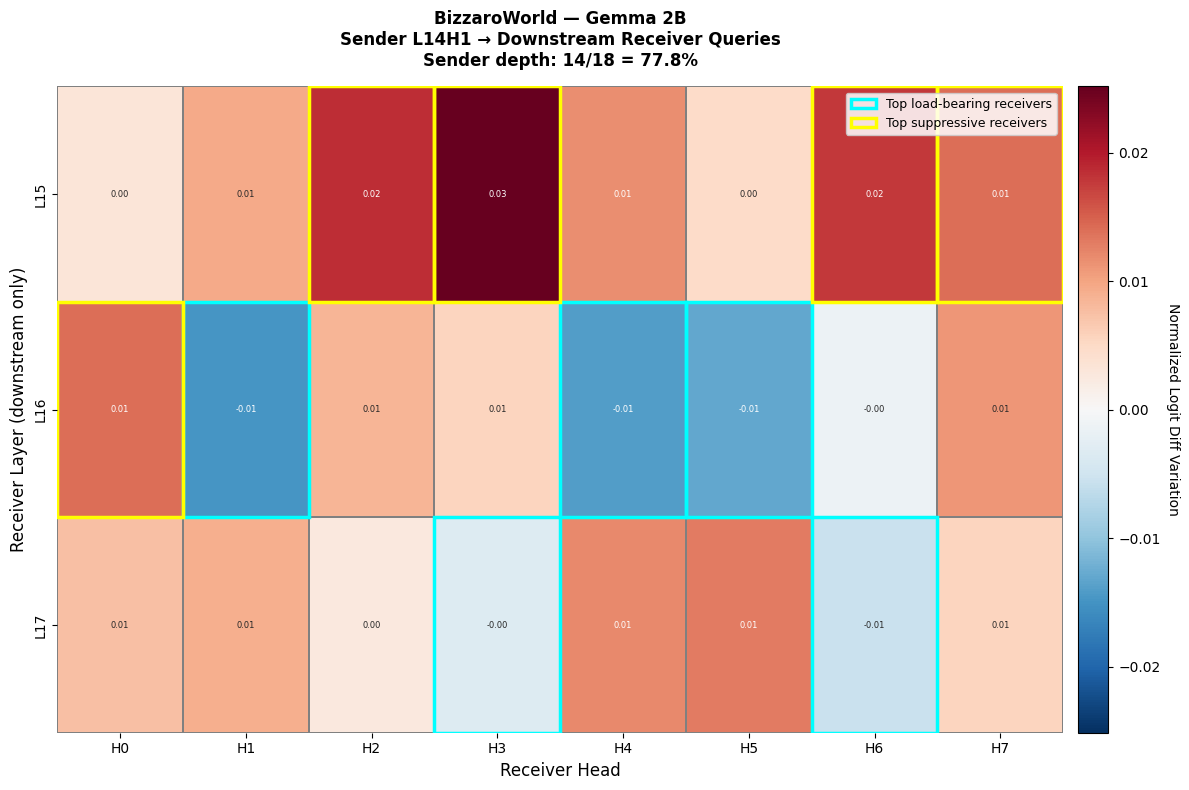

Saved sender_heatmap_gemma_2b_L14H1.png


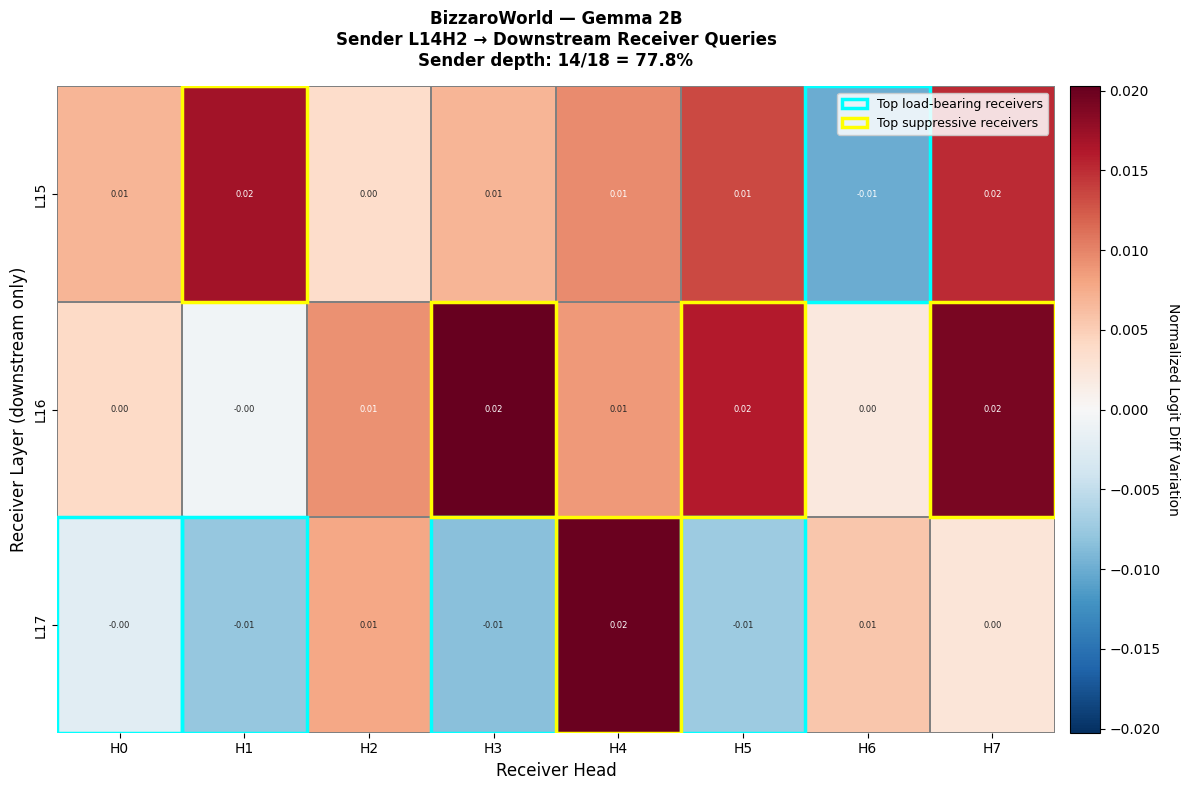

Saved sender_heatmap_gemma_2b_L14H2.png


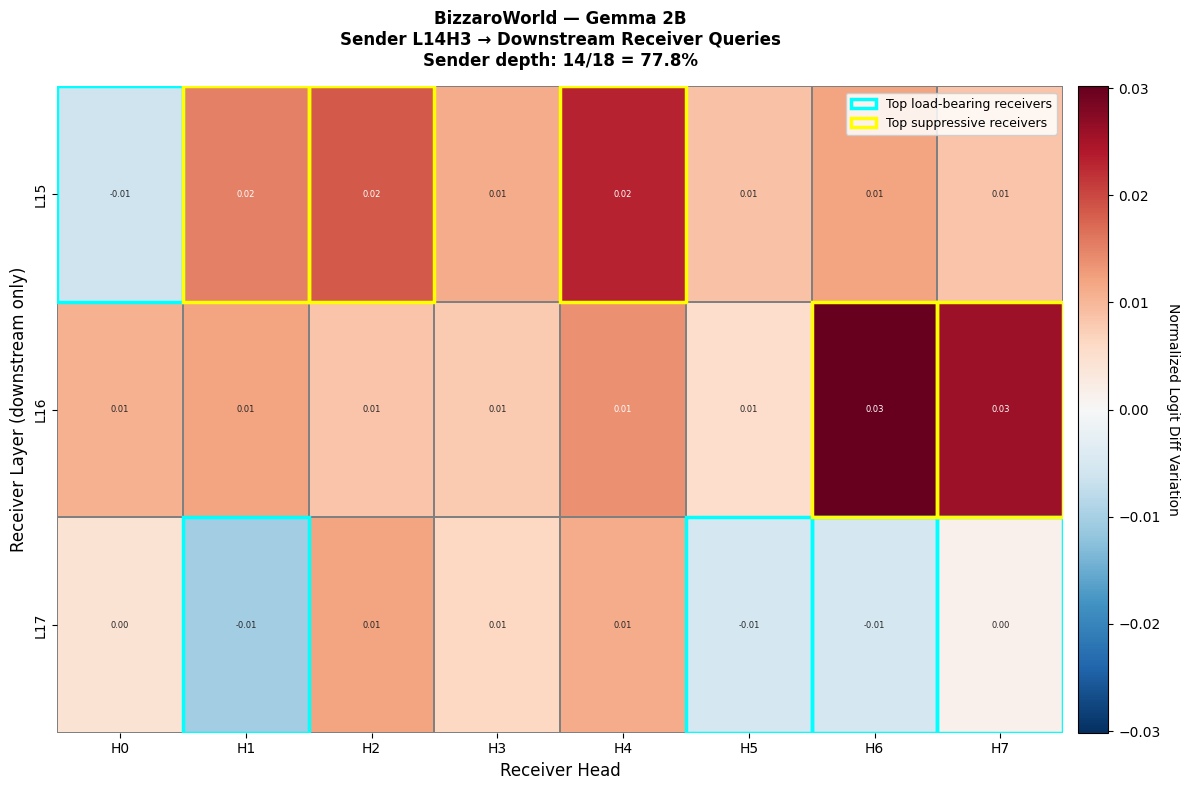

Saved sender_heatmap_gemma_2b_L14H3.png


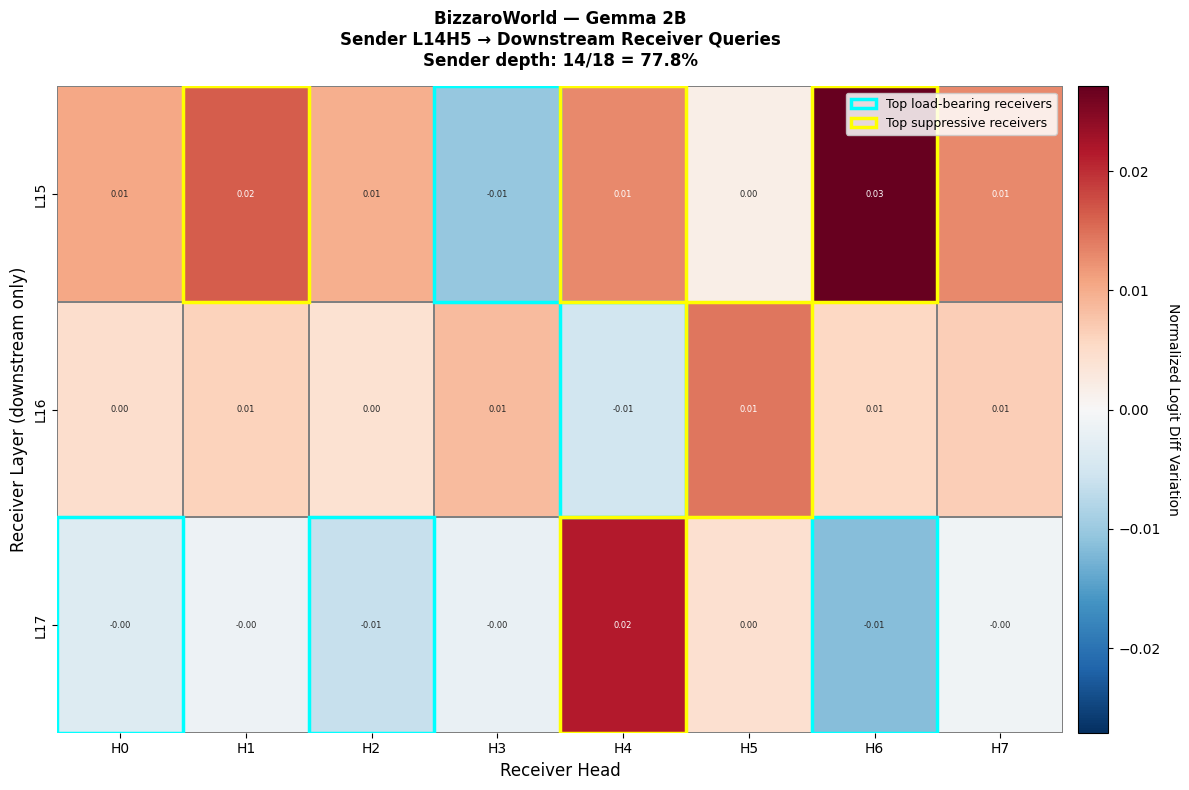

Saved sender_heatmap_gemma_2b_L14H5.png


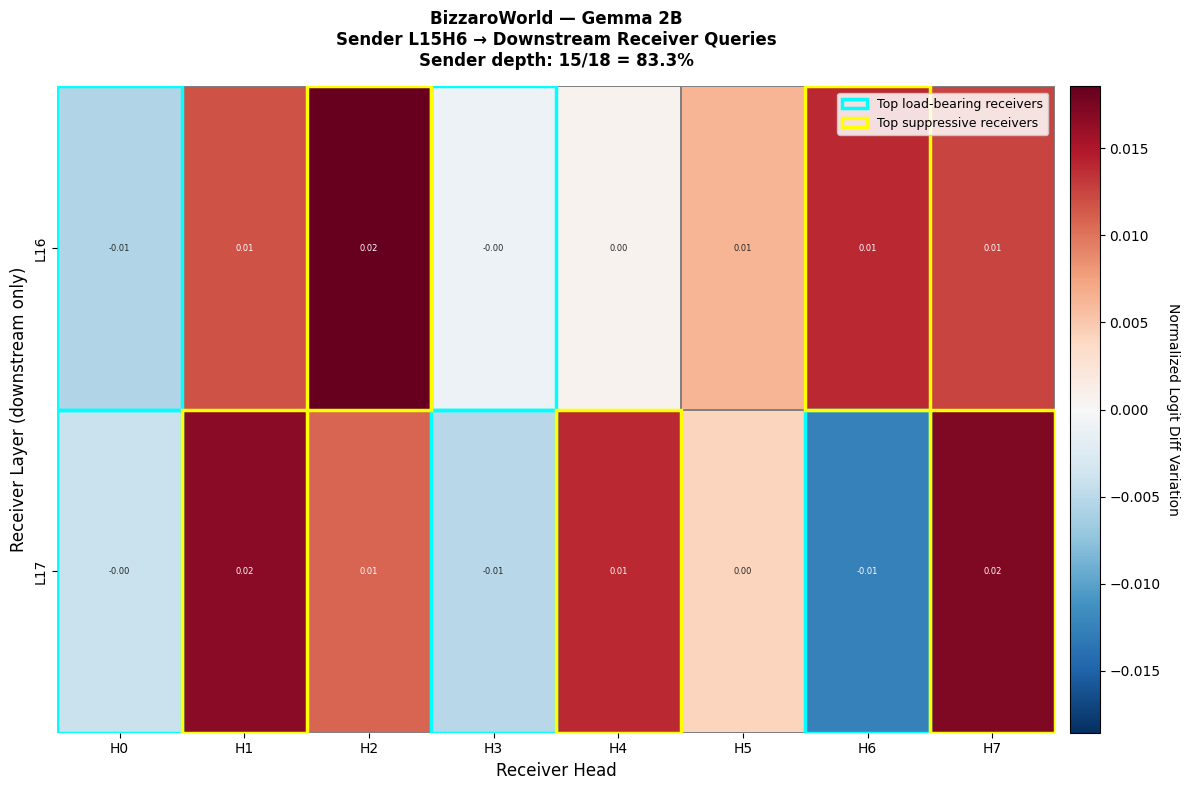

Saved sender_heatmap_gemma_2b_L15H6.png


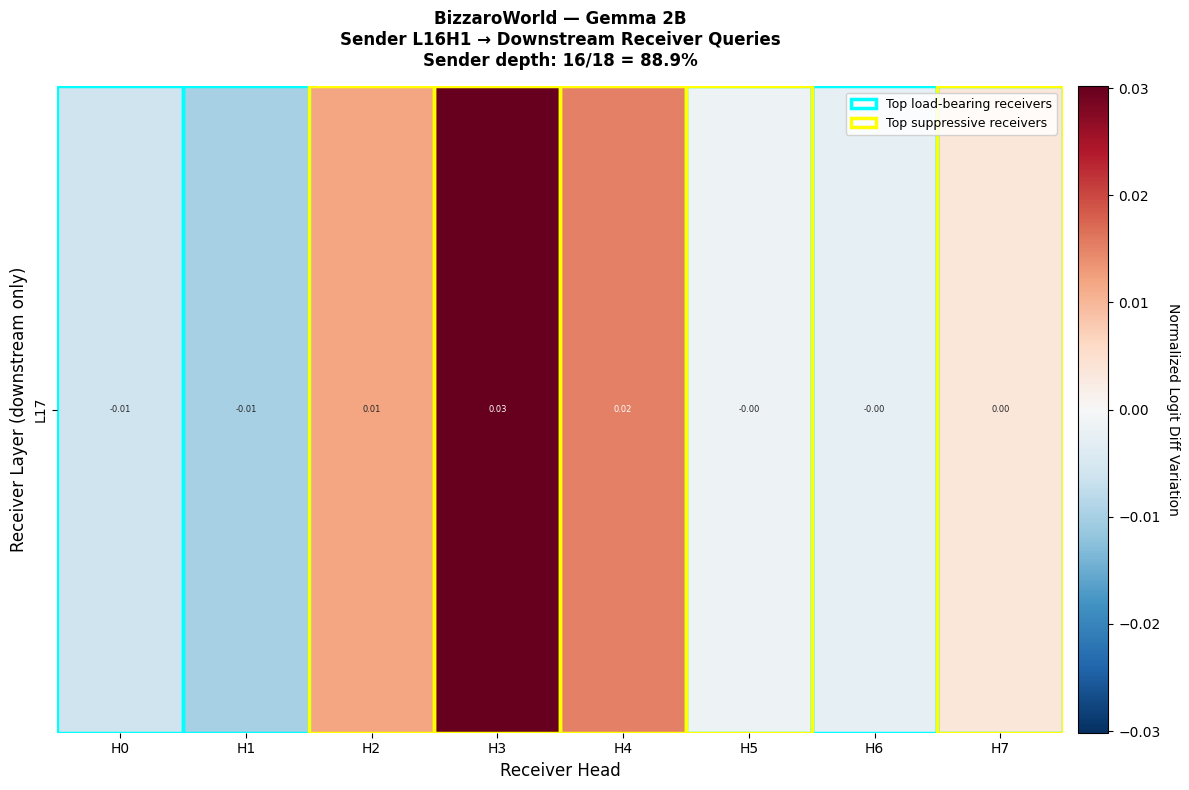

Saved sender_heatmap_gemma_2b_L16H1.png


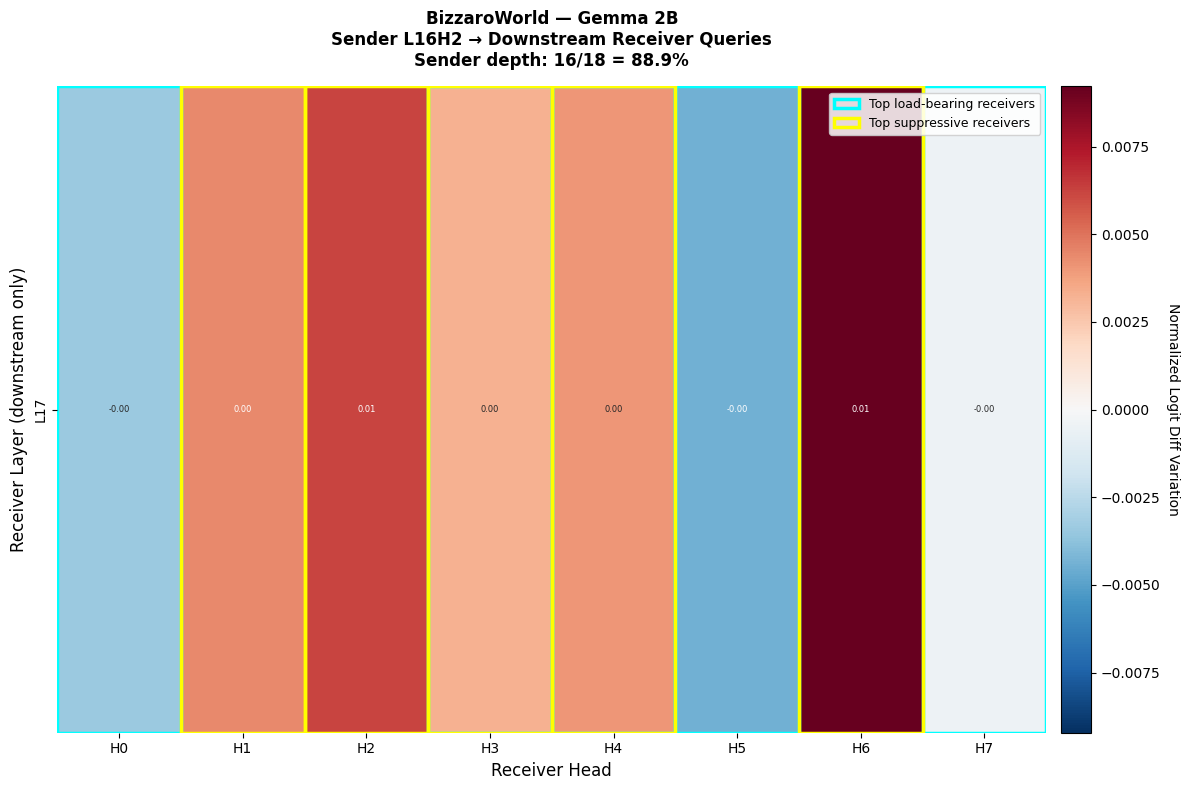

Saved sender_heatmap_gemma_2b_L16H2.png


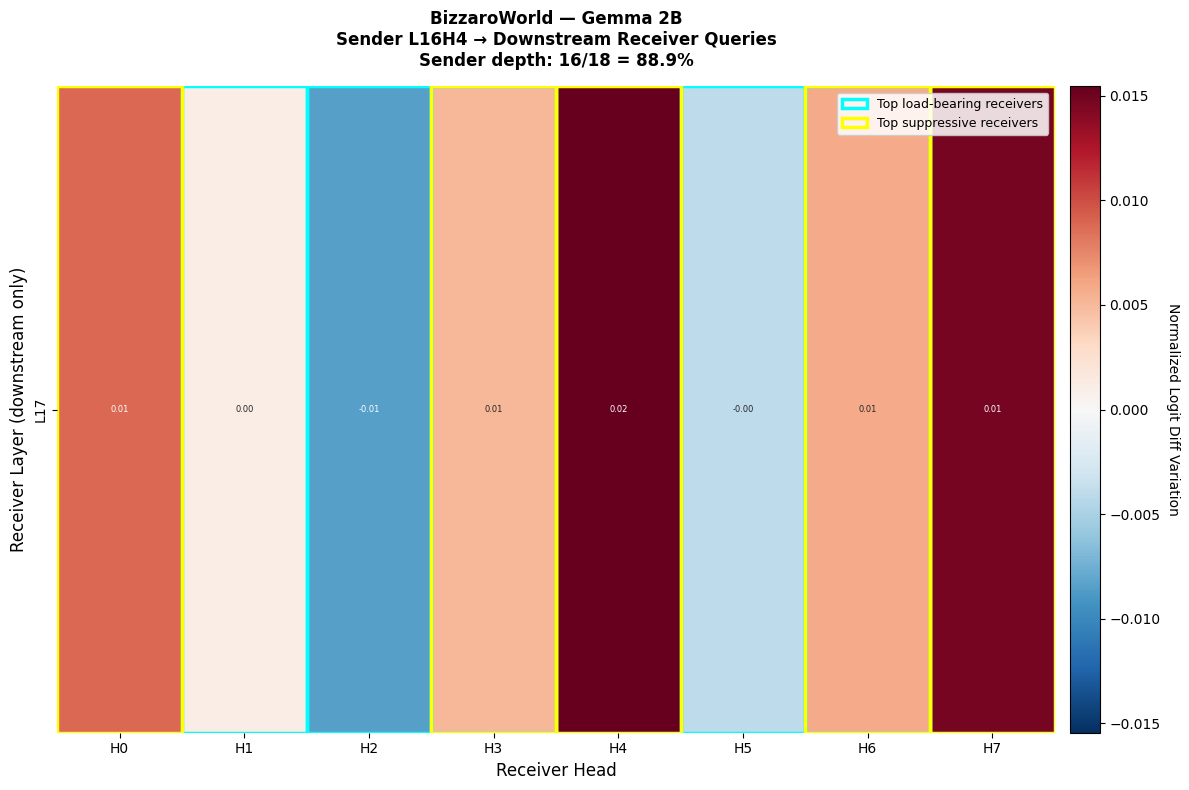

Saved sender_heatmap_gemma_2b_L16H4.png


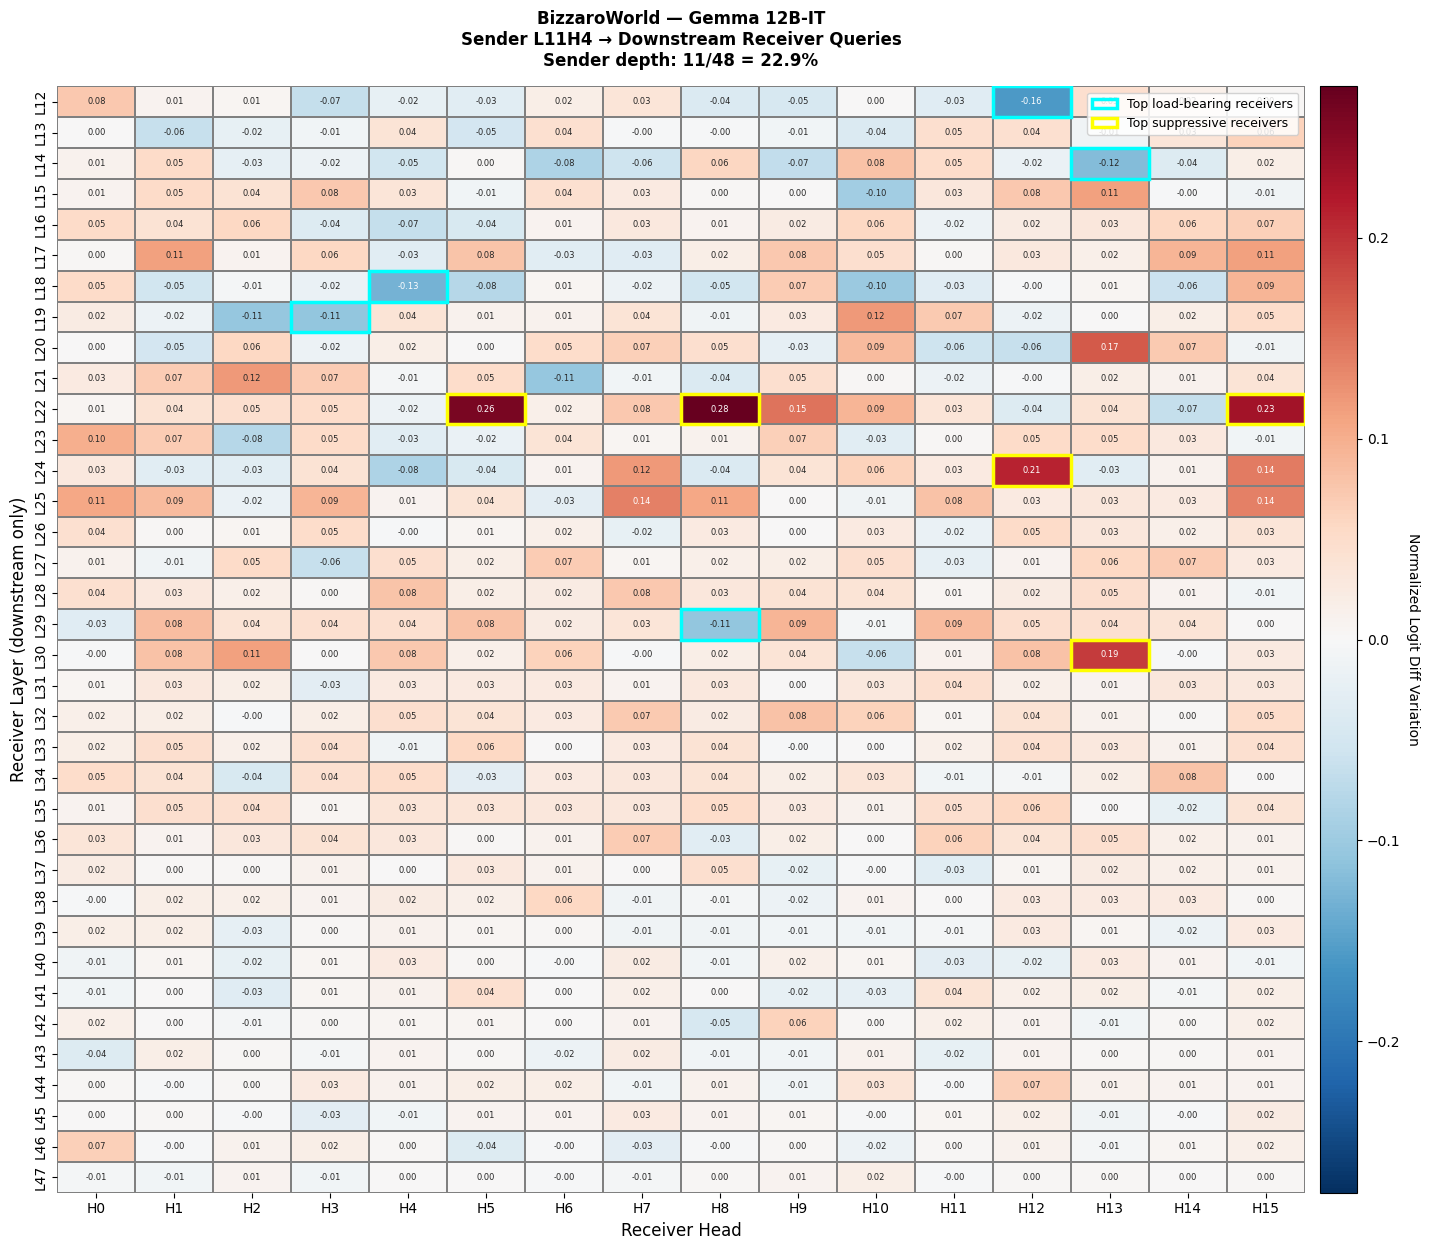

Saved sender_heatmap_gemma_12b_it_L11H4.png


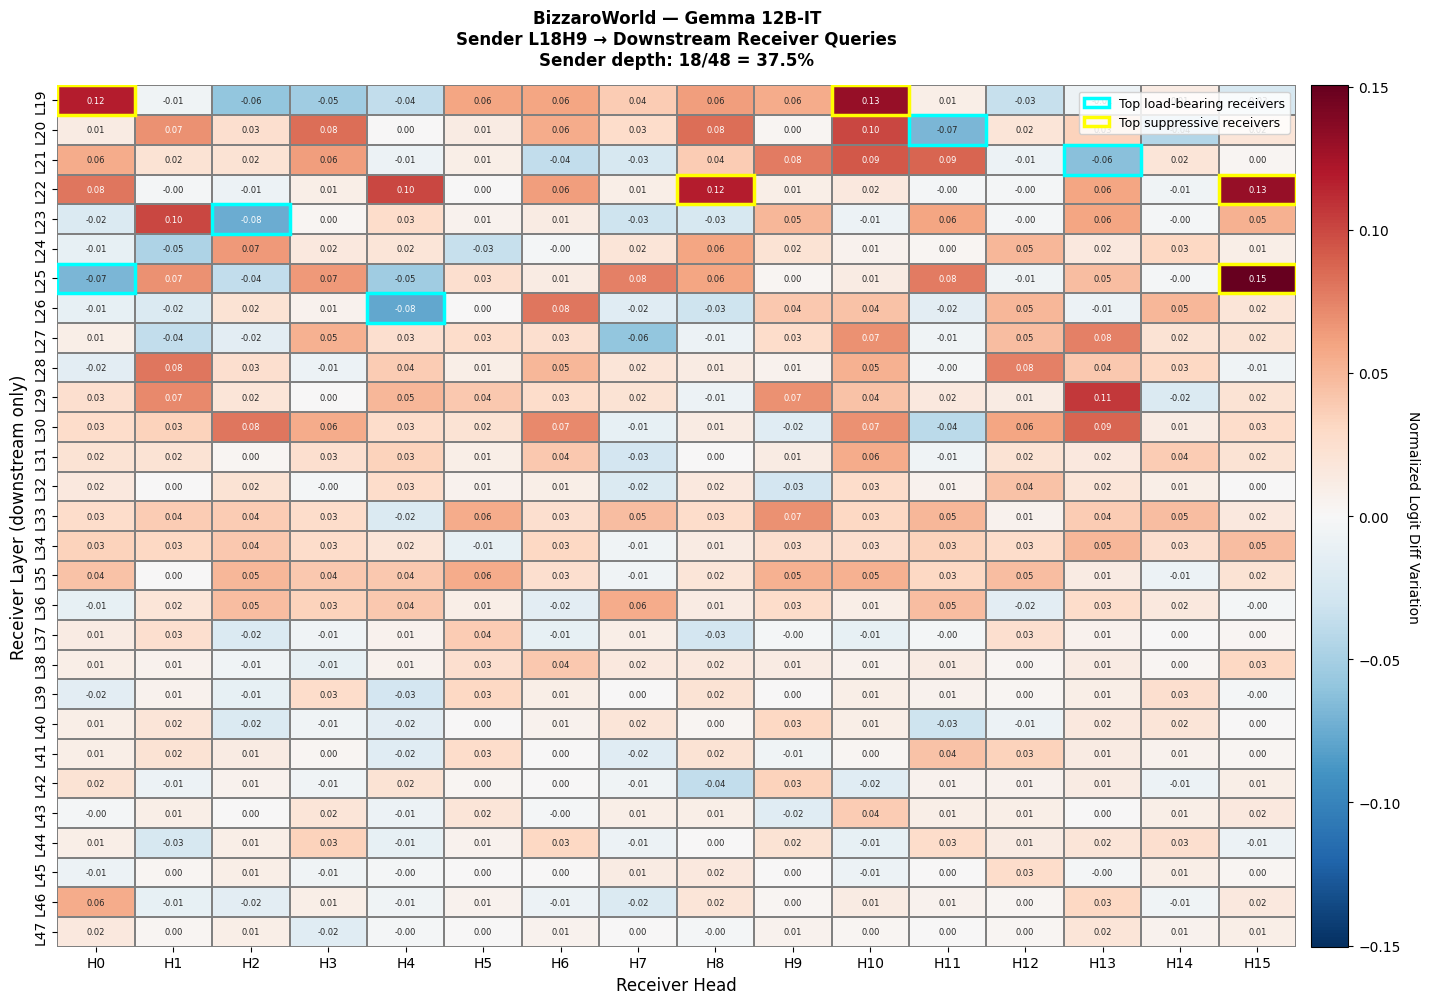

Saved sender_heatmap_gemma_12b_it_L18H9.png


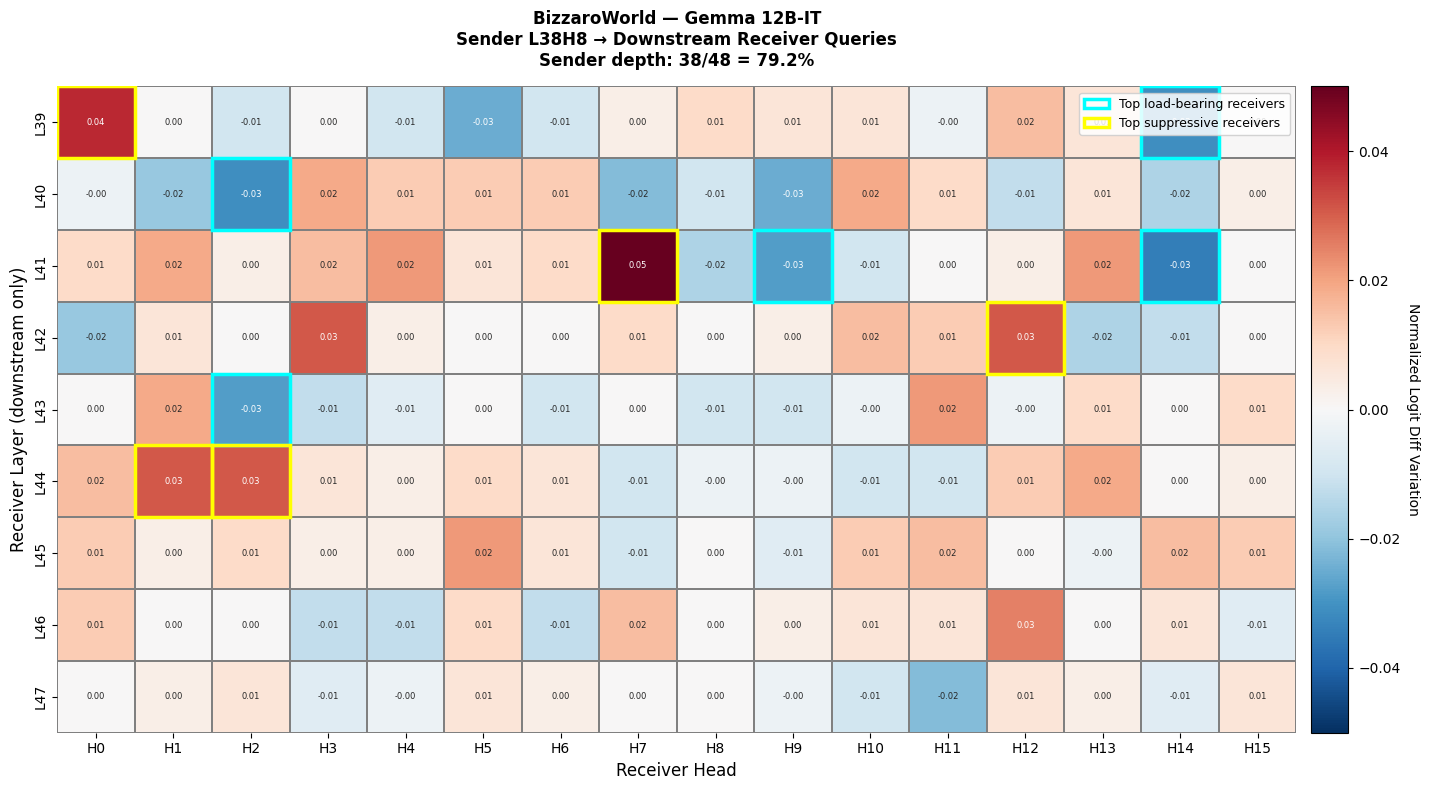

Saved sender_heatmap_gemma_12b_it_L38H8.png


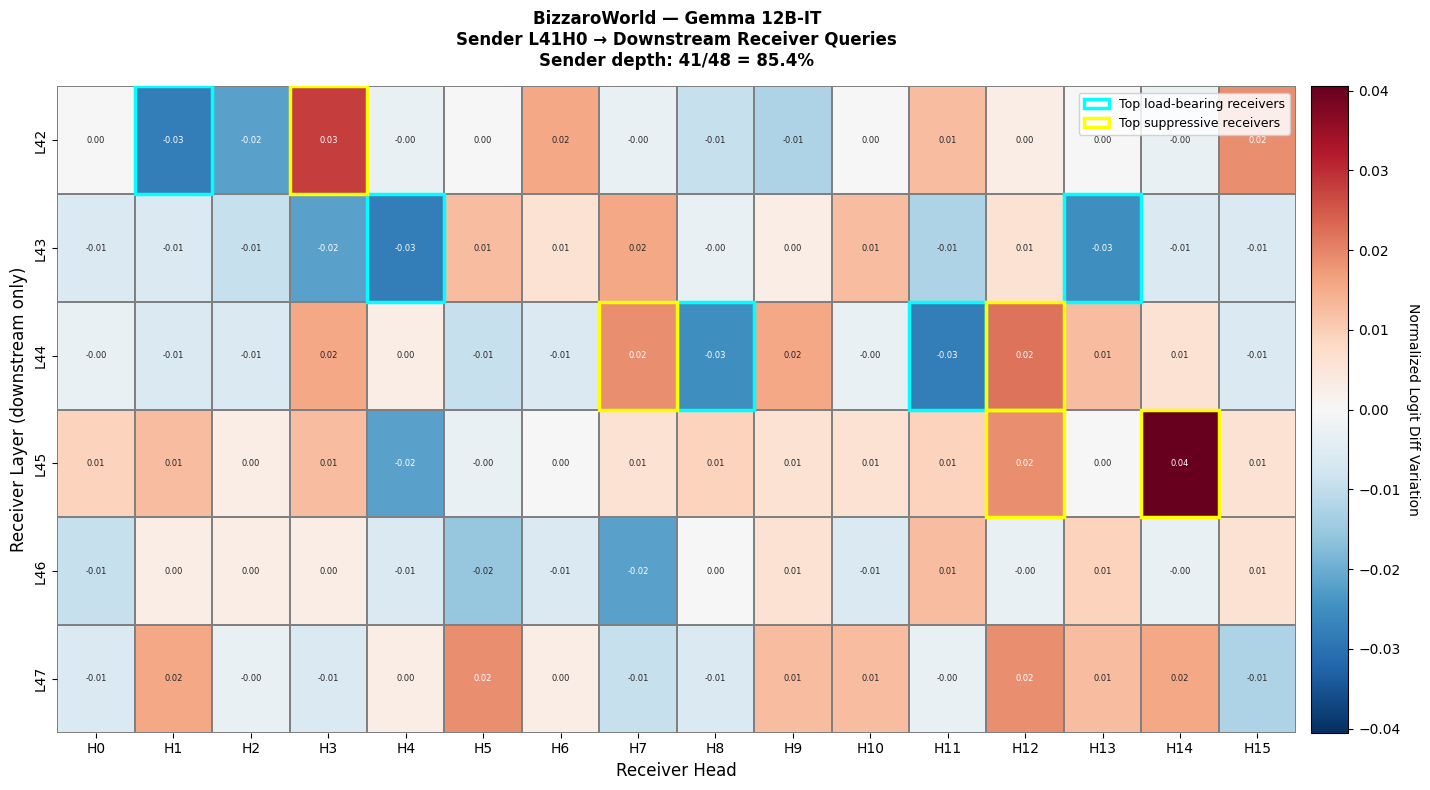

Saved sender_heatmap_gemma_12b_it_L41H0.png


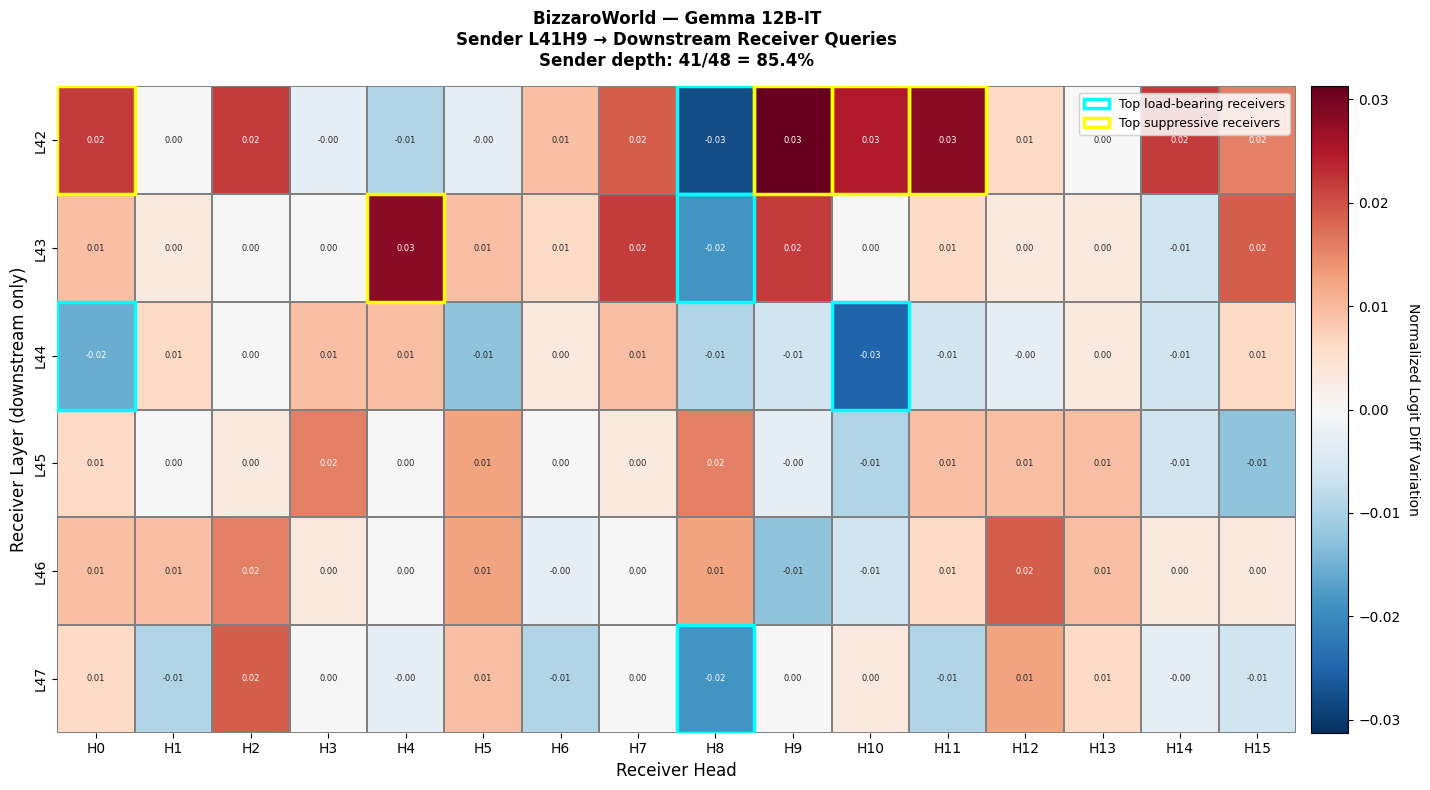

Saved sender_heatmap_gemma_12b_it_L41H9.png


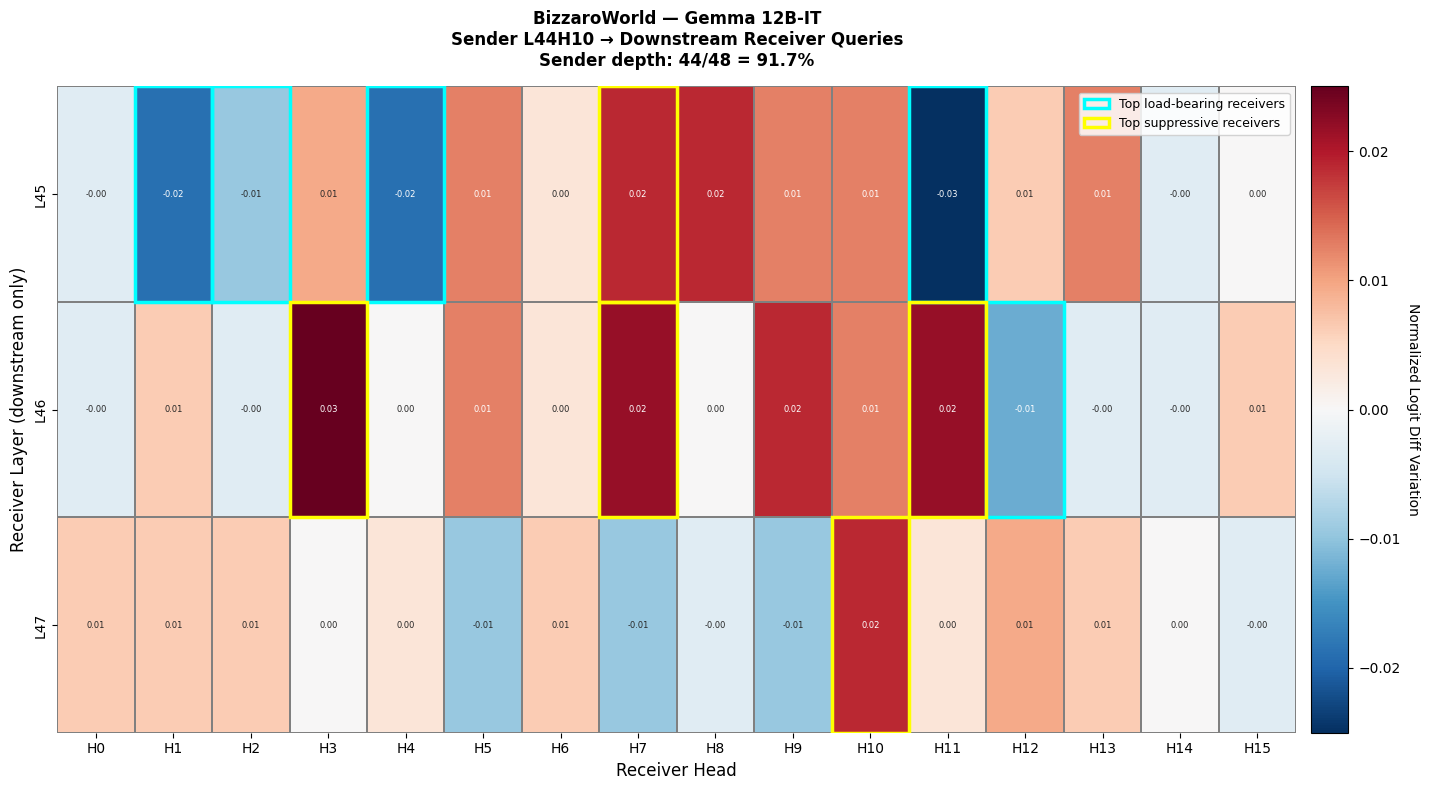

Saved sender_heatmap_gemma_12b_it_L44H10.png


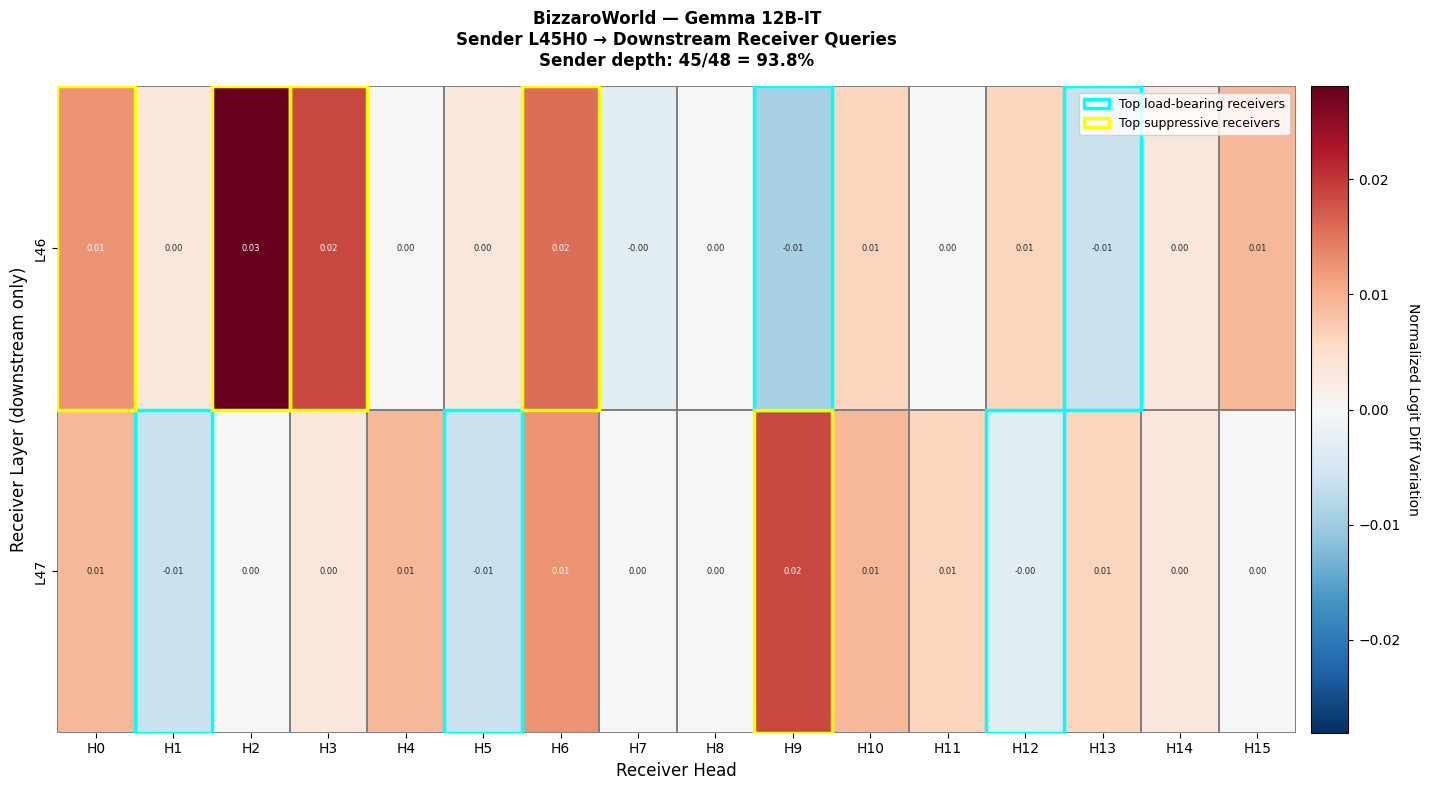

Saved sender_heatmap_gemma_12b_it_L45H0.png


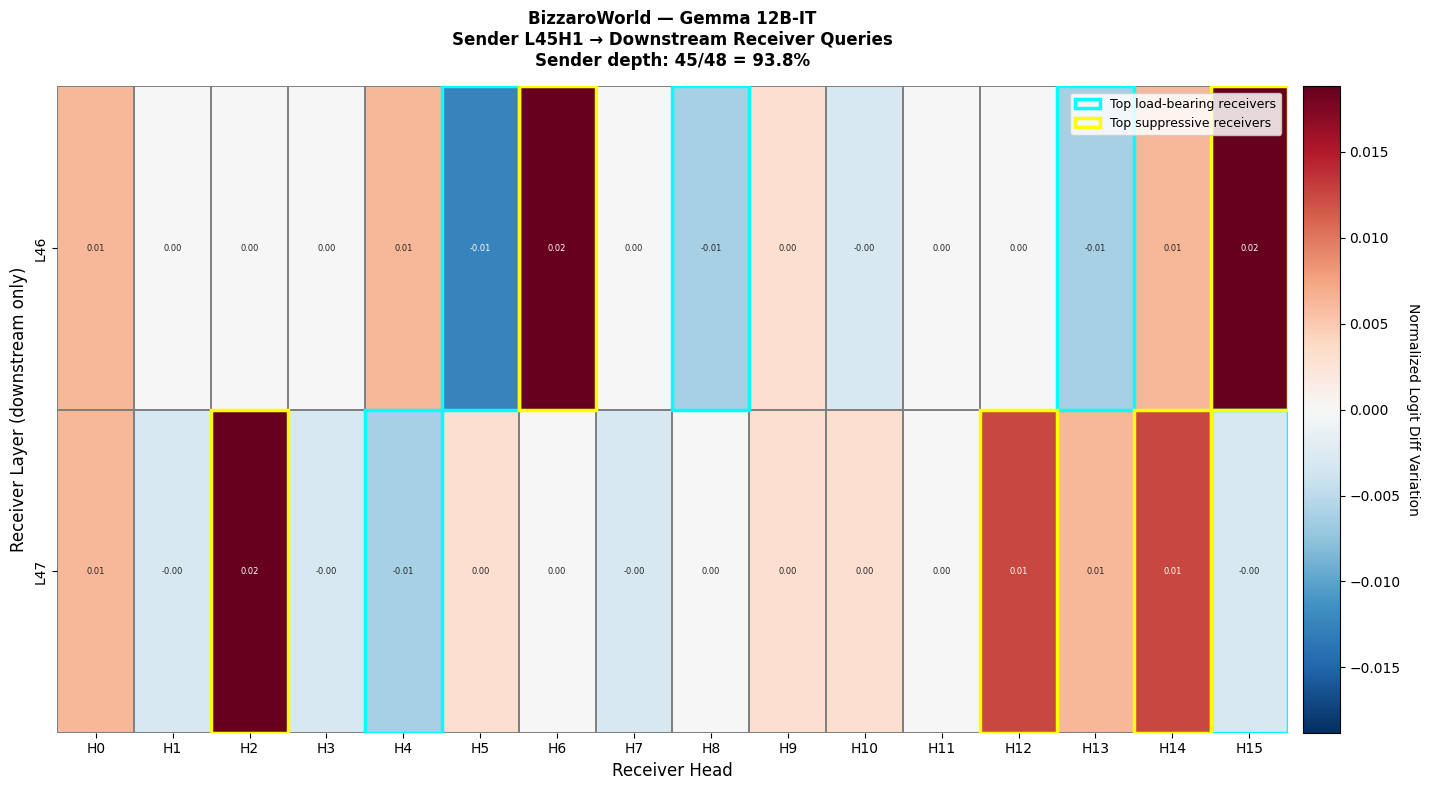

Saved sender_heatmap_gemma_12b_it_L45H1.png


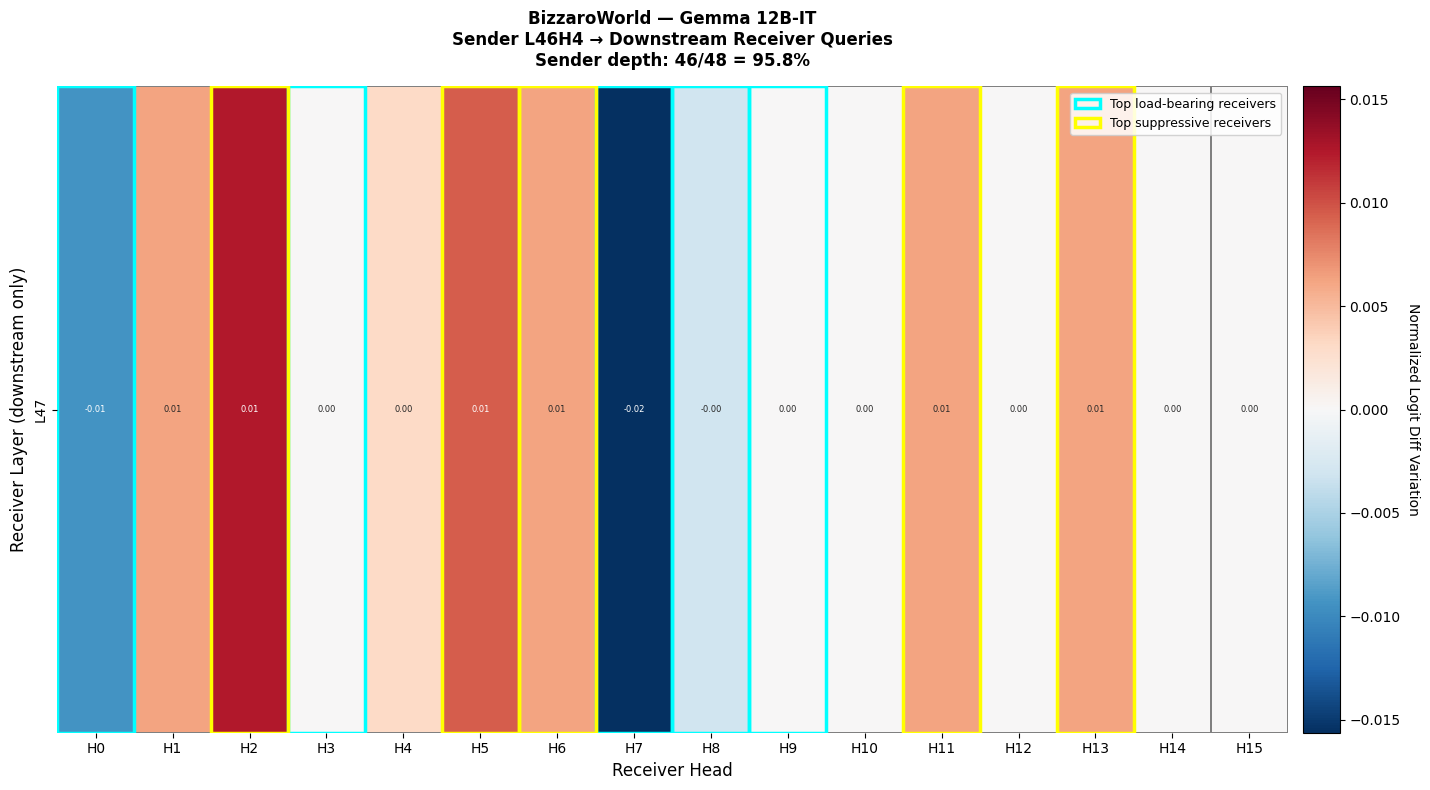

Saved sender_heatmap_gemma_12b_it_L46H4.png


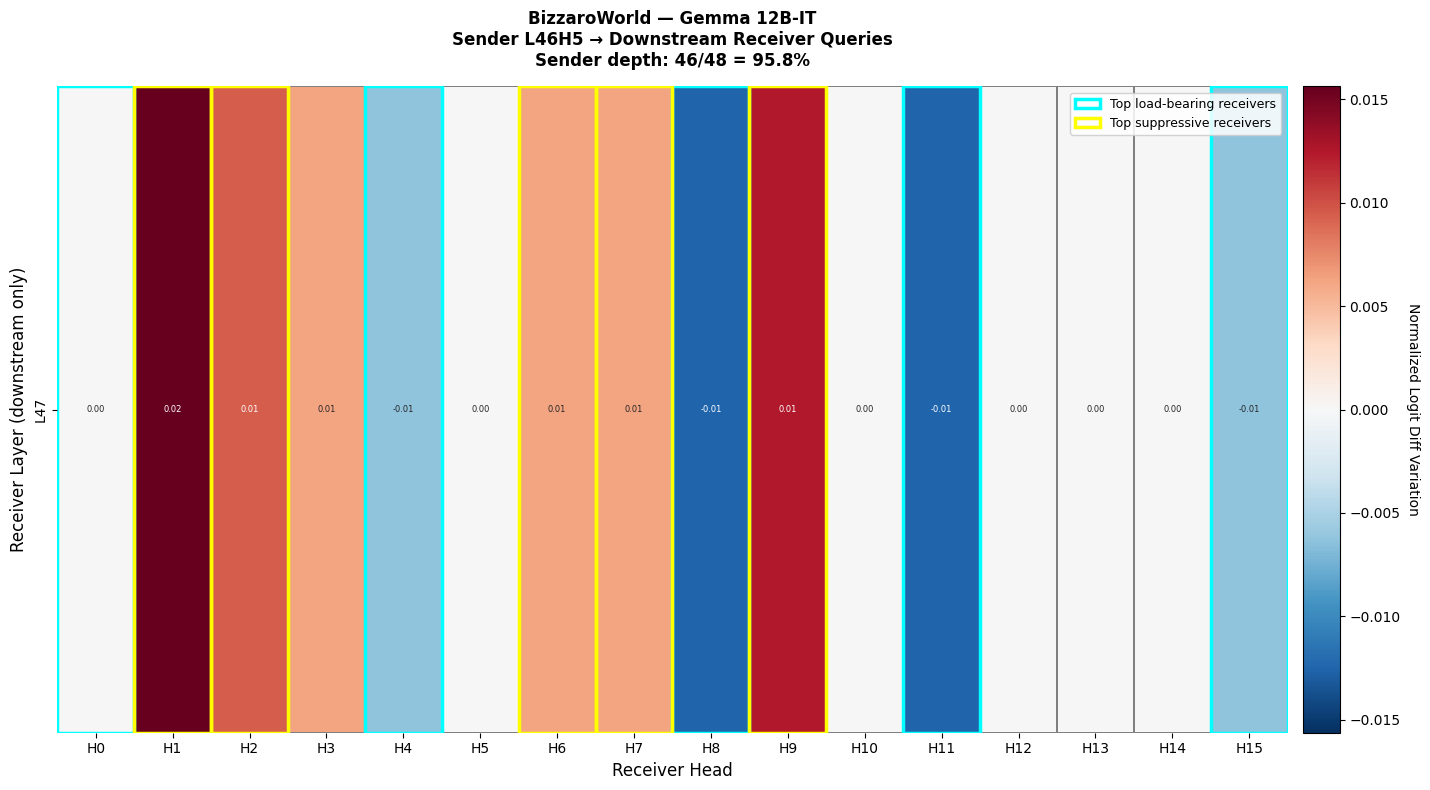

Saved sender_heatmap_gemma_12b_it_L46H5.png


In [16]:
def plot_sender_heatmap(tensor, sender_layer, sender_head_idx, model_name, n_layers_total, top_n=5):
    n_downstream, n_heads = tensor.shape
    actual_layers = list(range(sender_layer + 1, sender_layer + 1 + n_downstream))
    safe_name = model_name.lower().replace(" ", "_").replace("-", "_")
    filename = f"sender_heatmap_{safe_name}_L{sender_layer}H{sender_head_idx}.png"

    fig, ax = plt.subplots(figsize=(max(12, n_heads * 0.9), max(8, n_downstream * 0.35)))
    vmax = max(float(np.abs(tensor).max()), 1e-6)

    sns.heatmap(
        tensor, ax=ax,
        cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
        annot=(n_heads <= 16 and n_downstream <= 50),
        fmt=".2f", annot_kws={"size": 6},
        xticklabels=[f"H{i}" for i in range(n_heads)],
        yticklabels=[f"L{l}" for l in actual_layers],
        linewidths=0.2, linecolor="gray",
        cbar=False
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.15)
    plt.colorbar(
        plt.cm.ScalarMappable(
            norm=plt.Normalize(vmin=-vmax, vmax=vmax),
            cmap="RdBu_r"
        ),
        cax=cax,
        label="Normalized Logit Diff Variation"
    )
    cax.yaxis.label.set_rotation(270)
    cax.yaxis.label.set_va("bottom")

    flat = tensor.flatten()
    for idx in np.argsort(flat)[:top_n]:
        row, col = divmod(int(idx), n_heads)
        ax.add_patch(plt.Rectangle((col, row), 1, 1, fill=False, edgecolor="cyan", lw=2.5))
    for idx in np.argsort(flat)[-top_n:]:
        row, col = divmod(int(idx), n_heads)
        ax.add_patch(plt.Rectangle((col, row), 1, 1, fill=False, edgecolor="yellow", lw=2.5))

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor="none", edgecolor="cyan", lw=2.5, label="Top load-bearing receivers"),
        Patch(facecolor="none", edgecolor="yellow", lw=2.5, label="Top suppressive receivers"),
    ], loc="upper right", fontsize=9, framealpha=0.85)

    ax.set_title(
        f"BizzaroWorld — {model_name}\n"
        f"Sender L{sender_layer}H{sender_head_idx} → Downstream Receiver Queries\n"
        f"Sender depth: {sender_layer}/{n_layers_total} = {sender_layer/n_layers_total:.1%}",
        fontsize=12, fontweight="bold", pad=15
    )
    ax.set_xlabel("Receiver Head", fontsize=12)
    ax.set_ylabel("Receiver Layer (downstream only)", fontsize=12)

    plt.tight_layout()
    plt.savefig(VISUALS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")

if sender_2b:
    for (sl, sh), tensor in sorted(sender_2b.items()):
        plot_sender_heatmap(tensor, sl, sh, "Gemma 2B", 18)
else:
    print("No 2B sender data yet — run Colab commands from Cell K first.")

if sender_12b:
    for (sl, sh), tensor in sorted(sender_12b.items()):
        plot_sender_heatmap(tensor, sl, sh, "Gemma 12B-IT", 48)
else:
    print("No 12B sender data yet — run Colab commands from Cell K first.")

/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1462745881.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


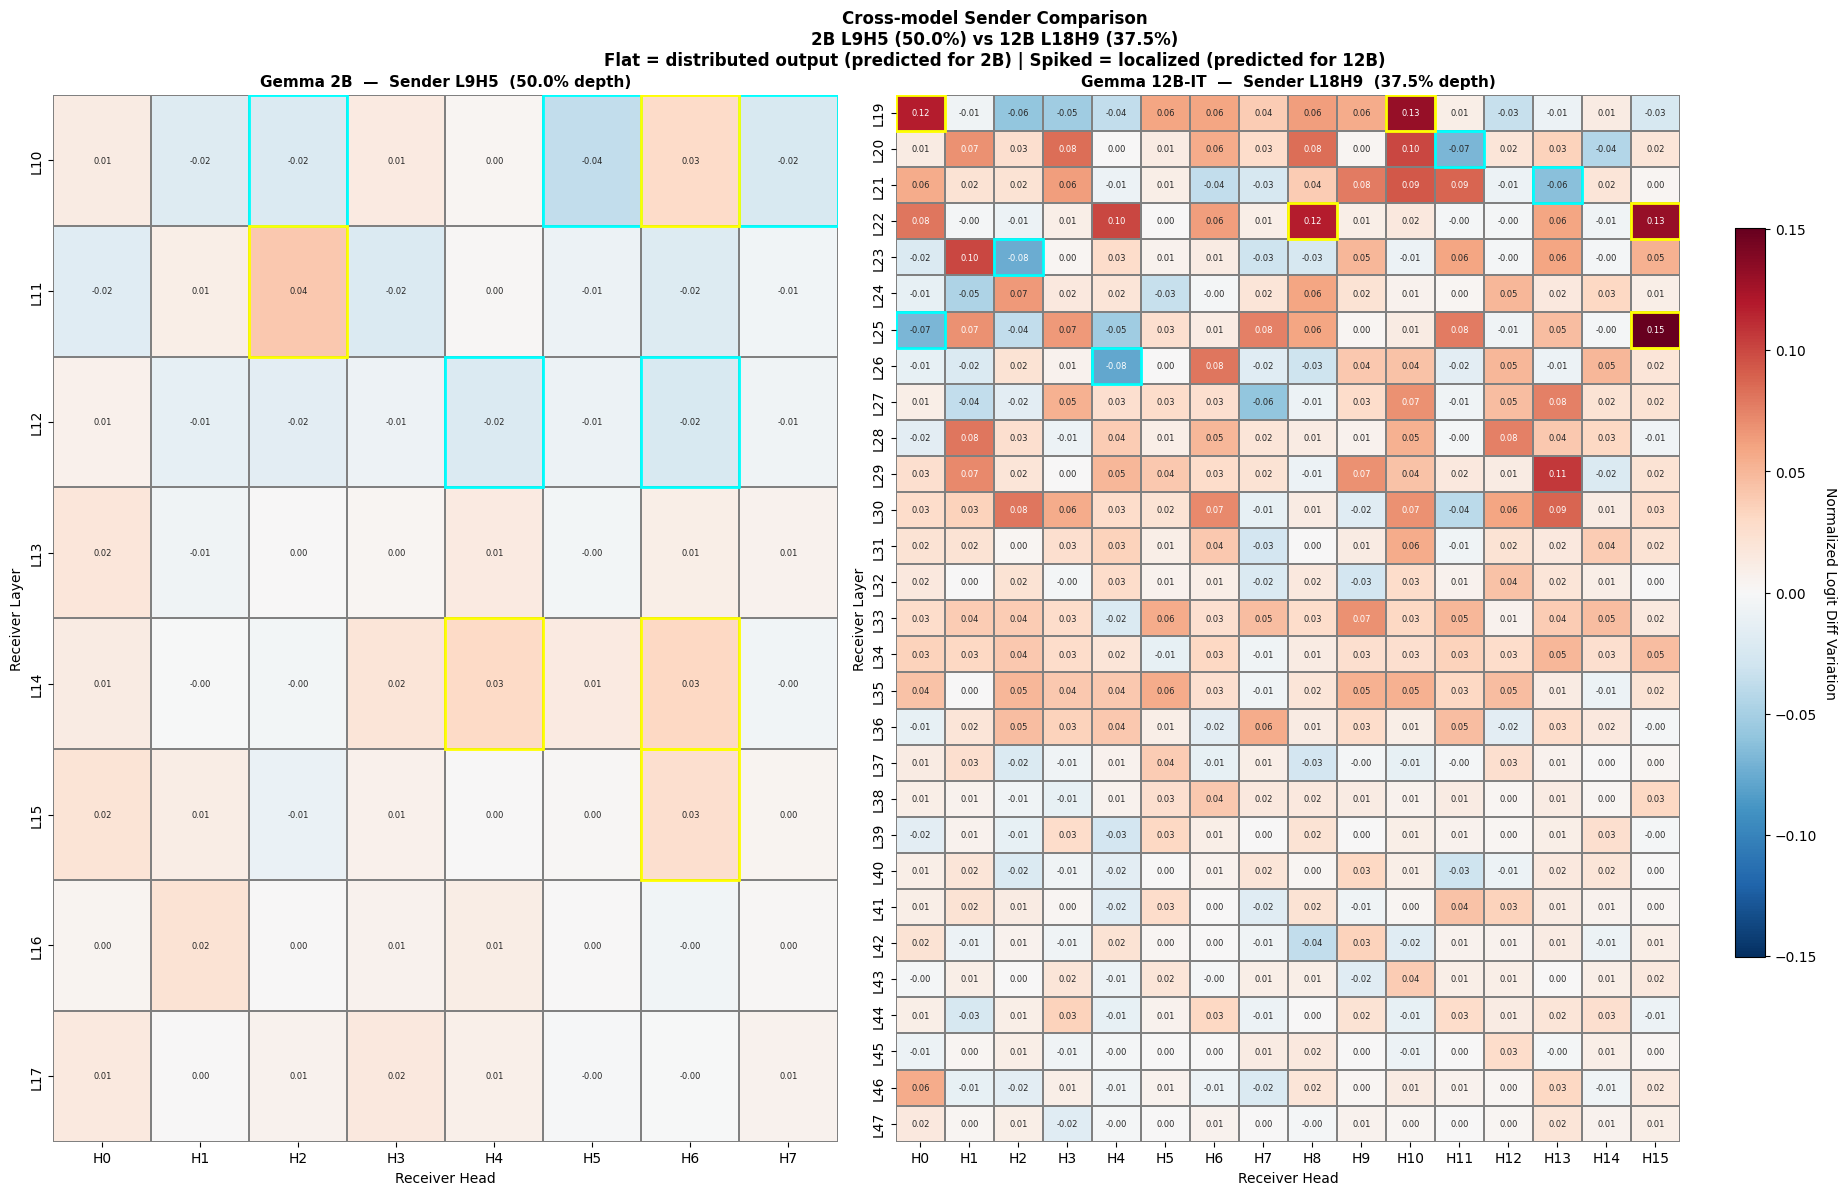

Saved sender_compare_2bL9H5_12bL18H9.png


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1462745881.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


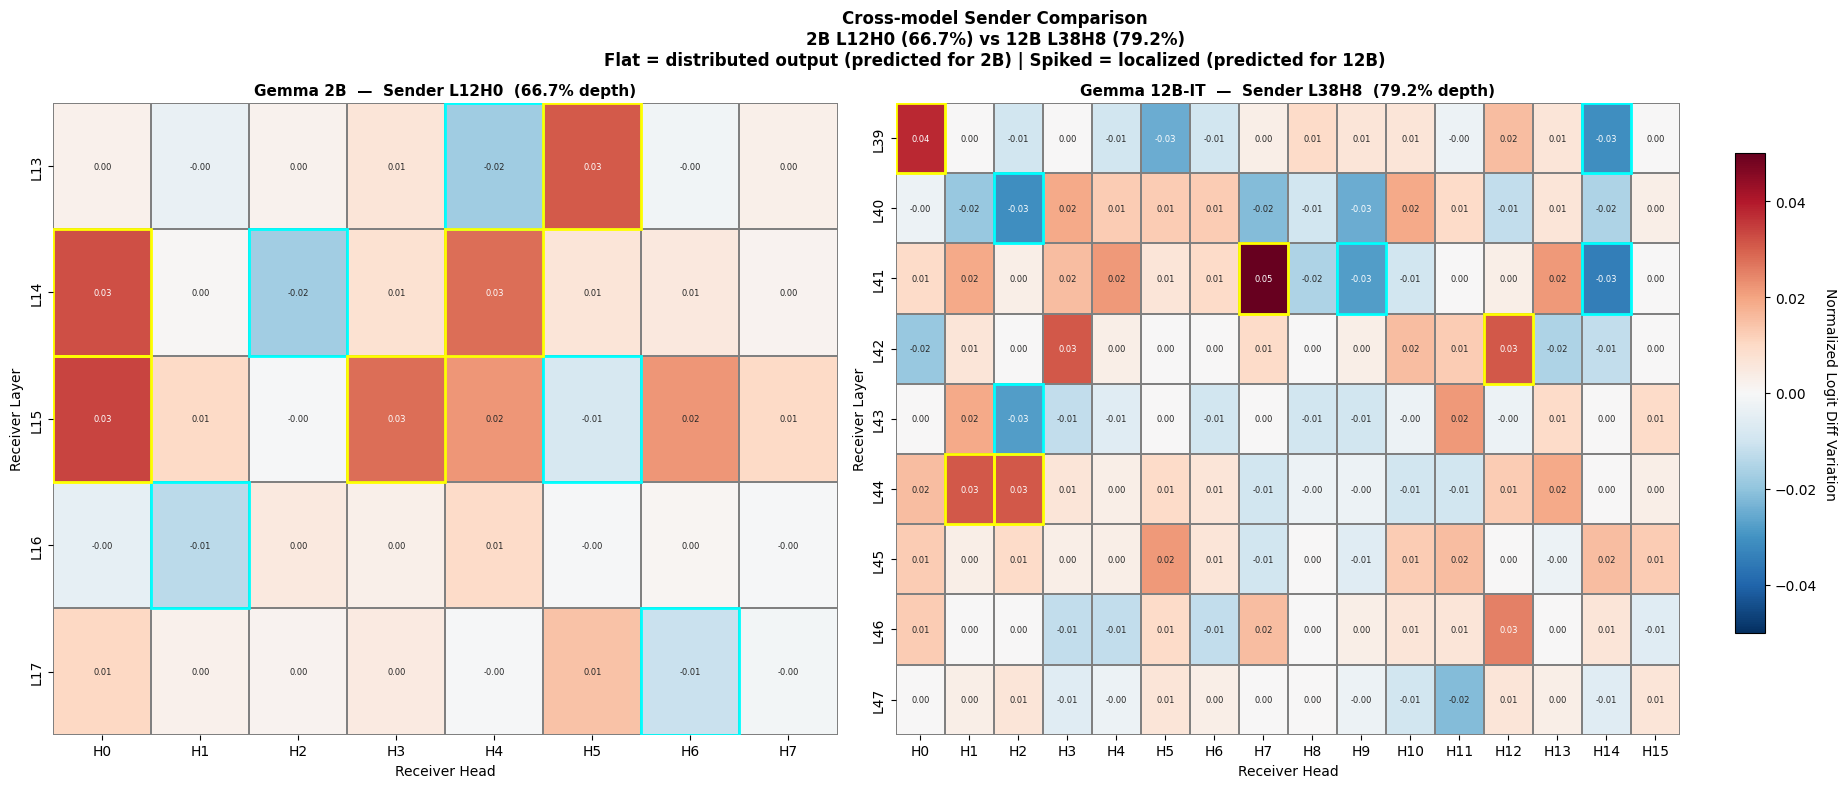

Saved sender_compare_2bL12H0_12bL38H8.png


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1462745881.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


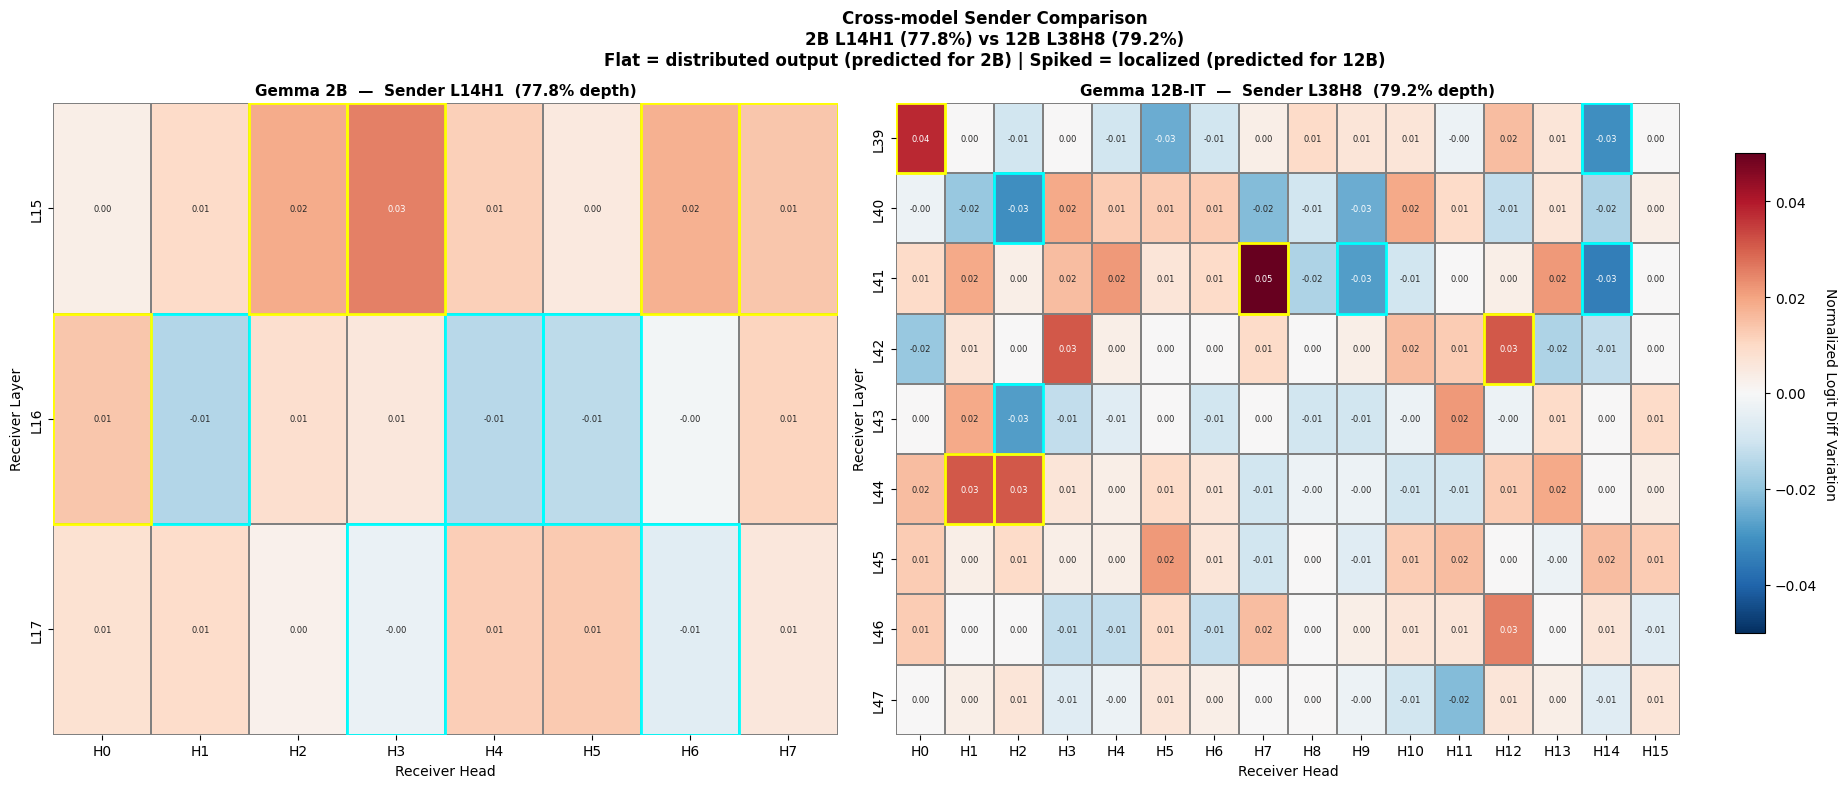

Saved sender_compare_2bL14H1_12bL38H8.png


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1462745881.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


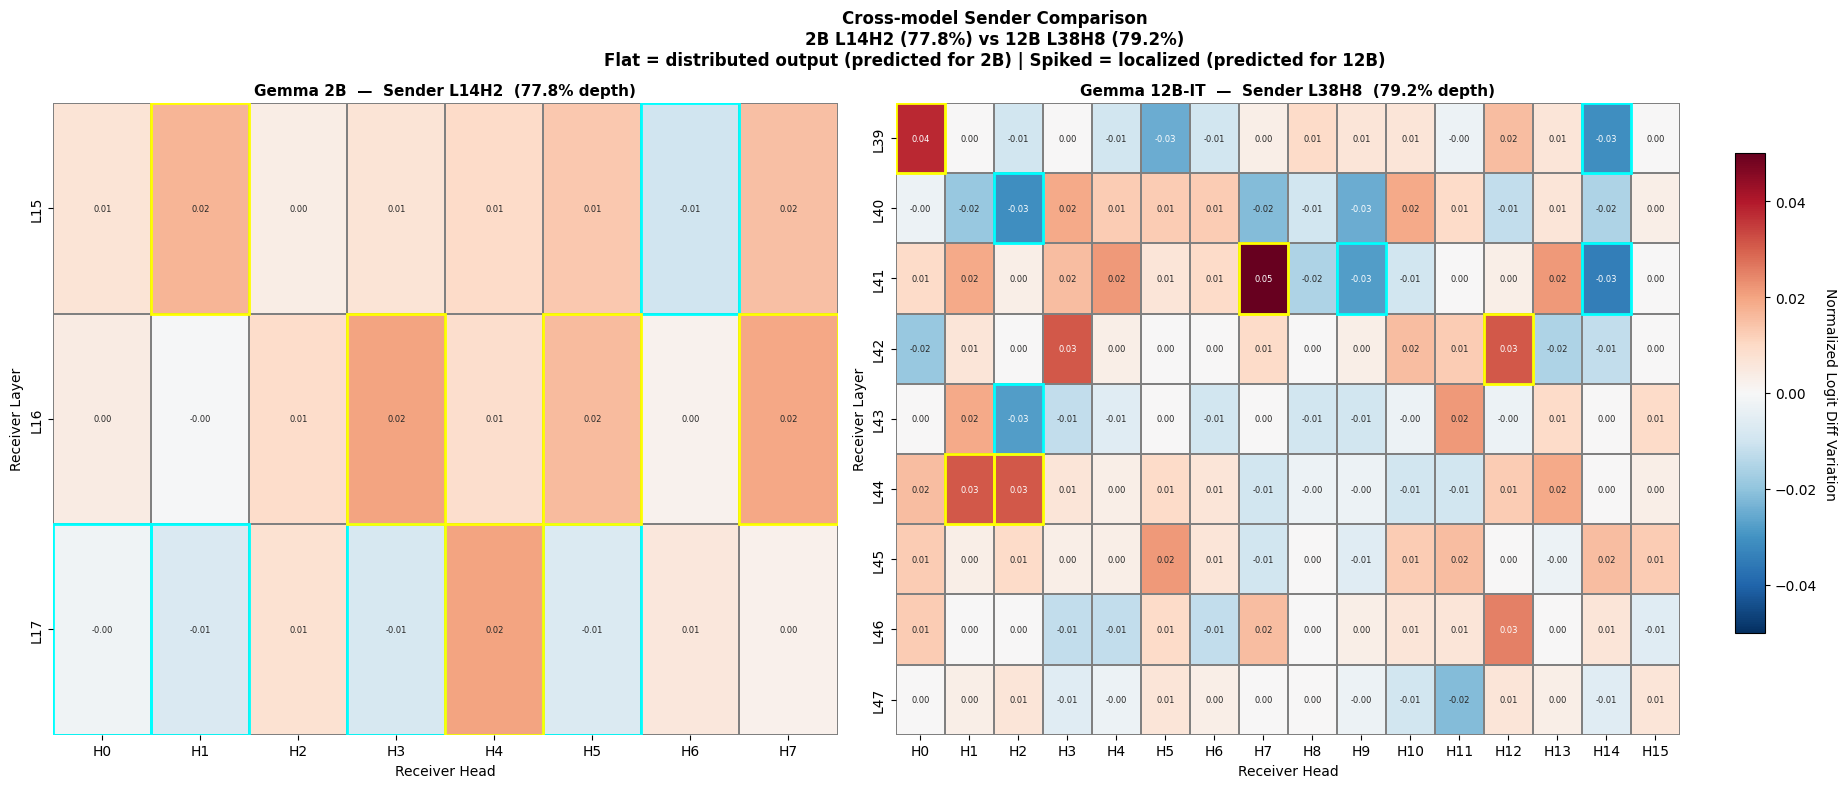

Saved sender_compare_2bL14H2_12bL38H8.png


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1462745881.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


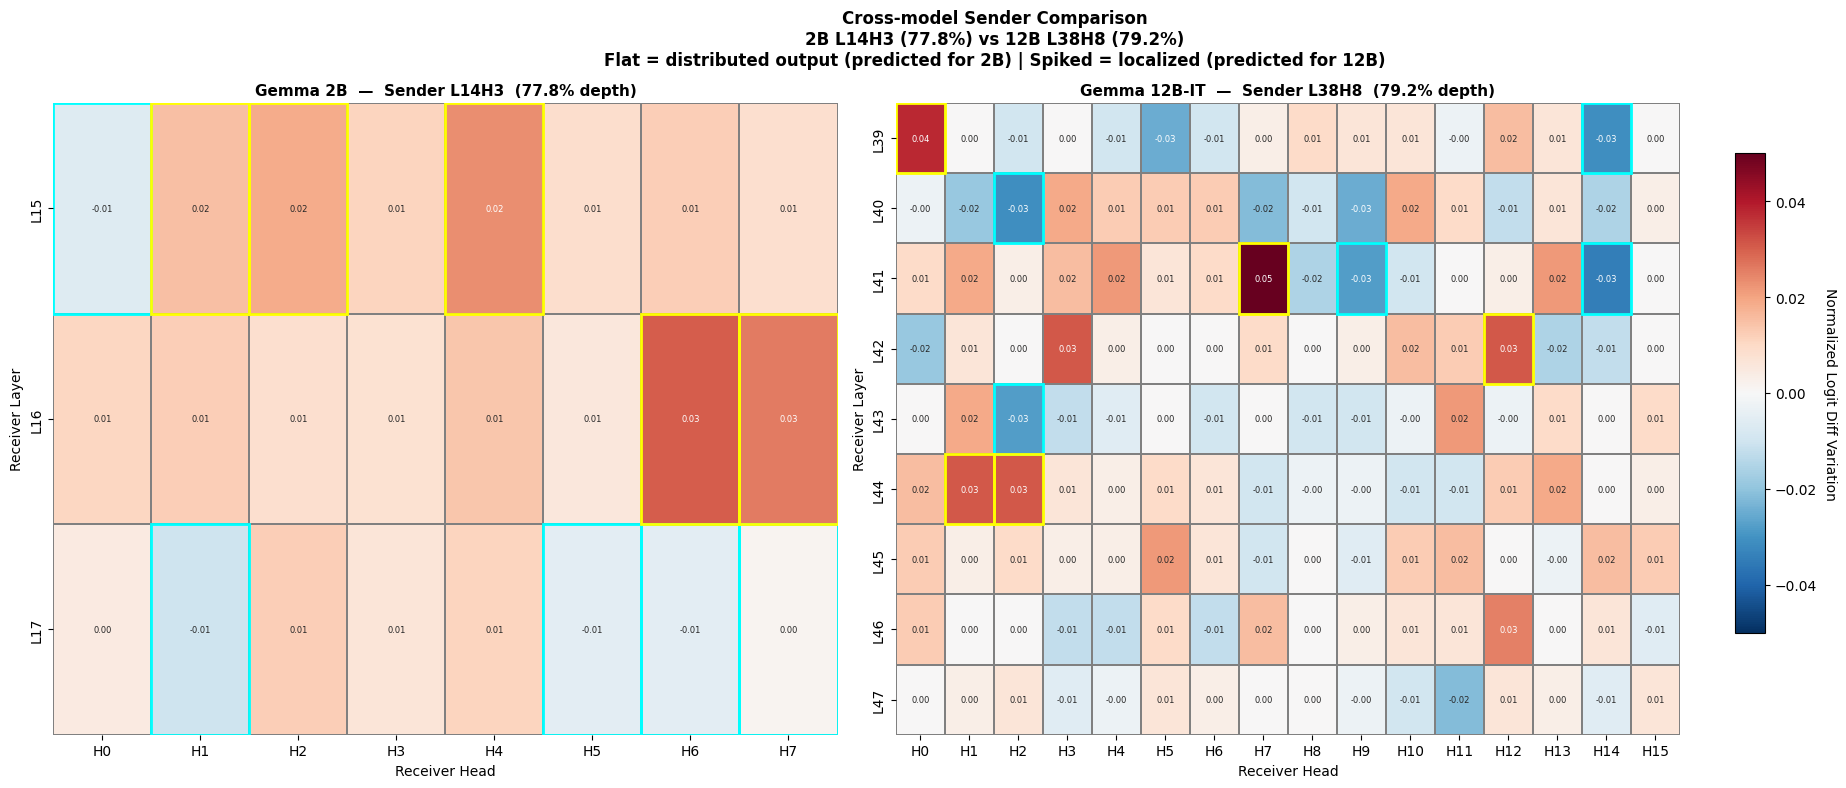

Saved sender_compare_2bL14H3_12bL38H8.png


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1462745881.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


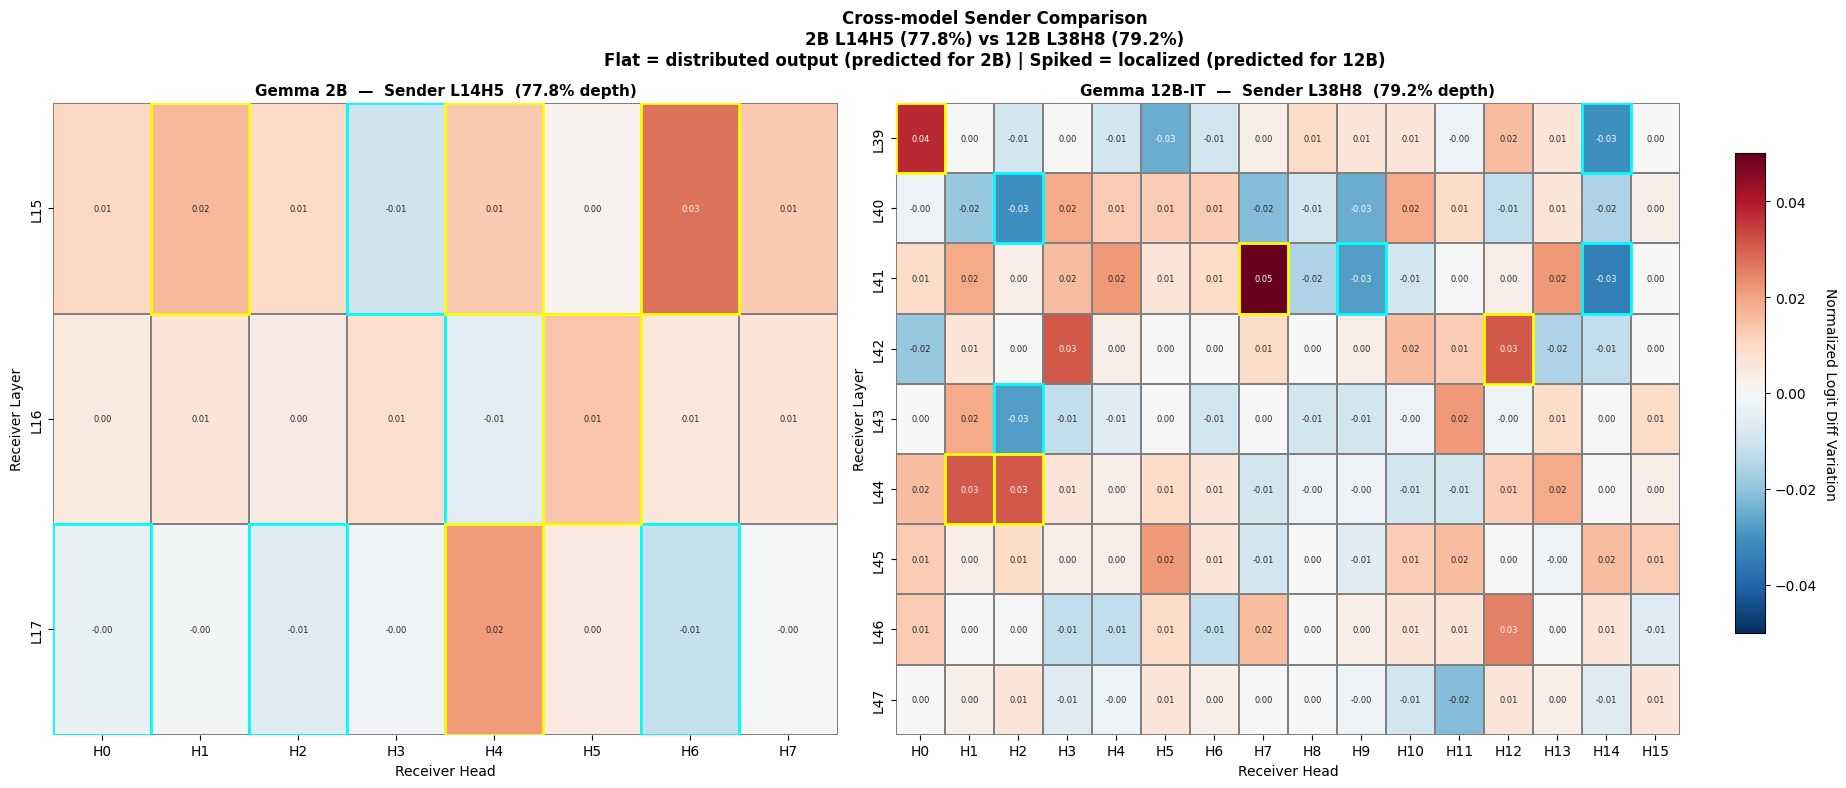

Saved sender_compare_2bL14H5_12bL38H8.png


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1462745881.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


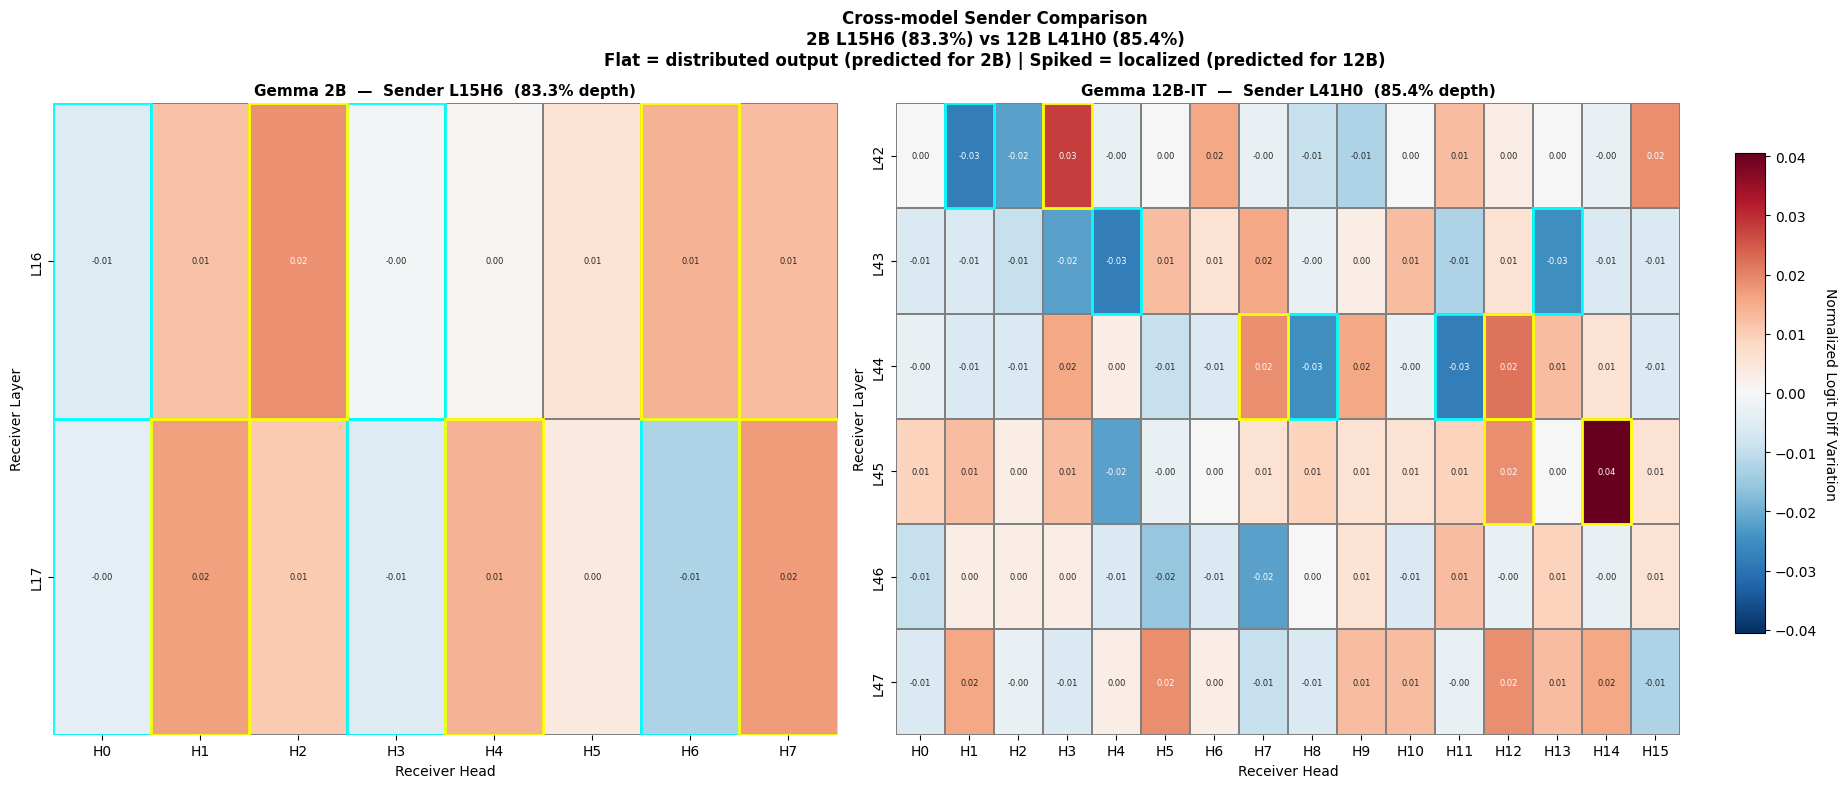

Saved sender_compare_2bL15H6_12bL41H0.png


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1462745881.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


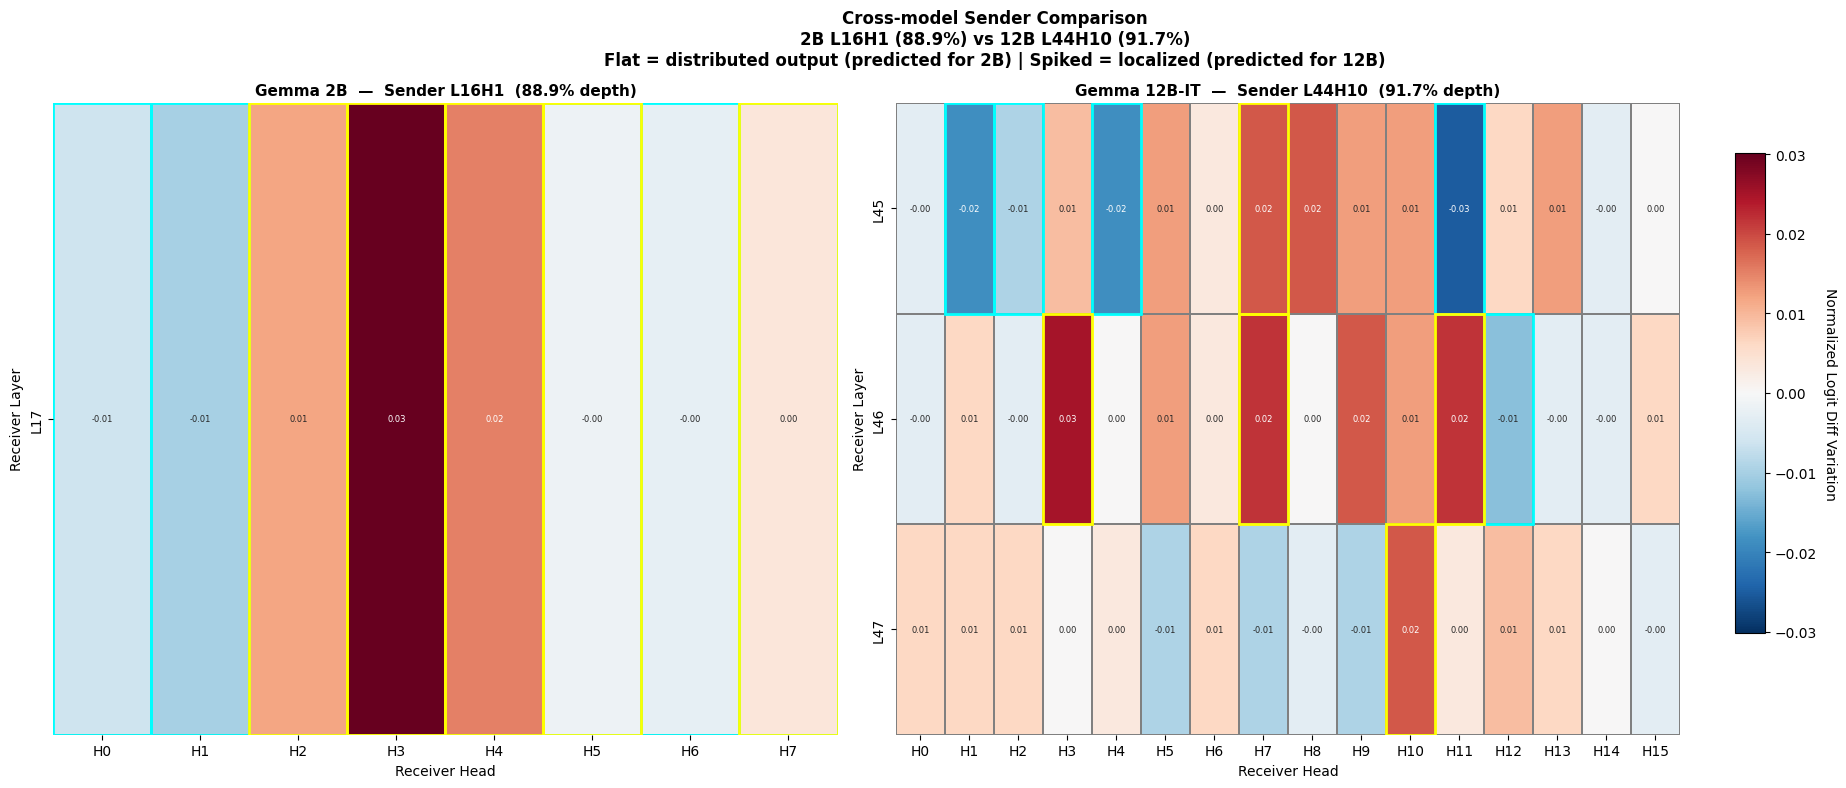

Saved sender_compare_2bL16H1_12bL44H10.png


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1462745881.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


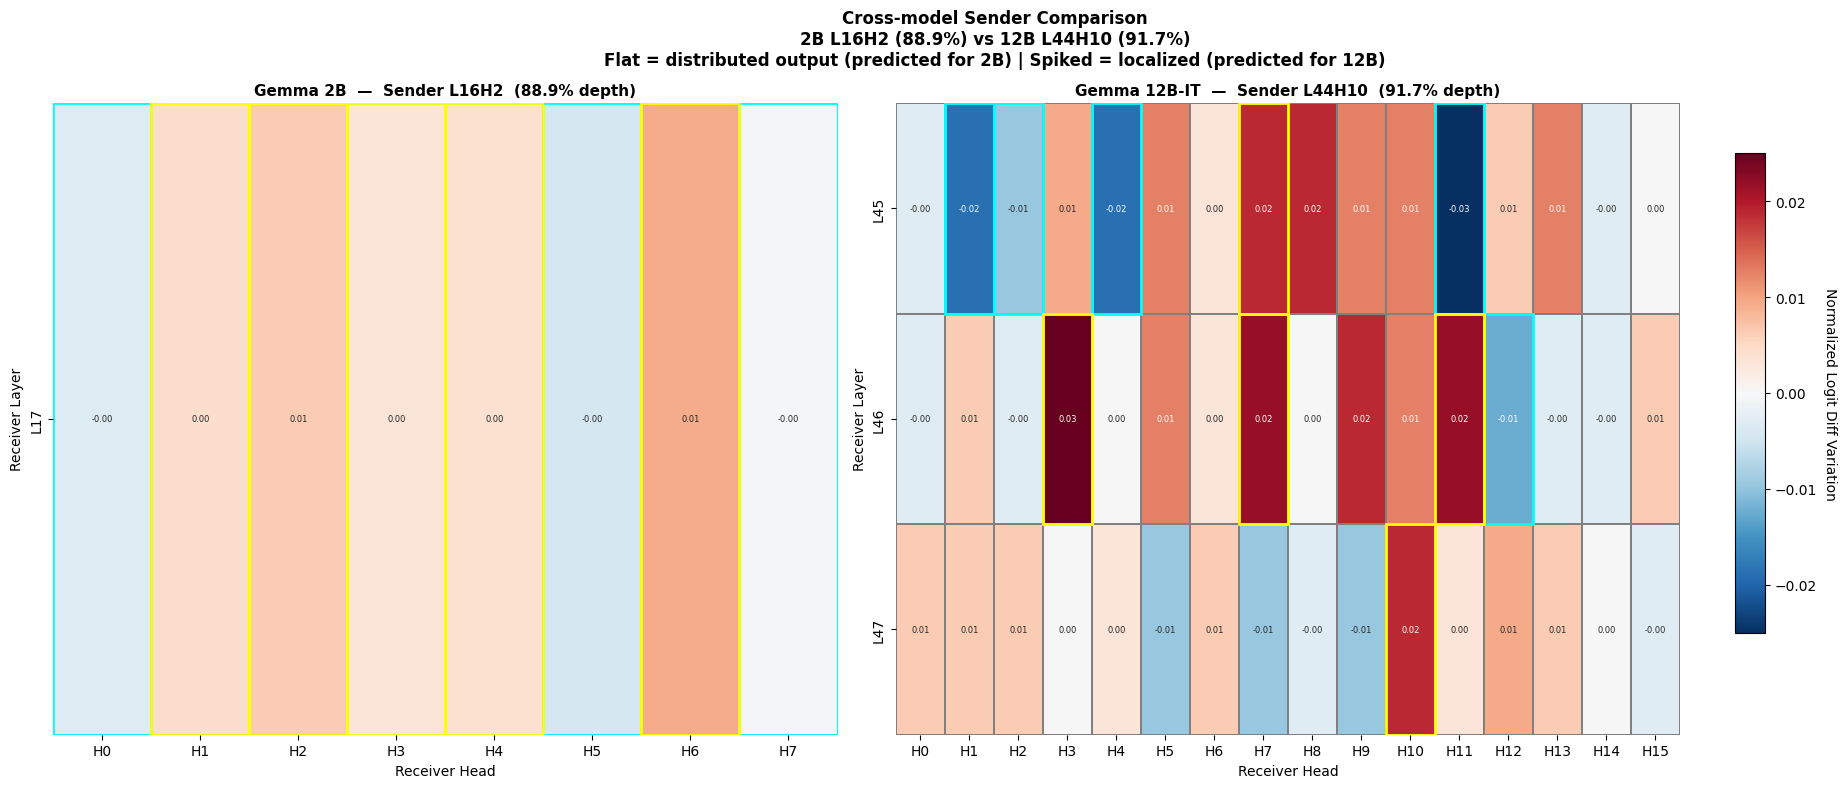

Saved sender_compare_2bL16H2_12bL44H10.png


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_4470/1462745881.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


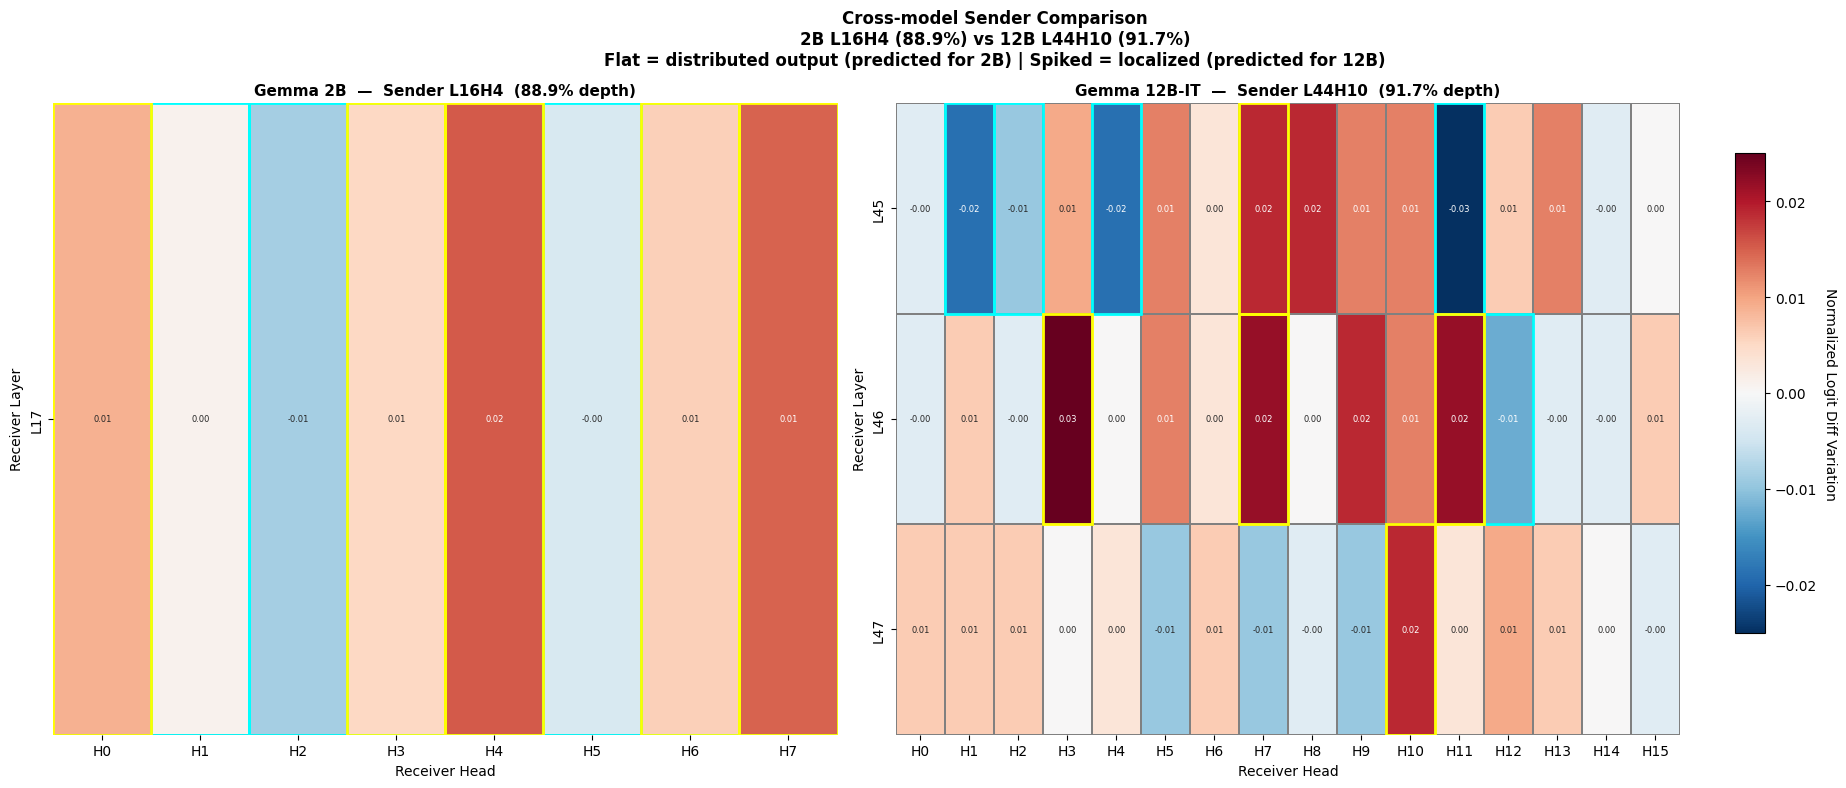

Saved sender_compare_2bL16H4_12bL44H10.png


In [17]:
# Cross-model sender comparison: match 2B and 12B senders by relative depth (within 15%)
n2b, n12b = 18, 48
pairs = []
for (sl2, sh2) in sorted(sender_2b.keys()):
    depth2 = sl2 / n2b
    if not sender_12b:
        continue
    best = min(sender_12b.keys(), key=lambda k: abs(k[0] / n12b - depth2))
    if abs(best[0] / n12b - depth2) < 0.15:
        pairs.append(((sl2, sh2), best))

if not pairs:
    print("No cross-model sender pairs within 15% relative depth.")
    print(f"  2B senders at depths: {[(k, f'{k[0]/n2b:.1%}') for k in sorted(sender_2b)]}")
    print(f"  12B senders at depths: {[(k, f'{k[0]/n12b:.1%}') for k in sorted(sender_12b)]}")
else:
    from matplotlib.patches import Patch
    for (sl2, sh2), (sl12, sh12) in pairs:
        t2 = sender_2b[(sl2, sh2)]
        t12 = sender_12b[(sl12, sh12)]
        vmax = max(float(np.abs(t2).max()), float(np.abs(t12).max()), 1e-6)

        shared_norm = plt.Normalize(vmin=-vmax, vmax=vmax)
        shared_cmap = plt.cm.RdBu_r

        h1 = max(6, t2.shape[0] * 0.35)
        h2 = max(6, t12.shape[0] * 0.35)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, max(h1, h2) + 2))
        fig.subplots_adjust(right=0.85, wspace=0.4)
        cbar_ax = fig.add_axes([0.87, 0.2, 0.015, 0.6])

        for ax, tensor, model_name, sl, sh, n_total in [
            (ax1, t2, "Gemma 2B", sl2, sh2, n2b),
            (ax2, t12, "Gemma 12B-IT", sl12, sh12, n12b),
        ]:
            actual_layers = list(range(sl + 1, sl + 1 + tensor.shape[0]))
            sns.heatmap(
                tensor, ax=ax,
                norm=shared_norm, cmap=shared_cmap,
                annot=(tensor.shape[1] <= 16 and tensor.shape[0] <= 50),
                fmt=".2f", annot_kws={"size": 6},
                xticklabels=[f"H{i}" for i in range(tensor.shape[1])],
                yticklabels=[f"L{l}" for l in actual_layers],
                linewidths=0.2, linecolor="gray",
                cbar=False
            )
            flat = tensor.flatten()
            for idx in np.argsort(flat)[:5]:
                r, c = divmod(int(idx), tensor.shape[1])
                ax.add_patch(plt.Rectangle((c, r), 1, 1,
                             fill=False, edgecolor="cyan", lw=2))
            for idx in np.argsort(flat)[-5:]:
                r, c = divmod(int(idx), tensor.shape[1])
                ax.add_patch(plt.Rectangle((c, r), 1, 1,
                             fill=False, edgecolor="yellow", lw=2))
            ax.set_title(f"{model_name}  —  Sender L{sl}H{sh}  ({sl/n_total:.1%} depth)",
                        fontsize=11, fontweight="bold")
            ax.set_xlabel("Receiver Head", fontsize=10)
            ax.set_ylabel("Receiver Layer", fontsize=10)

        fig.colorbar(
            plt.cm.ScalarMappable(norm=shared_norm, cmap=shared_cmap),
            cax=cbar_ax,
            label="Normalized Logit Diff Variation"
        )
        cbar_ax.yaxis.label.set_rotation(270)
        cbar_ax.yaxis.label.set_va("bottom")

        plt.suptitle(
            f"Cross-model Sender Comparison\n"
            f"2B L{sl2}H{sh2} ({sl2/n2b:.1%}) vs 12B L{sl12}H{sh12} ({sl12/n12b:.1%})\n"
            f"Flat = distributed output (predicted for 2B) | Spiked = localized (predicted for 12B)",
            fontsize=12, fontweight="bold"
        )
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        fname = f"sender_compare_2bL{sl2}H{sh2}_12bL{sl12}H{sh12}.png"
        plt.savefig(VISUALS_DIR / fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved {fname}")

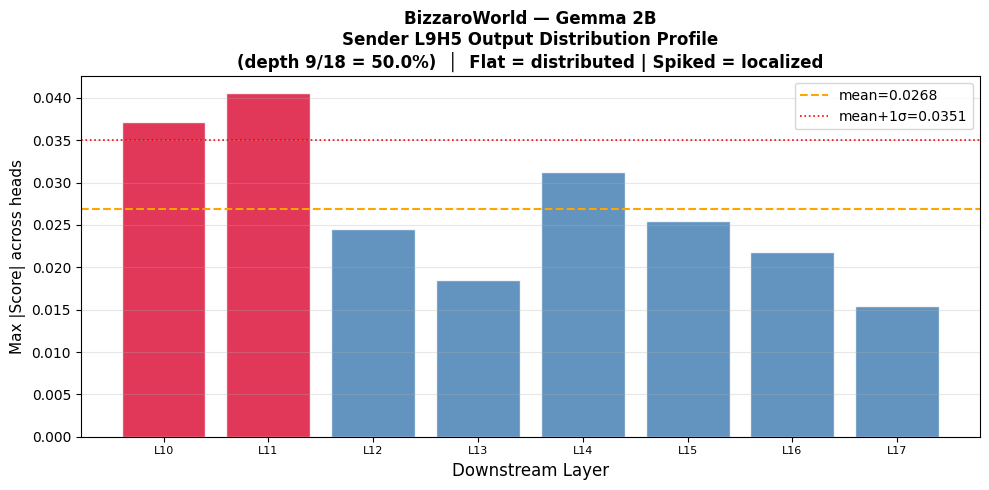

Saved sender_profile_gemma_2b_L9H5.png


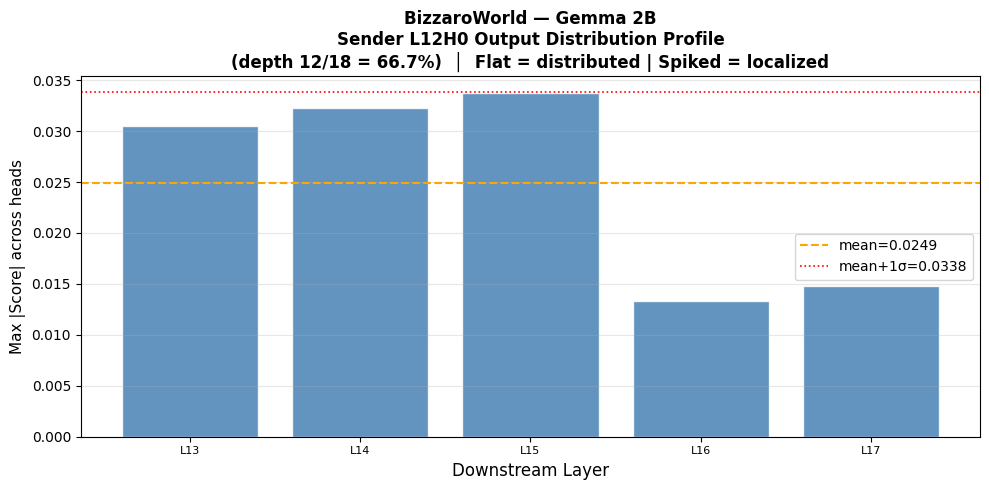

Saved sender_profile_gemma_2b_L12H0.png


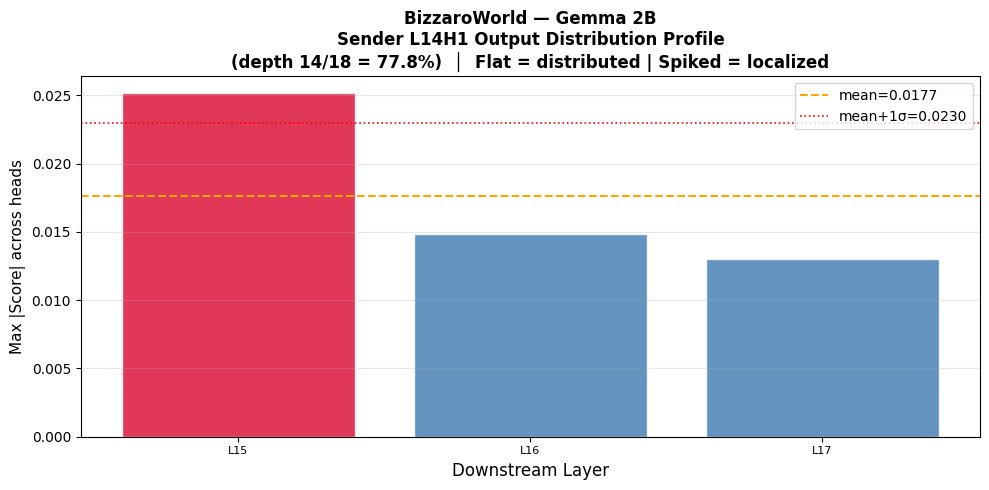

Saved sender_profile_gemma_2b_L14H1.png


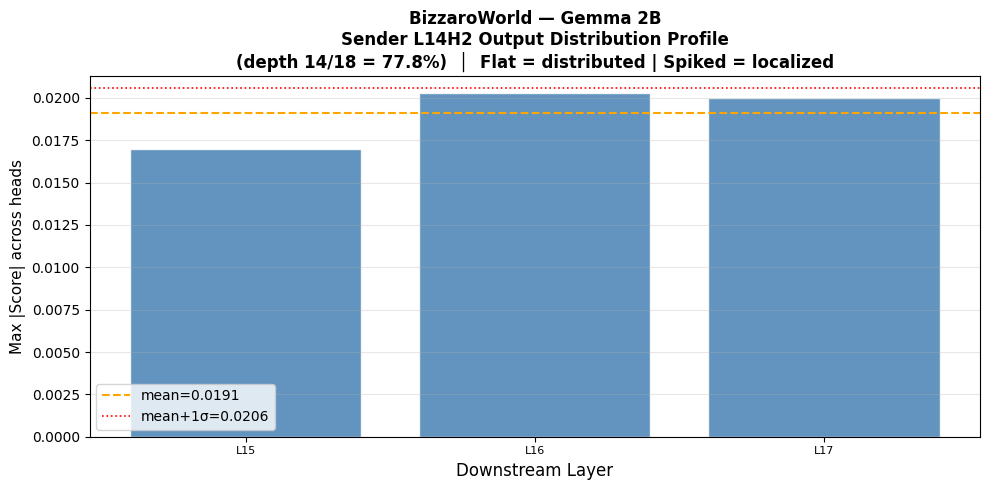

Saved sender_profile_gemma_2b_L14H2.png


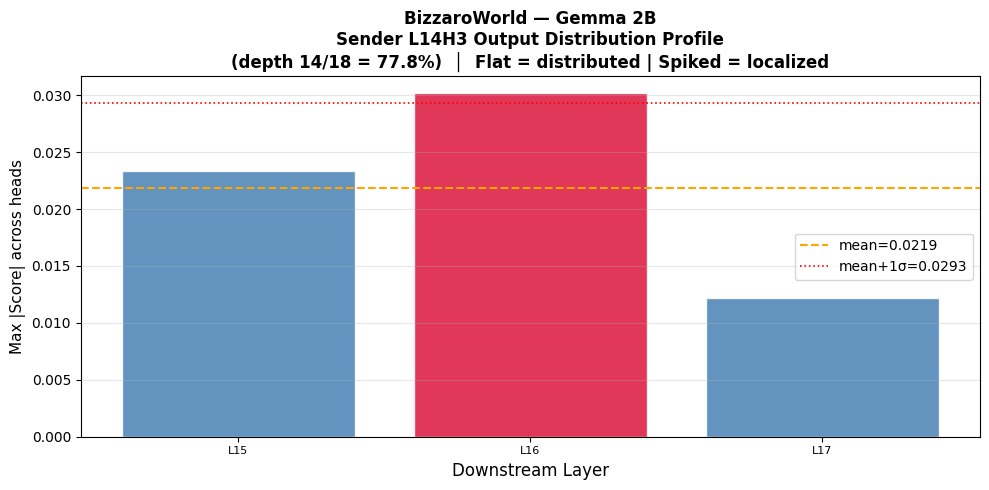

Saved sender_profile_gemma_2b_L14H3.png


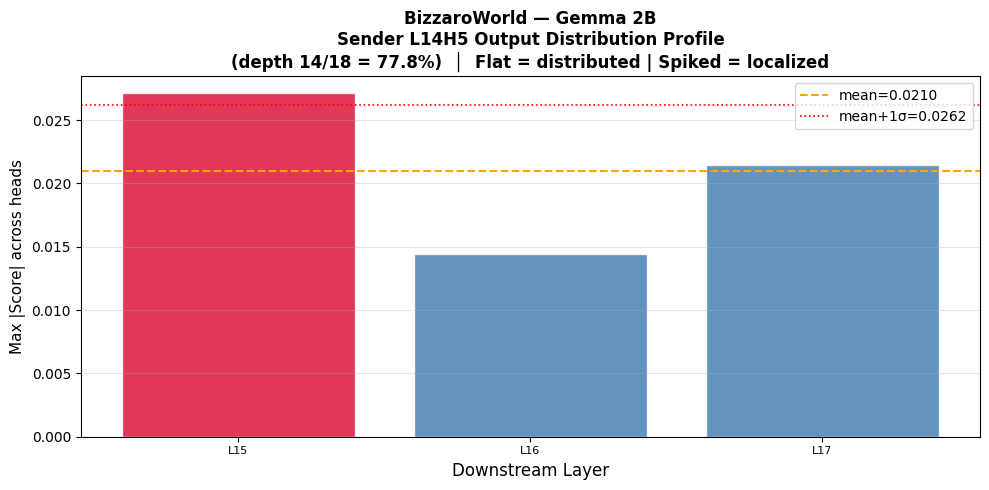

Saved sender_profile_gemma_2b_L14H5.png


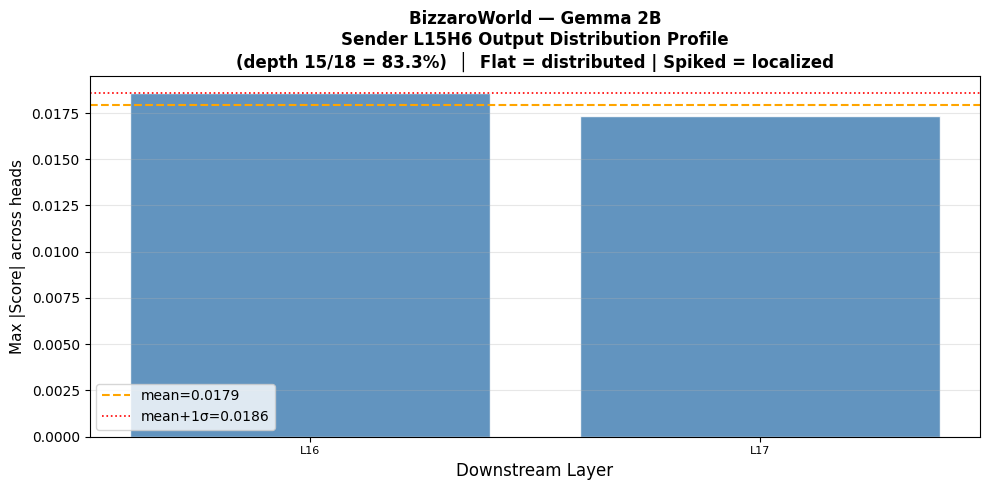

Saved sender_profile_gemma_2b_L15H6.png


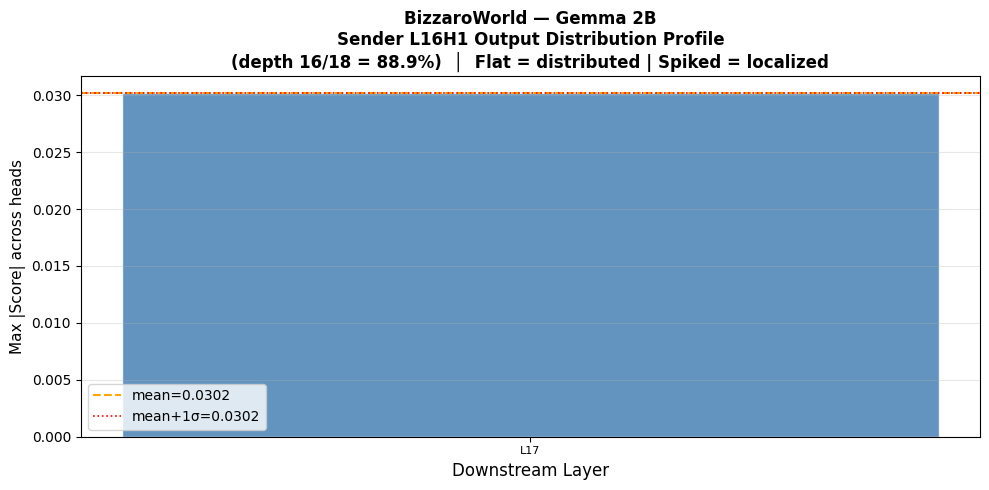

Saved sender_profile_gemma_2b_L16H1.png


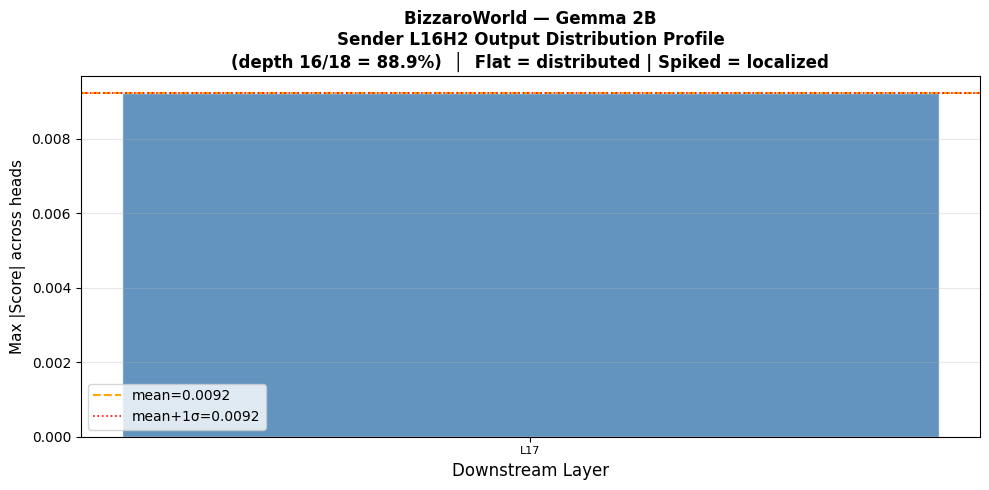

Saved sender_profile_gemma_2b_L16H2.png


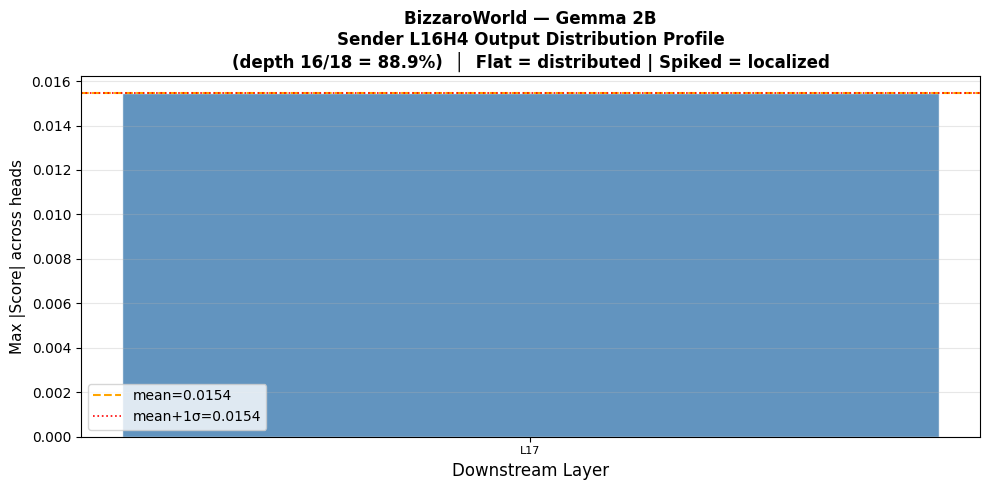

Saved sender_profile_gemma_2b_L16H4.png


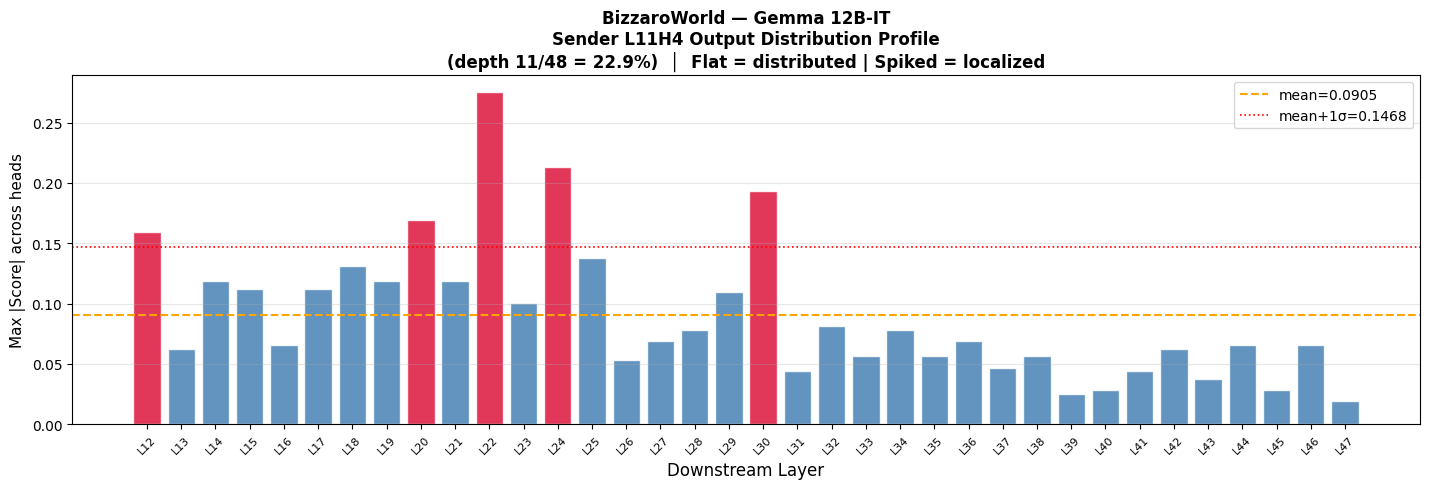

Saved sender_profile_gemma_12b_it_L11H4.png


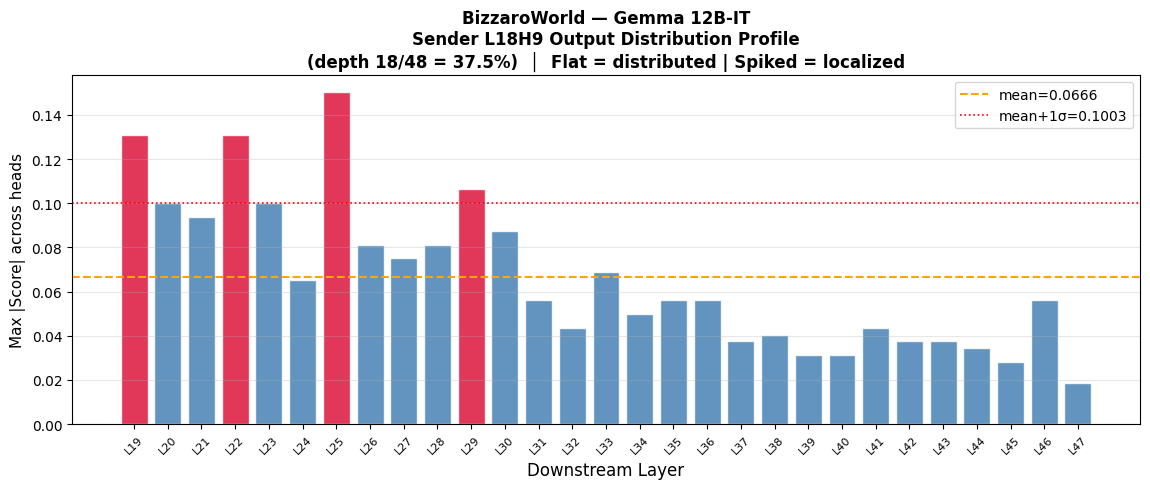

Saved sender_profile_gemma_12b_it_L18H9.png


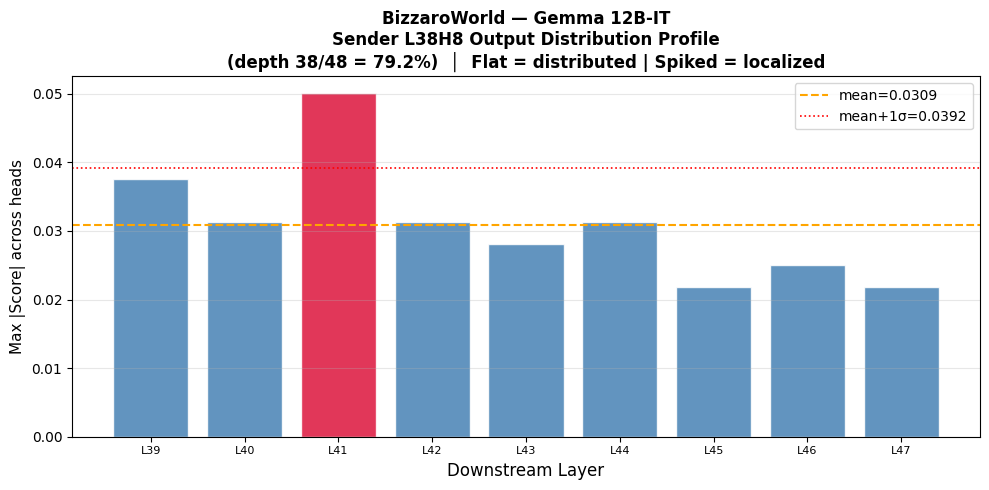

Saved sender_profile_gemma_12b_it_L38H8.png


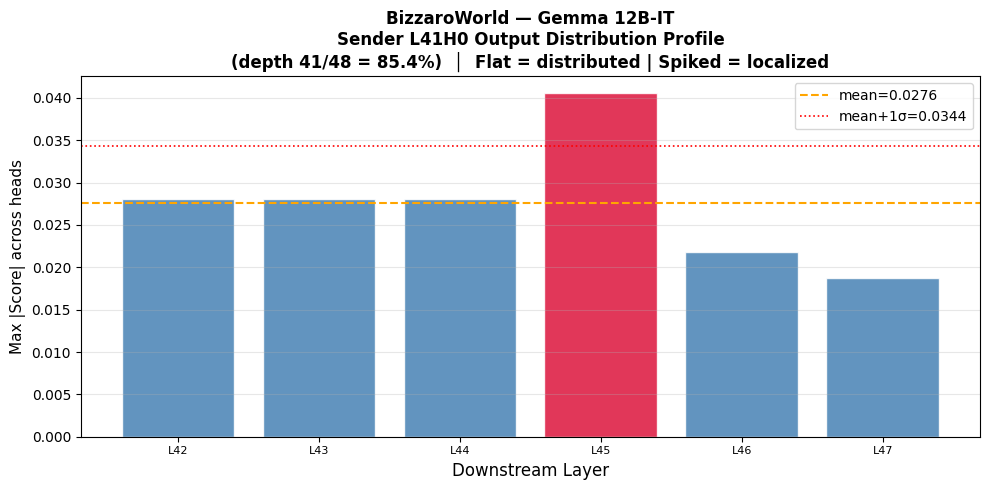

Saved sender_profile_gemma_12b_it_L41H0.png


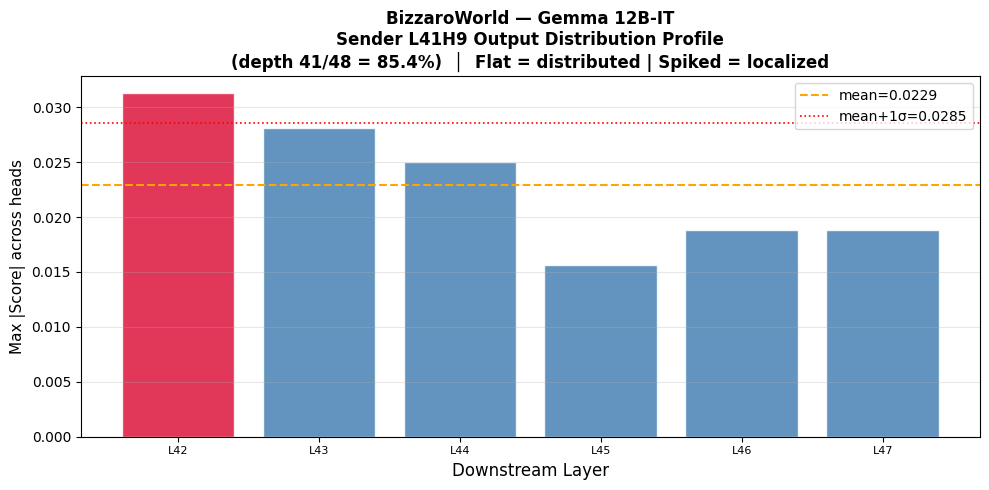

Saved sender_profile_gemma_12b_it_L41H9.png


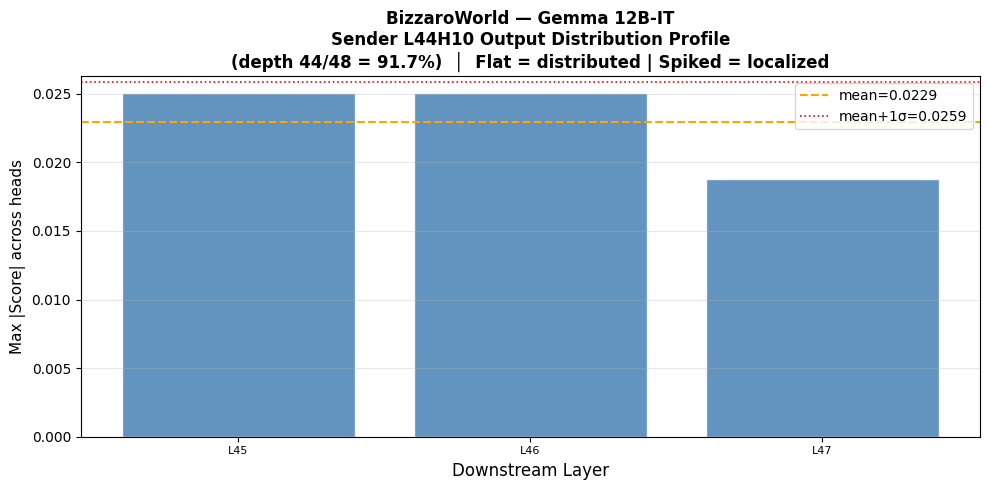

Saved sender_profile_gemma_12b_it_L44H10.png


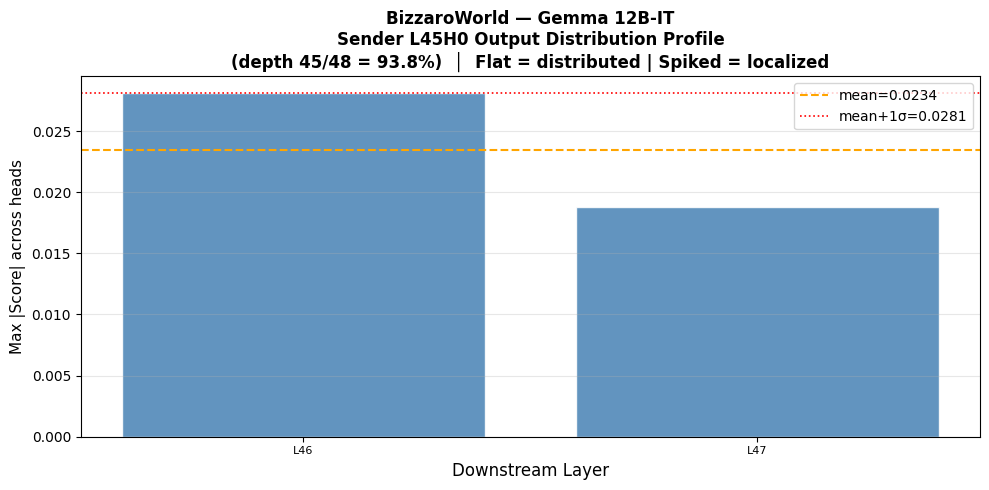

Saved sender_profile_gemma_12b_it_L45H0.png


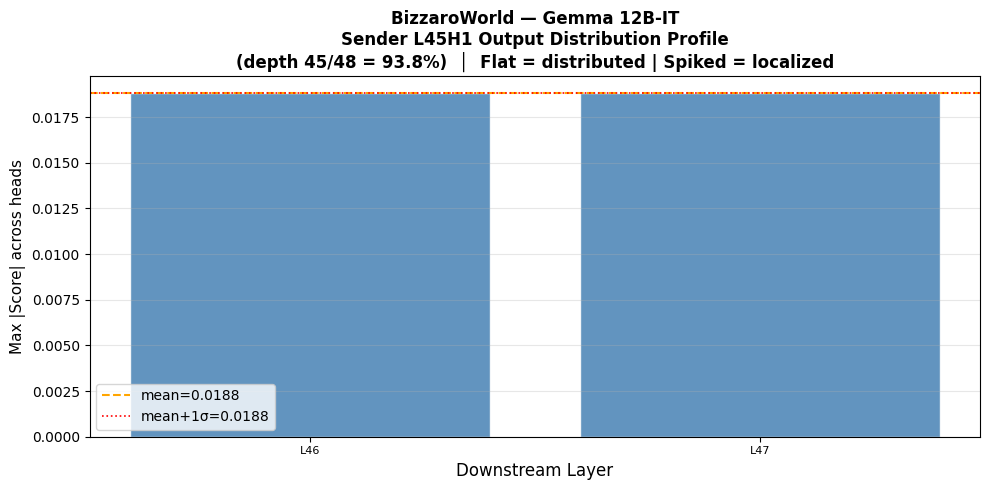

Saved sender_profile_gemma_12b_it_L45H1.png


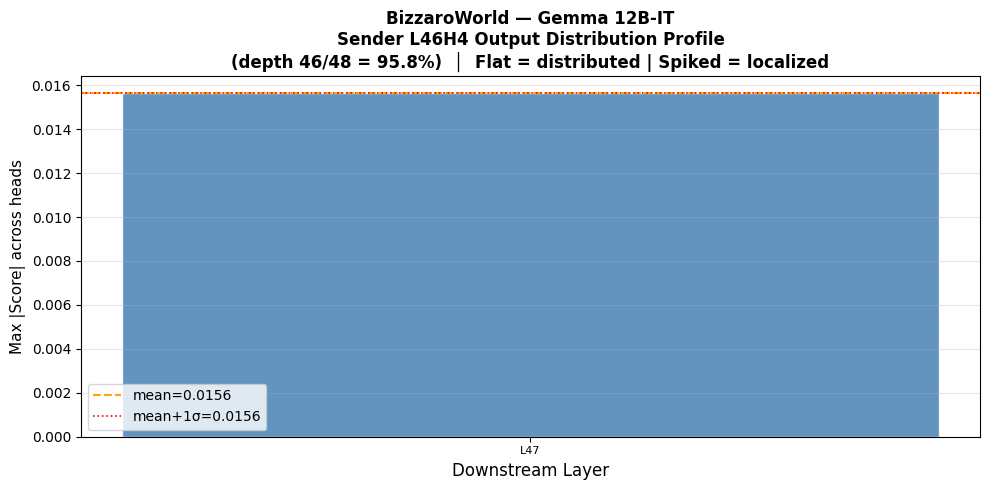

Saved sender_profile_gemma_12b_it_L46H4.png


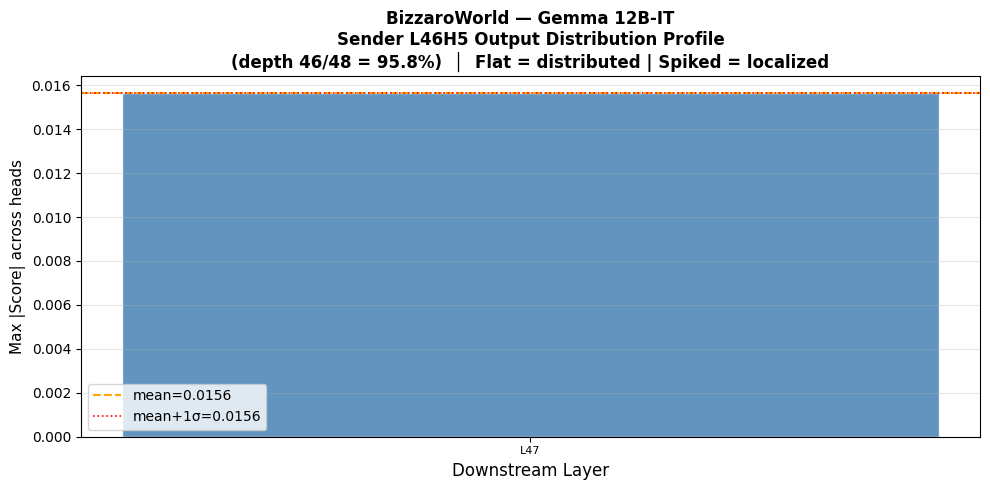

Saved sender_profile_gemma_12b_it_L46H5.png


In [18]:
def plot_sender_profile(tensor, sender_layer, sender_head_idx, model_name, n_layers_total):
    n_downstream = tensor.shape[0]
    actual_layers = list(range(sender_layer + 1, sender_layer + 1 + n_downstream))
    layer_max_abs = np.abs(tensor).max(axis=1)
    mean_val = float(layer_max_abs.mean())
    std_val = float(layer_max_abs.std())

    safe_name = model_name.lower().replace(" ", "_").replace("-", "_")
    filename = f"sender_profile_{safe_name}_L{sender_layer}H{sender_head_idx}.png"

    fig, ax = plt.subplots(figsize=(max(10, n_downstream * 0.4), 5))
    colors = ["crimson" if v > mean_val + std_val else "steelblue"
              for v in layer_max_abs]
    ax.bar(actual_layers, layer_max_abs, color=colors, edgecolor="white",
           alpha=0.85, width=0.8)
    ax.axhline(mean_val, color="orange", linestyle="--", lw=1.5,
               label=f"mean={mean_val:.4f}")
    ax.axhline(mean_val + std_val, color="red", linestyle=":", lw=1.2,
               label=f"mean+1σ={mean_val + std_val:.4f}")
    ax.set_xlabel("Downstream Layer", fontsize=12)
    ax.set_ylabel("Max |Score| across heads", fontsize=11)
    ax.set_title(
        f"BizzaroWorld — {model_name}\n"
        f"Sender L{sender_layer}H{sender_head_idx} Output Distribution Profile\n"
        f"(depth {sender_layer}/{n_layers_total} = {sender_layer/n_layers_total:.1%})"
        f"  │  Flat = distributed | Spiked = localized",
        fontsize=12, fontweight="bold"
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis="y")
    step = max(1, n_downstream // 30)
    ax.set_xticks(actual_layers[::step])
    ax.set_xticklabels([f"L{l}" for l in actual_layers[::step]],
                       fontsize=8, rotation=45 if n_downstream > 20 else 0)
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")

if sender_2b:
    for (sl, sh), tensor in sorted(sender_2b.items()):
        plot_sender_profile(tensor, sl, sh, "Gemma 2B", 18)
else:
    print("No 2B sender data yet — run Colab commands from Cell K first.")

if sender_12b:
    for (sl, sh), tensor in sorted(sender_12b.items()):
        plot_sender_profile(tensor, sl, sh, "Gemma 12B-IT", 48)
else:
    print("No 12B sender data yet — run Colab commands from Cell K first.")

In [19]:
print("=" * 70)
print("SENDER EXPERIMENT CLI COMMANDS (run on Colab with A100)")
print("=" * 70)
print()

all_2b_senders = " ".join([f"{l}:{h}" for l, h, s in load_bearing_2b + suppressive_2b])
all_12b_senders = " ".join([f"{l}:{h}" for l, h, s in load_bearing_12b + suppressive_12b])

print("Gemma 2B (load-bearing then suppressive):")
print(f"  python run_experiments.py --model gemma_2b \\")
print(f"    --sender-heads {all_2b_senders} \\")
print(f"    --skip-resid --export-json")
print()
print("Gemma 12B-IT:")
print(f"  python run_experiments.py --model gemma_12b \\")
print(f"    --sender-heads {all_12b_senders} \\")
print(f"    --skip-resid --export-json")
print()
print("=" * 70)
print("CONSTRUCTION-SPARSITY WARNING — 12B near-terminal senders:")
for l, h, s in load_bearing_12b + suppressive_12b:
    n_downstream = 48 - l - 1
    if n_downstream <= 3:
        print(f"  L{l}H{h}: only {n_downstream} downstream layer(s) — near-zero tensor")
        print(f"           is EXPECTED by construction, NOT evidence of inactivity.")
print("=" * 70)
print()
print("After running on Colab, copy path_patch_sender_*.pt and .json files")
print("back to results/gemma_2b/ and results/gemma_12b/, then re-run cells G-J.")

SENDER EXPERIMENT CLI COMMANDS (run on Colab with A100)

Gemma 2B (load-bearing then suppressive):
  python run_experiments.py --model gemma_2b \
    --sender-heads 16:2 14:5 16:4 15:6 14:1 14:2 16:1 9:5 12:0 14:3 \
    --skip-resid --export-json

Gemma 12B-IT:
  python run_experiments.py --model gemma_12b \
    --sender-heads 38:8 46:4 45:1 44:10 41:0 46:5 45:0 11:4 41:9 18:9 \
    --skip-resid --export-json

CONSTRUCTION-SPARSITY WARNING — 12B near-terminal senders:
  L46H4: only 1 downstream layer(s) — near-zero tensor
           is EXPECTED by construction, NOT evidence of inactivity.
  L45H1: only 2 downstream layer(s) — near-zero tensor
           is EXPECTED by construction, NOT evidence of inactivity.
  L44H10: only 3 downstream layer(s) — near-zero tensor
           is EXPECTED by construction, NOT evidence of inactivity.
  L46H5: only 1 downstream layer(s) — near-zero tensor
           is EXPECTED by construction, NOT evidence of inactivity.
  L45H0: only 2 downstream layer(s

In [20]:
# ── Cell 27B-A: Gemma 3 27B-IT setup — load all available results ─────────────
VISUALS_DIR_27B = Path("results/visuals/gemma_27b_it")
VISUALS_DIR_27B.mkdir(parents=True, exist_ok=True)

resid_27b = baseline_27b = None
n_layers_27b = n_heads_27b = 0
heads_q_27b = bm_27b = None
receiver_27b = []

try:
    with open("results/gemma_27b/path_patch_final_resid.json") as f:
        resid_27b = np.array(json.load(f)["values"])
    with open("results/gemma_27b/baseline_metrics.json") as f:
        baseline_27b = json.load(f)
    n_layers_27b, n_heads_27b = resid_27b.shape
    print(f"[OK]  resid: {resid_27b.shape}  clean_ld={baseline_27b['clean_ld']:.4f}  corrupt_ld={baseline_27b['corrupt_ld']:.4f}")
except FileNotFoundError:
    print("[--]  resid: not found — run Step 1 on Colab")

try:
    with open("results/gemma_27b/path_patch_heads_q.json") as f:
        _raw = json.load(f)
    _shape = _raw.get("shape", [0, 0])
    if _shape[0] == 0:
        raise ValueError(f"empty tensor (shape {_shape}) — receiver heads not run yet")
    heads_q_27b = np.array(_raw["values"]).reshape(_shape)
    with open("results/gemma_27b/baseline_metrics.json") as f:
        bm_27b = json.load(f)
    receiver_27b = bm_27b.get("receiver_heads_q", [])
    print(f"[OK]  heads_q: {heads_q_27b.shape}  receivers: {len(receiver_27b)}")
except FileNotFoundError:
    print("[--]  heads_q: not found — run Step 2 after viewing resid heatmap")
except ValueError as e:
    print(f"[--]  heads_q: {e}")

sender_27b = load_sender_results("results/gemma_27b")
if sender_27b:
    print(f"[OK]  senders: {sorted(sender_27b.keys())}")
else:
    print("[--]  senders: none yet — run Step 3 after viewing heads_q heatmap")

[OK]  resid: (62, 32)  clean_ld=0.7070  corrupt_ld=-0.5508
[--]  heads_q: empty tensor (shape [0, 32]) — receiver heads not run yet
[--]  senders: none yet — run Step 3 after viewing heads_q heatmap



Gemma 3 27B-IT

Top LOAD-BEARING heads (blue, negative — write correct answer):
 Layer   Head      Score
--------------------------
    54     23    -0.1768
    55     24    -0.1494
    53     11    -0.1240
    58     29    -0.0591
    61     21    -0.0498

Top SUPPRESSIVE heads (red, positive — suppress wrong answer):
 Layer   Head      Score
--------------------------
    54     22     0.0996
    58     28     0.0374
    61     10     0.0280
    58     31     0.0249
    47     23     0.0217


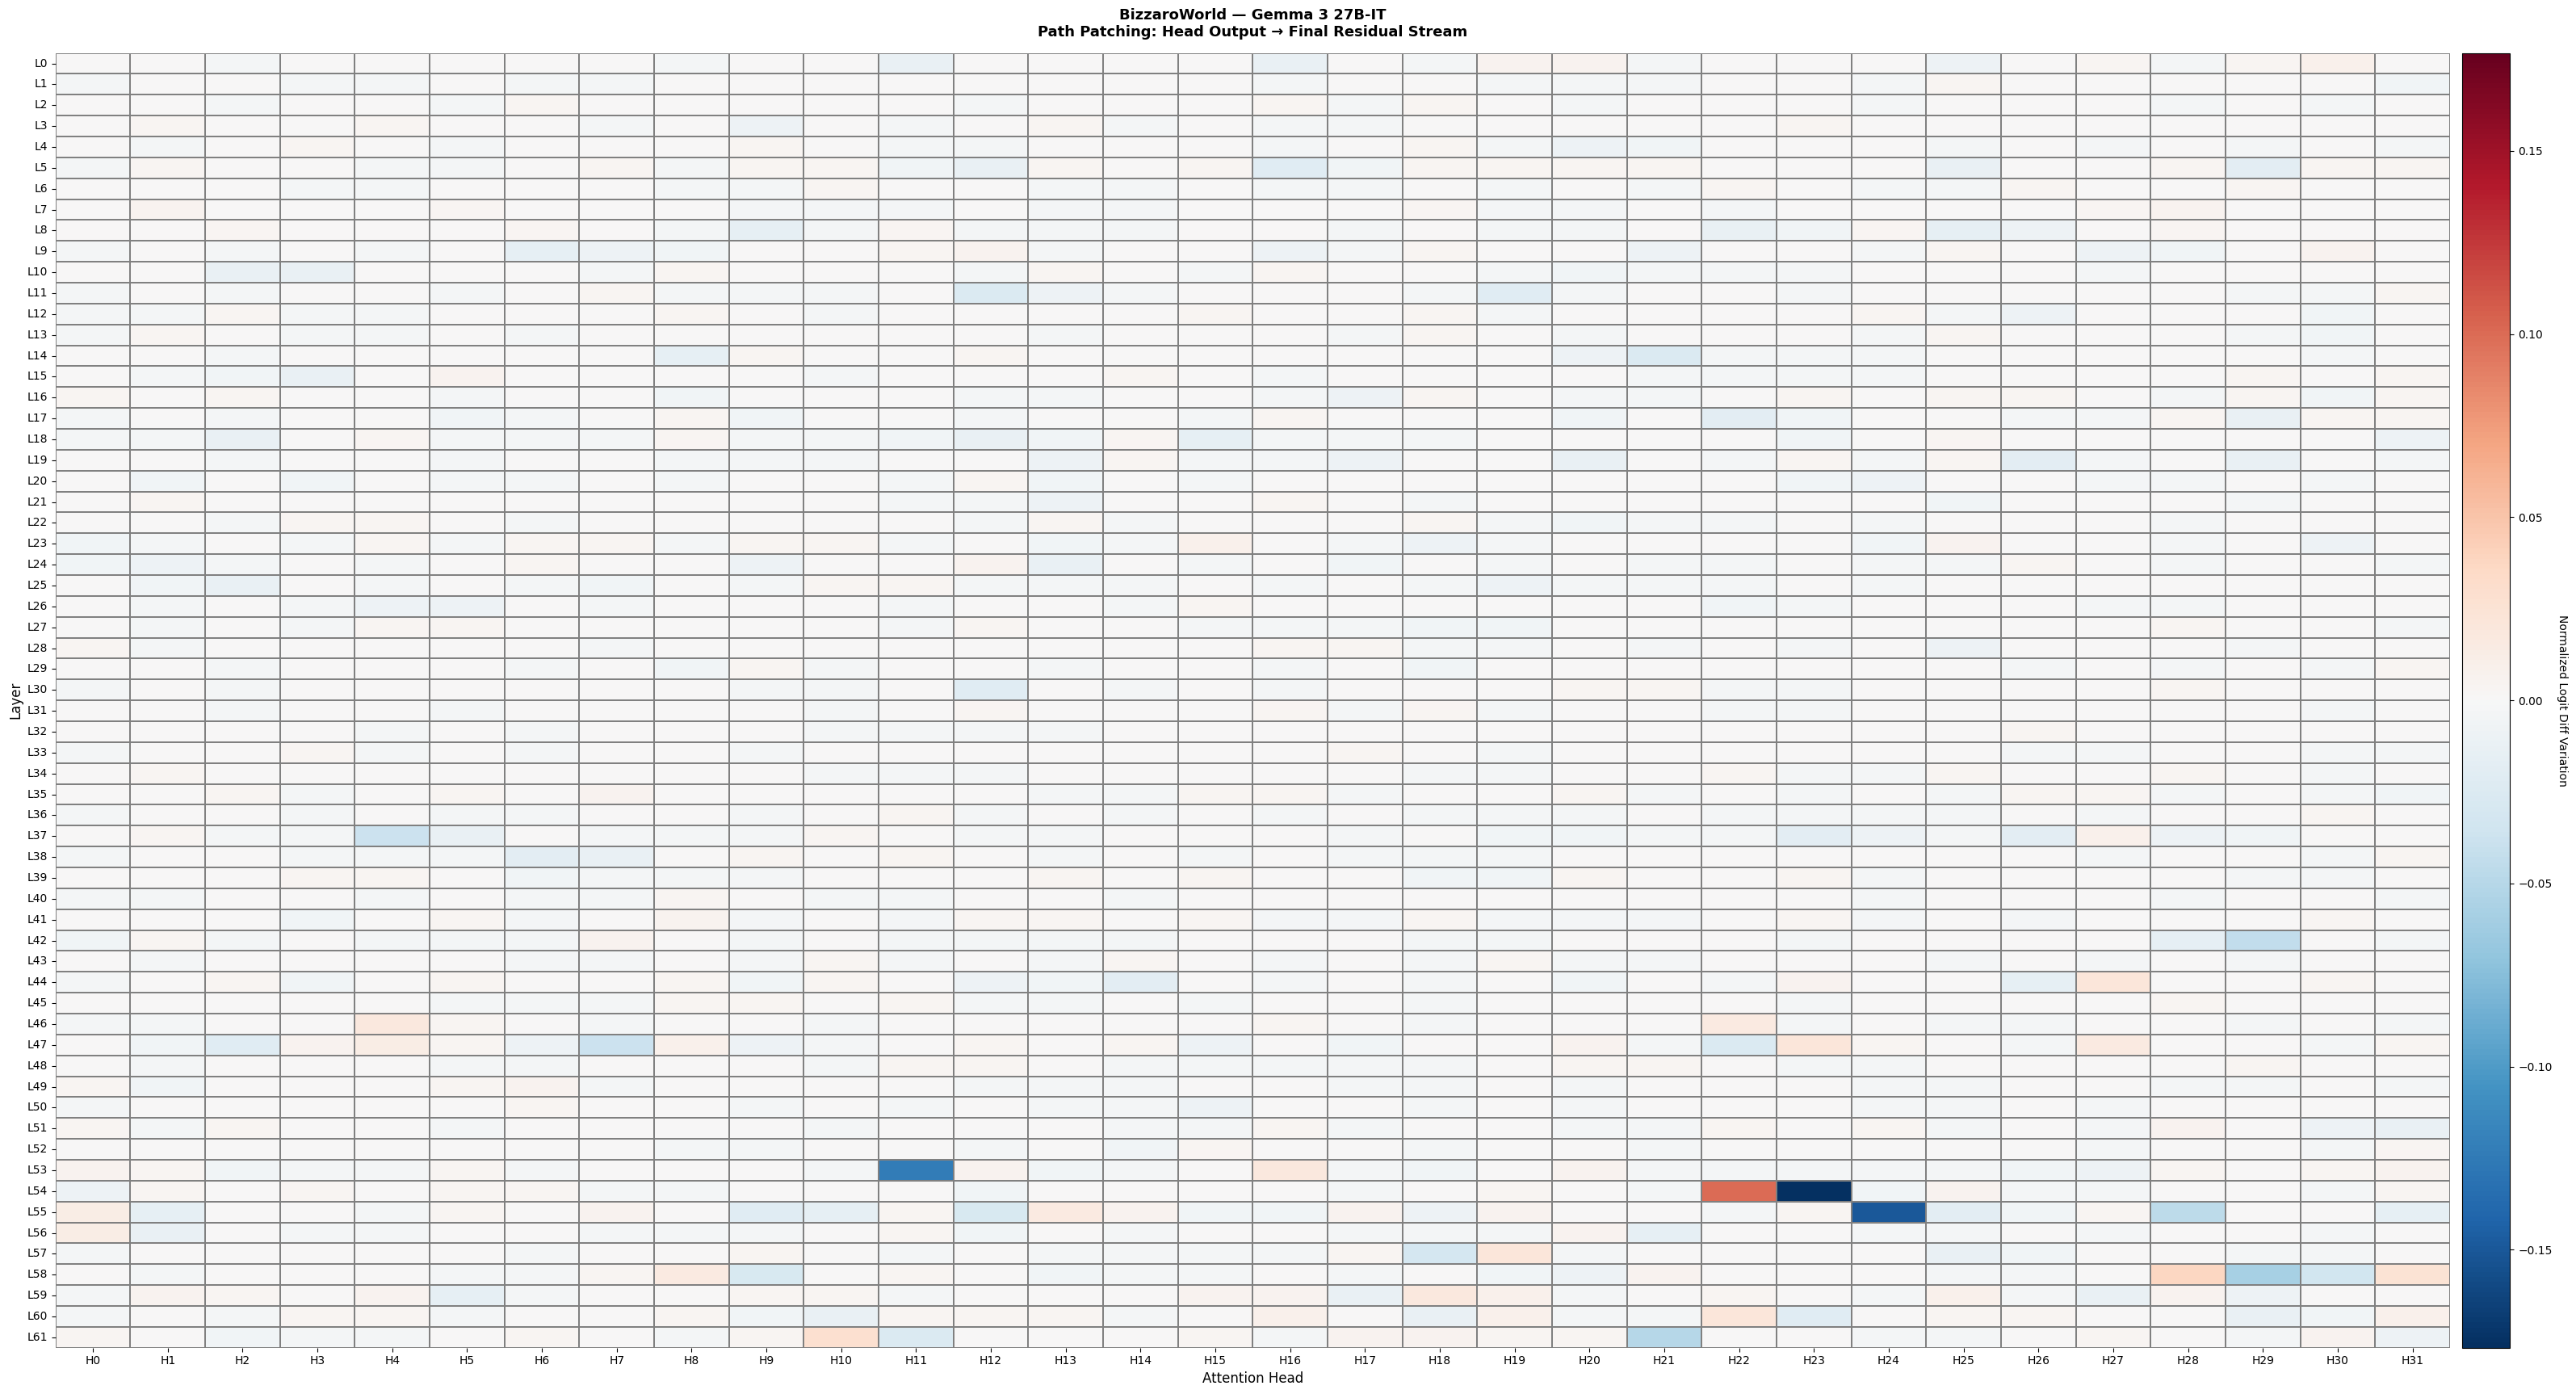

Saved heatmap_27b.png


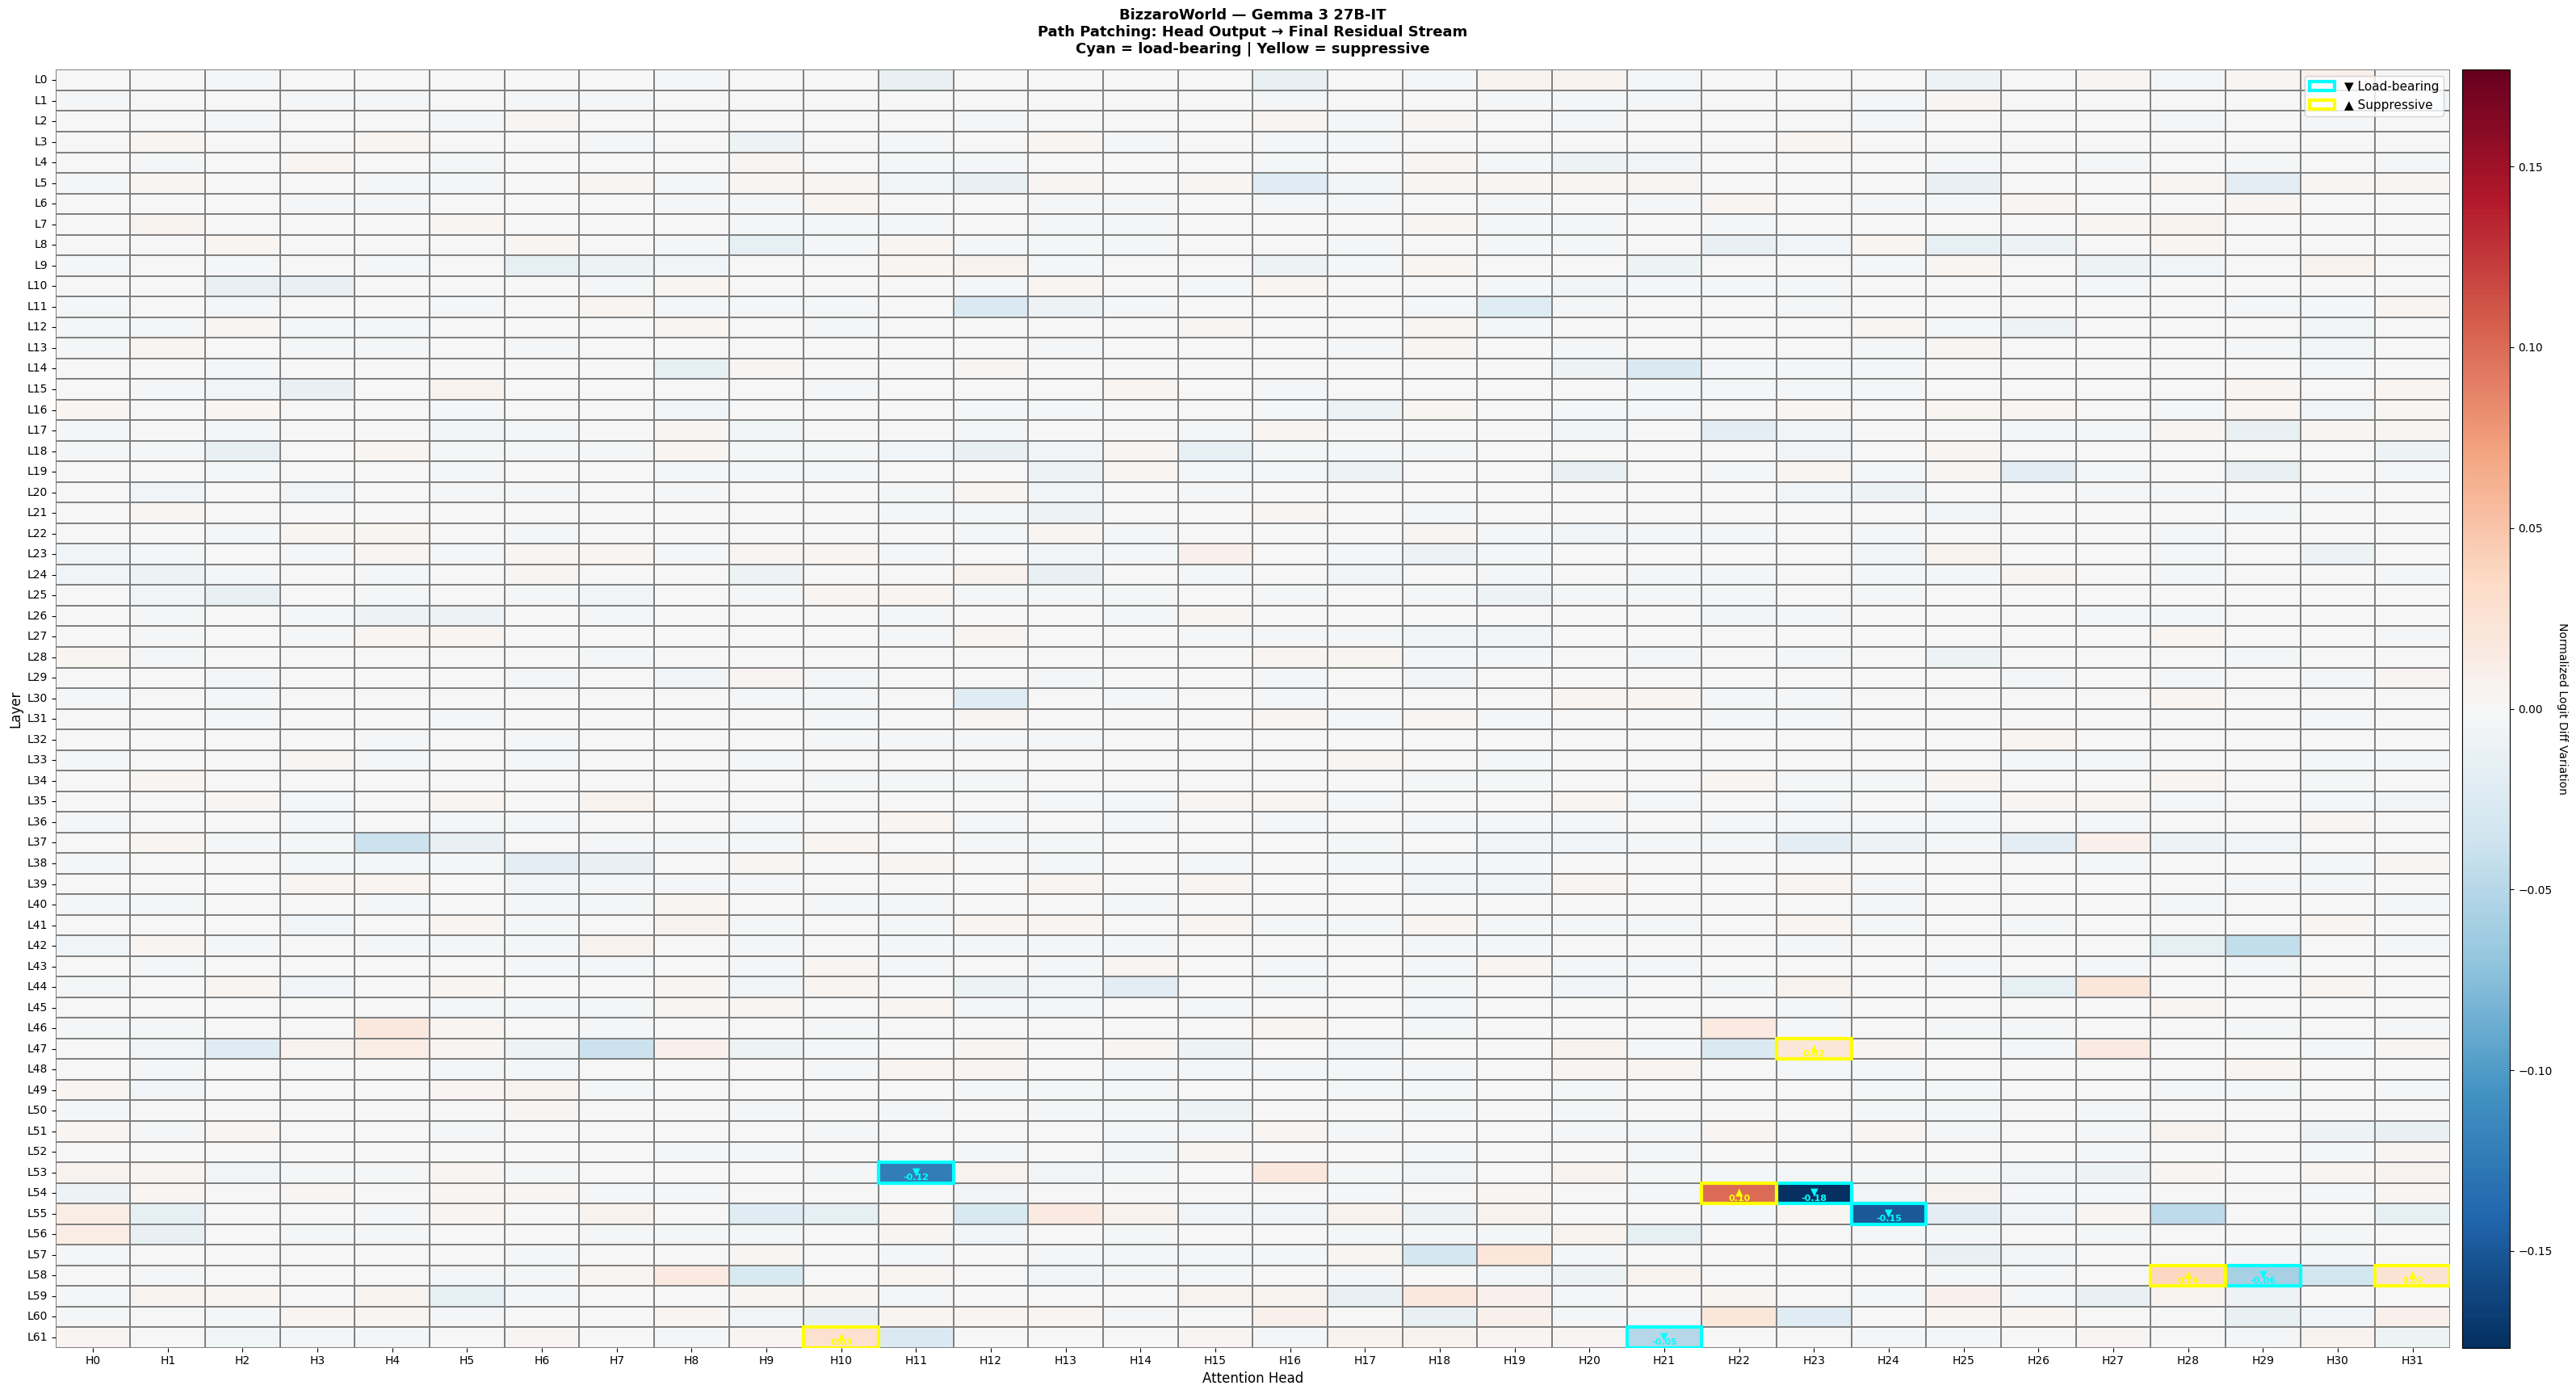

Saved heatmap_27b_annotated.png

STEP 2 — Receiver-head experiment (run on Colab):
  python run_experiments.py --model gemma_27b \
    --receiver-heads 54:23 55:24 53:11 58:29 61:21 54:22 58:28 61:10 58:31 47:23 \
    --receiver-input q --skip-resid --export-json

STEP 3 — Sender experiments (run on Colab):
  python run_experiments.py --model gemma_27b \
    --sender-heads 54:23 55:24 53:11 58:29 61:21 54:22 58:28 61:10 58:31 47:23 \
    --skip-resid --export-json

CONSTRUCTION-SPARSITY WARNING:
  L58H29: only 3 downstream layer(s) — near-zero sender tensor is expected.
  L61H21: only 0 downstream layer(s) — near-zero sender tensor is expected.
  L58H28: only 3 downstream layer(s) — near-zero sender tensor is expected.
  L61H10: only 0 downstream layer(s) — near-zero sender tensor is expected.
  L58H31: only 3 downstream layer(s) — near-zero sender tensor is expected.


In [21]:
# ── Cell 27B-B: resid heatmaps + next-step CLI commands ──────────────────────
load_bearing_27b, suppressive_27b = [], []

if resid_27b is None:
    print("No 27B resid data — run Step 1 on Colab and copy results/gemma_27b/ back locally.")
else:
    load_bearing_27b, suppressive_27b = get_top_heads(resid_27b, "Gemma 3 27B-IT", n=5)
    vmax = abs(resid_27b).max()

    for fname, annotate in [("heatmap_27b.png", False), ("heatmap_27b_annotated.png", True)]:
        fig, ax = plt.subplots(figsize=(max(14, n_heads_27b), max(16, n_layers_27b * 0.28)))
        sns.heatmap(resid_27b, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                    annot=False,
                    xticklabels=[f"H{i}" for i in range(n_heads_27b)],
                    yticklabels=[f"L{i}" for i in range(n_layers_27b)],
                    linewidths=0.1, linecolor="gray", cbar=False)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="2%", pad=0.15)
        plt.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(-vmax, vmax), cmap="RdBu_r"),
                     cax=cax, label="Normalized Logit Diff Variation")
        cax.yaxis.label.set_rotation(270); cax.yaxis.label.set_va("bottom")
        if annotate:
            for l, h, s in load_bearing_27b:
                ax.add_patch(plt.Rectangle((h, l), 1, 1, fill=False, edgecolor="cyan", lw=3))
                ax.text(h+0.5, l+0.2, "▼", ha="center", va="top",
                        fontsize=9, color="cyan", fontweight="bold")
                ax.text(h+0.5, l+0.75, f"{s:.2f}", ha="center", va="center",
                        fontsize=8, color="cyan", fontweight="bold")
            for l, h, s in suppressive_27b:
                ax.add_patch(plt.Rectangle((h, l), 1, 1, fill=False, edgecolor="yellow", lw=3))
                ax.text(h+0.5, l+0.2, "▲", ha="center", va="top",
                        fontsize=9, color="yellow", fontweight="bold")
                ax.text(h+0.5, l+0.75, f"{s:.2f}", ha="center", va="center",
                        fontsize=8, color="yellow", fontweight="bold")
            from matplotlib.patches import Patch
            ax.legend(handles=[
                Patch(facecolor="none", edgecolor="cyan", lw=3, label="▼ Load-bearing"),
                Patch(facecolor="none", edgecolor="yellow", lw=3, label="▲ Suppressive"),
            ], loc="upper right", fontsize=11, framealpha=0.8)
            title_suffix = "\nCyan = load-bearing | Yellow = suppressive"
        else:
            title_suffix = ""
        ax.set_title(f"BizzaroWorld — Gemma 3 27B-IT\nPath Patching: Head Output → Final Residual Stream{title_suffix}",
                    fontsize=13, fontweight="bold", pad=15)
        ax.set_xlabel("Attention Head", fontsize=12); ax.set_ylabel("Layer", fontsize=12)
        plt.tight_layout()
        plt.savefig(VISUALS_DIR_27B / fname, dpi=150, bbox_inches="tight")
        plt.show(); print(f"Saved {fname}")

    recv_combined_27b = list(dict.fromkeys([(l,h) for l,h,s in load_bearing_27b + suppressive_27b]))
    recv_str = " ".join([f"{l}:{h}" for l,h in recv_combined_27b])
    sender_str = " ".join([f"{l}:{h}" for l,h,s in load_bearing_27b + suppressive_27b])
    print("\n" + "="*70)
    print("STEP 2 — Receiver-head experiment (run on Colab):")
    print(f"  python run_experiments.py --model gemma_27b \\")
    print(f"    --receiver-heads {recv_str} \\")
    print(f"    --receiver-input q --skip-resid --export-json")
    print("\nSTEP 3 — Sender experiments (run on Colab):")
    print(f"  python run_experiments.py --model gemma_27b \\")
    print(f"    --sender-heads {sender_str} \\")
    print(f"    --skip-resid --export-json")
    near_terminal_27b = [(l,h,s) for l,h,s in load_bearing_27b + suppressive_27b
                         if n_layers_27b - l - 1 <= 3]
    if near_terminal_27b:
        print("\nCONSTRUCTION-SPARSITY WARNING:")
        for l, h, s in near_terminal_27b:
            nd = n_layers_27b - l - 1
            print(f"  L{l}H{h}: only {nd} downstream layer(s) — near-zero sender tensor is expected.")
    print("="*70)

In [22]:
# ── Cell 27B-C: heads_q heatmap + sender heatmaps/profiles ──────────────────
lb_senders_27b, sup_senders_27b = [], []

if heads_q_27b is not None:
    lb_senders_27b, sup_senders_27b = get_top_senders(heads_q_27b, "Gemma 3 27B-IT", n=8)
    n_hq, n_hq_heads = heads_q_27b.shape
    fig, ax = plt.subplots(figsize=(max(14, n_hq_heads), max(12, n_hq * 0.3)))
    vmax = abs(heads_q_27b).max()
    sns.heatmap(heads_q_27b, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                annot=(n_hq_heads <= 16 and n_hq <= 50), fmt=".2f", annot_kws={"size": 6},
                xticklabels=[f"H{i}" for i in range(n_hq_heads)],
                yticklabels=[f"L{i}" for i in range(n_hq)],
                linewidths=0.1, linecolor="gray", cbar=False)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.15)
    plt.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(-vmax, vmax), cmap="RdBu_r"),
                 cax=cax, label="Normalized Logit Diff Variation")
    cax.yaxis.label.set_rotation(270); cax.yaxis.label.set_va("bottom")
    for l, h, s in lb_senders_27b:
        ax.add_patch(plt.Rectangle((h, l), 1, 1, fill=False, edgecolor="cyan", lw=2.5))
    for l, h, s in sup_senders_27b:
        ax.add_patch(plt.Rectangle((h, l), 1, 1, fill=False, edgecolor="yellow", lw=2.5))
    for rl in sorted(set(l for l, h in receiver_27b)):
        if rl < n_hq:
            ax.axhline(y=rl, color="white", linestyle="--", linewidth=1.5, alpha=0.7)
            ax.axhline(y=rl + 1, color="white", linestyle="--", linewidth=1.5, alpha=0.7)
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Patch(facecolor="none", edgecolor="cyan", lw=2.5, label="▼ Load-bearing senders"),
        Patch(facecolor="none", edgecolor="yellow", lw=2.5, label="▲ Suppressive senders"),
        Line2D([0],[0], color="white", linestyle="--", lw=1.5, label="── Receiver layers"),
    ], loc="upper right", fontsize=10, framealpha=0.85, facecolor="#222222", labelcolor="white")
    ax.set_title(
        f"BizzaroWorld — Gemma 3 27B-IT\nHead-to-Head: Sender → Receiver Query Inputs\n"
        f"Receivers: {', '.join([f'L{l}H{h}' for l,h in receiver_27b[:10]])}{'...' if len(receiver_27b)>10 else ''}",
        fontsize=12, fontweight="bold", pad=15)
    ax.set_xlabel("Sender Head", fontsize=12); ax.set_ylabel("Sender Layer", fontsize=12)
    plt.tight_layout()
    plt.savefig(VISUALS_DIR_27B / "heads_q_heatmap_27b.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved heads_q_heatmap_27b.png")
else:
    print("No 27B heads_q — run Step 2 on Colab first.")

if sender_27b:
    _n27b = n_layers_27b if n_layers_27b > 0 else max(sl + 1 + t.shape[0] for (sl,_),t in sender_27b.items())
    _orig_dir = VISUALS_DIR
    VISUALS_DIR = VISUALS_DIR_27B
    for (sl, sh), tensor in sorted(sender_27b.items()):
        plot_sender_heatmap(tensor, sl, sh, "Gemma 3 27B-IT", _n27b)
        plot_sender_profile(tensor, sl, sh, "Gemma 3 27B-IT", _n27b)
    VISUALS_DIR = _orig_dir
else:
    print("No 27B sender data — run Step 3 on Colab first.")

No 27B heads_q — run Step 2 on Colab first.
No 27B sender data — run Step 3 on Colab first.


In [23]:
# ── Cell 27B-D: 27B circuit summary ──────────────────────────────────────────
_27b_circuit = {}

if resid_27b is not None:
    _27b_circuit["load_bearing_final_resid"] = [(l, h) for l, h, s in load_bearing_27b]
    _27b_circuit["suppressive_final_resid"]  = [(l, h) for l, h, s in suppressive_27b]
if "lb_senders_27b" in dir() and lb_senders_27b:
    _27b_circuit["load_bearing_senders"] = [(l, h) for l, h, s in lb_senders_27b]
    _27b_circuit["suppressive_senders"]  = [(l, h) for l, h, s in sup_senders_27b]

if _27b_circuit:
    summary_27b = {
        "model": "google/gemma-3-27b-it",
        "n_layers": int(n_layers_27b),
        "n_heads": int(n_heads_27b),
        "baseline": {
            "clean_ld":    baseline_27b["clean_ld"]    if baseline_27b else None,
            "corrupt_ld":  baseline_27b["corrupt_ld"]  if baseline_27b else None,
            "total_swing": baseline_27b["total_swing"] if baseline_27b else None,
        },
        "circuit_heads": _27b_circuit,
    }
    with open(VISUALS_DIR_27B / "circuit_summary_27b.json", "w") as f:
        json.dump(summary_27b, f, indent=2)
    print("Saved circuit_summary_27b.json")
    print(f"\nGemma 3 27B-IT circuit heads:")
    for k, v in _27b_circuit.items():
        print(f"  {k}: {v}")
else:
    print("No 27B circuit data available yet. Run at least Step 1 first.")

Saved circuit_summary_27b.json

Gemma 3 27B-IT circuit heads:
  load_bearing_final_resid: [(54, 23), (55, 24), (53, 11), (58, 29), (61, 21)]
  suppressive_final_resid: [(54, 22), (58, 28), (61, 10), (58, 31), (47, 23)]
